# 05 — Features: a leakage-safe modelling table

This notebook builds **one table** and models nothing. Its only job is to hand 06 a
feature matrix whose every column was knowable at the moment it claims to be knowable.

**It is organised by leakage risk, not by data source.** That is deliberate. Leakage is
the highest-risk failure left in this project and it is invisible until it inflates 06's
metrics — a leaky feature does not raise an error, it just makes the model look good. So
the structure is: fix the anchor, fix the windows, prove they are disjoint, write the
forbidden list down, then build each block and audit it against that list.

**The target is `repeat_purchase_30d`, and it is not churn.** Under the certified 42.2-day
rule no user can be churned before day 42.2, so a 30-day horizon cannot carry a churn
label (`known_limitations`: *D30 CANNOT MEASURE CHURN*). `repeat_purchase_60d` and
`repeat_purchase_90d` are built as secondaries. The word "churn" appears in this notebook
only when describing 03's rule.

**Anchor.** `t0` = each user's first order timestamp under the certified reconstruction
rule. Features come from events strictly before `t0`, plus the first order itself at `t0`.
The outcome is measured strictly after `t0`.

---

### Three things found while building this that changed the design

A feature table organised by data source would have shipped all three silently.

1. **10.7% of purchasers keep browsing inside the first-order session after they buy.**
   241,536 events sit in the first-order session *after* `t0`. A "first-session behaviour"
   feature keyed on `user_session = first_session` — the definition 02 used for its
   certified `first_session_events` — reads those events. They are outcome-window data.
2. **`cart_abandonment_rate` is degenerate in a strictly-pre-first-order window.** There
   are exactly **zero** purchase events before `t0`, by construction, so every carted
   product is an abandoned one and the rate is 1.0 for every user who has one. 04 computed
   it over full history, which includes post-`t0` purchases. It cannot be carried forward
   as built, and neither can the segment model that was fitted on it.
3. **Purchase cadence does not exist at `t0`.** Every user has exactly one order at the
   anchor, so 04 §9B's personalised-threshold recommendation is not testable in its stated
   form — not for 77% of users, for **100%** of them. §7 tests the nearest thing that is
   defined and reports what it is worth, which is little.

In [1]:
import os, sys, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.special import ndtr
from sklearn.metrics import roc_auc_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
warnings.filterwarnings("ignore", category=RuntimeWarning)

from src.plotting import frame, add_title, add_takeaway, save, show_df, thousands
from src.data import connect, materialize, create_orders_view, round_sig

SEED = 42
np.random.seed(SEED)
TABLES_DIR    = os.path.join("outputs", "tables")
FIG_DIR       = os.path.join("outputs", "figures")
PROCESSED_DIR = os.path.join("data", "processed")
for d in (TABLES_DIR, FIG_DIR, PROCESSED_DIR):
    os.makedirs(d, exist_ok=True)

with open(os.path.join("outputs", "handoff_params.json")) as f:
    handoff = json.load(f)

BOT        = handoff["bot_exclusion"]
BULK       = handoff["bulk_buyer_segment"]
CHURN      = handoff["churn_definition"]
LEAK       = handoff["leakage_rules_for_05"]
SEG        = handoff["segmentation"]
K_CERT     = float(CHURN["certified_threshold_days"])
DATA_START = pd.Timestamp(handoff["data_date_range"]["min"])
DATA_END_H = pd.Timestamp(handoff["data_date_range"]["max"])
HORIZONS   = [30, 60, 90]
PRIMARY_H  = int(handoff["retention_horizon"]["primary_days"])
BULK_ITEMS = float(BULK["threshold_items_per_order"])

print("INHERITED FROM handoff_params.json -- NOT RE-DERIVED")
print("=" * 94)
print(f"  order rule          : {handoff['order_reconstruction_rule']['rule']}")
print(f"  bot exclusion       : {BOT['metric']} > {BOT['threshold']}  ->  {BOT['n_users_excluded']:,} users")
print(f"  primary horizon     : D{PRIMARY_H}  ({handoff['retention_horizon']['ml_target_recommendation']})")
print(f"  churn threshold     : {K_CERT}d -- used here ONLY as a reference scale in Section 7, never as a label")
print(f"  bulk buyers         : {BULK['n_users']} users, order-size bar {BULK_ITEMS:.3f} items")
print(f"  data window         : {DATA_START}  ..  {DATA_END_H}")
print()
print("THE SIX CONSTRAINTS THIS NOTEBOOK IS BOUND BY -- stated before any code that could violate one")
print("=" * 94)
print("  1  LEAKAGE RULE (02 Section 0E). No feature from a cart-abandonment TYPE whose definition")
print("     references the outcome window. Abandonment VOLUME is permitted.")
print(f"     evidence: {LEAK['evidence'][:92]}...")
print("  2  ANCHOR SENSITIVITY (03). log1p(n_removals) is OR 1.37-1.44 first-order-anchored and")
print("     1.03-1.14 calendar-anchored. Carry calendar position alongside it and do not expect 1.38")
print("     to survive a re-anchoring. Re-measured against this table in Section 6.")
print("  3  DETERMINISM (04). BOTH guards or 04 does not reproduce: round_sig(sig=6) on every feature")
print("     frame after fetch AND .sort_values('user_id'). Two full runs compared in Section 11.")
print("  4  SEGMENT LABELS ARE NOT DURABLE (04). same-cluster 56.9%, kappa 0.309. cluster_name is NOT")
print("     joined as a static feature. Section 8 re-scores from segment_model.json on pre-t0 data only,")
print("     reports what fraction can be scored, and explains why the answer is still 'do not use it'.")
print("  5  CLUSTER FEATURES ARE NOT TENURE-NORMALISED (04 Section 9C). Tenure is carried explicitly and")
print("     every behavioural count gets a per-tenure-day twin. Section 6.")
print("  6  BULK BUYERS (02 Section 0C). Kept and flagged; excluded from MEAN-based monetary features.")

assert handoff["retention_horizon"]["ml_target_recommendation"] == "repeat_purchase_30d"
assert LEAK["what_survives"].startswith("Abandonment VOLUME")
assert SEG["stability"]["membership_holds"] is False and SEG["stability"]["same_cluster_pct"] == 56.9
assert abs(float(SEG["stability"]["cohens_kappa"]) - 0.309) < 1e-9
assert SEG["clustering"]["determinism_guard"]["binding_on_05"].startswith("Any notebook that re-derives")
assert "D30 CANNOT MEASURE CHURN" in " ".join(handoff["known_limitations"])
print()
print("All six inherited constraints asserted against handoff_params.json before any feature is built.")

con = connect()
print("DuckDB ready (threads=6; determinism guardrails in src/data.py connect()).")

INHERITED FROM handoff_params.json -- NOT RE-DERIVED
  order rule          : GROUP BY (user_id, user_session, event_time) on event_type='purchase' rows
  bot exclusion       : sessions per active day (distinct user_session count / distinct active-day count) > 29.0  ->  1,605 users
  primary horizon     : D30  (repeat_purchase_30d)
  churn threshold     : 42.2d -- used here ONLY as a reference scale in Section 7, never as a label
  bulk buyers         : 143 users, order-size bar 90.602 items
  data window         : 2019-10-01 00:00:00  ..  2020-02-29 23:59:59

THE SIX CONSTRAINTS THIS NOTEBOOK IS BOUND BY -- stated before any code that could violate one
  1  LEAKAGE RULE (02 Section 0E). No feature from a cart-abandonment TYPE whose definition
     references the outcome window. Abandonment VOLUME is permitted.
     evidence: Under the leaky spec deferred_intent scored OR=10.81 [10.29, 11.36]; with the classification...
  2  ANCHOR SENSITIVITY (03). log1p(n_removals) is OR 1.37-1.44 fir

## 1. The anchor, and the windows

Everything here is defined relative to one instant per user.

| | definition | who may read it |
|---|---|---|
| **`t0`** | the user's **first order timestamp** — certified rule `GROUP BY (user_id, user_session, event_time)` on purchase rows, first by `(order_ts, user_session)` | — |
| **FEATURE window** | every event with `event_time < t0`, **plus** the purchase lines of the first order at exactly `t0` | M1 / M2 / M3 / M4 |
| **OUTCOME window** | every order with `order_ts > t0` in a session other than the first-order session | the target, and nothing else |

Two boundary decisions, both made explicitly rather than by default:

- **Events at exactly `t0` that are not the first order's own purchase lines are excluded
  from everything.** They are simultaneous with the anchor and cannot be ordered against
  it. There are 75 of them across 31 users — counted below, not waved away.
- **The outcome requires a different session**, matching 02's purchase-retention
  definition exactly, so this notebook's target and 02's retention curve are the same
  quantity and must reconcile to the decimal (Section 3).

In [2]:
t_start = time.time()
con.execute("CREATE OR REPLACE VIEW ev_raw AS SELECT * FROM read_csv_auto('data/raw/*.csv', filename=true)")
con.execute("CREATE OR REPLACE VIEW ev0 AS SELECT * FROM ev_raw WHERE user_session IS NOT NULL")
con.execute(f'''
CREATE OR REPLACE VIEW bot_users AS
WITH u AS (SELECT user_id, count(DISTINCT user_session) n_sessions,
           count(DISTINCT date_trunc('day', event_time)) n_active_days FROM ev0 GROUP BY user_id)
SELECT user_id FROM u WHERE n_sessions*1.0/n_active_days > {float(BOT['threshold'])}''')
n_bot = con.execute("SELECT count(*) FROM bot_users").fetchone()[0]
assert n_bot == BOT["n_users_excluded"], f"bot list drifted: {n_bot} vs {BOT['n_users_excluded']}"

materialize(con, "ev", '''SELECT user_id, user_session, event_time, event_type, product_id,
                                 category_id, brand, price
                          FROM ev0 WHERE user_id NOT IN (SELECT user_id FROM bot_users)''')
create_orders_view(con, events_view="ev", view_name="orders_v")
materialize(con, "orders", "SELECT * FROM orders_v")
materialize(con, "first_order", '''
    SELECT user_id, user_session AS first_session, order_ts AS first_ts,
           n_items AS first_n_items, order_value AS first_order_value
    FROM (SELECT *, row_number() OVER (PARTITION BY user_id ORDER BY order_ts, user_session) rn
          FROM orders) WHERE rn = 1''')
materialize(con, "uev", '''SELECT e.user_id, e.user_session, e.event_time, e.event_type, e.product_id,
       e.category_id, e.brand, e.price, f.first_ts, f.first_session
       FROM ev e JOIN first_order f ON e.user_id = f.user_id''')

DATA_END     = pd.Timestamp(con.execute("SELECT max(event_time) FROM ev").fetchone()[0])
N_EVENTS     = con.execute("SELECT count(*) FROM ev").fetchone()[0]
N_ORDERS     = con.execute("SELECT count(*) FROM orders").fetchone()[0]
N_PURCHASERS = con.execute("SELECT count(*) FROM first_order").fetchone()[0]
N_UEV        = con.execute("SELECT count(*) FROM uev").fetchone()[0]
print(f"ev={N_EVENTS:,} events | orders={N_ORDERS:,} | purchasers={N_PURCHASERS:,} | "
      f"purchaser events={N_UEV:,} | DATA_END={DATA_END}  [{time.time()-t_start:.0f}s]")
assert DATA_END == DATA_END_H, (DATA_END, DATA_END_H)

orders_disk = pd.read_parquet(os.path.join(PROCESSED_DIR, "orders.parquet"))
assert N_ORDERS == len(orders_disk) == 158399, (N_ORDERS, len(orders_disk))
print(f"Rebuilt `orders` matches data/processed/orders.parquet ({N_ORDERS:,} orders).")

win = con.execute('''
SELECT count(*) FILTER (WHERE event_time <  first_ts) AS before_t0,
       count(*) FILTER (WHERE event_time =  first_ts AND event_type='purchase'
                          AND user_session = first_session) AS first_order_lines_at_t0,
       count(*) FILTER (WHERE event_time =  first_ts AND NOT (event_type='purchase'
                          AND user_session = first_session)) AS simultaneous_excluded,
       count(*) FILTER (WHERE event_time >  first_ts) AS after_t0,
       count(*) AS total
FROM uev''').fetchdf()
show_df(win, name="nb05_window_row_split")
assert int(win.before_t0[0] + win.first_order_lines_at_t0[0] + win.simultaneous_excluded[0]
           + win.after_t0[0]) == int(win.total[0]) == N_UEV
n_simul_users = con.execute('''SELECT count(DISTINCT user_id) FROM uev WHERE event_time=first_ts
       AND NOT (event_type='purchase' AND user_session=first_session)''').fetchone()[0]
print()
print(f"The four windows PARTITION the {N_UEV:,} purchaser events -- nothing double-counted, nothing dropped.")
print(f"  FEATURE window reads {int(win.before_t0[0] + win.first_order_lines_at_t0[0]):,} rows "
      f"({100*(win.before_t0[0]+win.first_order_lines_at_t0[0])/win.total[0]:.1f}%)")
print(f"  OUTCOME window holds {int(win.after_t0[0]):,} rows ({100*win.after_t0[0]/win.total[0]:.1f}%) "
      "and is touched only by the target")
print(f"  EXCLUDED as simultaneous-with-t0: {int(win.simultaneous_excluded[0])} rows across {n_simul_users} users "
      f"({100*int(win.simultaneous_excluded[0])/N_UEV:.5f}% of rows)")

ev=20,327,652 events | orders=158,399 | purchasers=109,732 | purchaser events=11,354,272 | DATA_END=2020-02-29 23:59:59  [18s]


Rebuilt `orders` matches data/processed/orders.parquet (158,399 orders).


   before_t0  first_order_lines_at_t0  simultaneous_excluded  after_t0     total
0    5351448                   831777                    117   5170930  11354272

The four windows PARTITION the 11,354,272 purchaser events -- nothing double-counted, nothing dropped.
  FEATURE window reads 6,183,225 rows (54.5%)
  OUTCOME window holds 5,170,930 rows (45.5%) and is touched only by the target
  EXCLUDED as simultaneous-with-t0: 117 rows across 21 users (0.00103% of rows)


### 1A. The trap inside "first-session behaviour"

02 certified `first_session_events` as *every event in the first-order session*, with no
time bound. That is correct for 02, which used it descriptively. As a **feature** it is a
leak, because a session does not end when the order is placed.

In [3]:
fs_after = con.execute('''
SELECT count(*) AS events_after_t0_in_first_session,
       count(DISTINCT user_id) AS users_affected,
       count(*) FILTER (WHERE event_type='purchase') AS purchase_rows_after_t0,
       max(date_diff('second', first_ts, event_time)/86400.0) AS max_days_after_t0
FROM uev WHERE user_session = first_session AND event_time > first_ts''').fetchdf()
show_df(fs_after.round(2), name="nb05_first_session_post_t0_leak")
n_aff = int(fs_after.users_affected[0]); n_ev_aff = int(fs_after.events_after_t0_in_first_session[0])
print()
print(f"  {n_ev_aff:,} events in the first-order session happen AFTER the first order, across {n_aff:,} users")
print(f"  ({100*n_aff/N_PURCHASERS:.1f}% of purchasers), including {int(fs_after.purchase_rows_after_t0[0]):,} "
      "purchase rows. The furthest sits")
print(f"  {float(fs_after.max_days_after_t0[0]):.0f} days after t0 -- session-ID reuse, which 00 already "
      "flagged (sessions_over_24h, 2.16%).")
print()
print("  So a naive first-session feature reads outcome-window behaviour for one purchaser in ten.")
print("  Every M2 feature in Section 5 is truncated at t0. The size of what truncation removes:")
print()
cmp_depth = con.execute('''
SELECT avg(naive) AS mean_naive, avg(safe) AS mean_truncated,
       quantile_cont(naive,0.5) AS median_naive, quantile_cont(safe,0.5) AS median_truncated
FROM (SELECT user_id, count(*) AS naive, count(*) FILTER (WHERE event_time < first_ts) AS safe
      FROM uev WHERE user_session = first_session GROUP BY 1)''').fetchdf()
show_df(cmp_depth.round(3), name="nb05_first_session_depth_naive_vs_truncated")
print(f"\n  Mean first-session depth {float(cmp_depth.mean_naive[0]):.2f} naive vs "
      f"{float(cmp_depth.mean_truncated[0]):.2f} truncated: the naive version is "
      f"{100*(cmp_depth.mean_naive[0]/cmp_depth.mean_truncated[0]-1):.0f}% larger.")
print("  Section 9 shows the inflation is concentrated in the users who came back, which is the")
print("  definition of leakage rather than a rounding difference.")

   events_after_t0_in_first_session  users_affected  purchase_rows_after_t0  max_days_after_t0
0                            241536           11704                   24625             150.91

  241,536 events in the first-order session happen AFTER the first order, across 11,704 users
  (10.7% of purchasers), including 24,625 purchase rows. The furthest sits
  151 days after t0 -- session-ID reuse, which 00 already flagged (sessions_over_24h, 2.16%).

  So a naive first-session feature reads outcome-window behaviour for one purchaser in ten.
  Every M2 feature in Section 5 is truncated at t0. The size of what truncation removes:



   mean_naive  mean_truncated  median_naive  median_truncated
0      27.463          17.682          16.0               9.0

  Mean first-session depth 27.46 naive vs 17.68 truncated: the naive version is 55% larger.
  Section 9 shows the inflation is concentrated in the users who came back, which is the
  definition of leakage rather than a rounding difference.


## 2. The forbidden list

Written down **before** the features, in code as well as prose, so that Section 9 has
something concrete to audit against and so 06 and the README inherit the same list.

Five rules. Each one names the failure it prevents and how it is enforced here.

In [4]:
# ============================================================================================
#  FORBIDDEN FEATURES -- nb05.  Nothing in features.parquet may be built from any of these.
#  Mirrored verbatim in README.md.  Section 9 audits the built table against this list.
# ============================================================================================
#  F1  ANY AGGREGATE OVER THE OUTCOME WINDOW.  No count, sum, rate or flag computed from
#      events with event_time > t0.  Includes the first-order SESSION's post-t0 tail
#      (241,536 events, 10.7% of purchasers -- Section 1A).
#  F2  LIFETIME ORDERS / LIFETIME SPEND / LAST-EVENT RECENCY.  All are functions of the
#      whole observation window and therefore of the outcome.  n_orders_total,
#      recency_at_data_end_days (03), R / F / M and tenure_d (04) are all forbidden as
#      predictors.  is_bulk_buyer as persisted by 02 is in this class -- Section 4C.
#  F3  PRODUCT OR CATEGORY STATISTICS COMPUTED OVER THE FULL DATASET.  Popularity, modal
#      price and price percentile must use .shift().expanding() -- strictly prior days only,
#      so no future row informs a past one.  Section 4A builds the reference that way and
#      measures what the full-dataset version would have bought.
#  F4  STATIC cluster_name FROM 04.  Membership is not durable (56.9% same-cluster, kappa
#      0.309) AND the stored labels were fitted on full history.  Section 8.
#  F5  CART-ABANDONMENT TYPE FEATURES.  02 Section 0E: under the leaky spec deferred_intent
#      scored OR 10.81; with disjoint windows the same type scores 0.78 and the ranking
#      inverts.  Abandonment VOLUME survives (OR 1.38) and is permitted; TYPE does not.
# ============================================================================================
FORBIDDEN = {
    "F1_outcome_window_aggregate": "any feature computed from events with event_time > t0",
    "F2_lifetime_or_recency":      "lifetime orders/spend, last-event recency, R/F/M, tenure-to-DATA_END",
    "F3_full_dataset_item_stats":  "product/category popularity or price stats over the full window",
    "F4_static_cluster_name":      "cluster_name joined from segment_assignments.parquet",
    "F5_abandonment_type":         "any cart-abandonment TYPE label (deferred_intent, substitution, ...)",
}
ENFORCEMENT = pd.DataFrame([
    ("F1_outcome_window_aggregate", "every feature SQL is filtered to event_time < t0, or to the first-order "
     "purchase lines at exactly t0", "Section 1 row-level partition; Section 9A per-block max(event_time) assertion"),
    ("F2_lifetime_or_recency", "no join to churn_flags / segment_assignments columns; tenure is measured to t0, "
     "not to DATA_END", "Section 9B provenance audit lists every source column"),
    ("F3_full_dataset_item_stats", "prod_ref / cat_ref built with a window frame of UNBOUNDED PRECEDING .. 1 "
     "PRECEDING over days", "Section 4A compares safe vs full-dataset reference directly"),
    ("F4_static_cluster_name", "segment_assignments.parquet is loaded for comparison only and never merged "
     "into the feature frame", "Section 8 re-scores from segment_model.json on pre-t0 data and reports coverage"),
    ("F5_abandonment_type", "abandonment_user_types_leakage_safe.parquet is loaded, coverage reported, and "
     "deliberately not joined", "Section 6C; only removal VOLUME and a cart-vs-first-order RATE are built"),
], columns=["rule", "how it is enforced in code", "where it is verified"])
show_df(ENFORCEMENT, name="nb05_forbidden_list_enforcement", max_rows=10)

ab_types = pd.read_parquet(os.path.join(PROCESSED_DIR, "abandonment_user_types_leakage_safe.parquet"))
print()
print(f"F5 check -- abandonment_user_types_leakage_safe.parquet: {len(ab_types):,} users, "
      f"types {sorted(ab_types.utype.unique().tolist())}")
print("  Loaded and reported. NOT joined. Even the leakage-SAFE type labels are excluded, because 02")
print("  Section 0E showed the type ranking is an artefact of the window and only volume survives.")

                          rule                         how it is enforced in code                               where it is verified
0  F1_outcome_window_aggregate  every feature SQL is filtered to event_time < ...  Section 1 row-level partition; Section 9A per-...
1       F2_lifetime_or_recency  no join to churn_flags / segment_assignments c...  Section 9B provenance audit lists every source...
2   F3_full_dataset_item_stats  prod_ref / cat_ref built with a window frame o...  Section 4A compares safe vs full-dataset refer...
3       F4_static_cluster_name  segment_assignments.parquet is loaded for comp...  Section 8 re-scores from segment_model.json on...
4          F5_abandonment_type  abandonment_user_types_leakage_safe.parquet is...  Section 6C; only removal VOLUME and a cart-vs-...

F5 check -- abandonment_user_types_leakage_safe.parquet: 83,239 users, types ['comparison_browse', 'deferred_intent', 'other_inconclusive', 'price_driven', 'substitution', 'true_abandonment']
  Loaded 

## 3. Target, eligibility and censoring

`repeat_purchase_{h}d` = the user placed at least one further order within `h` days of
`t0`, **in a session other than the first-order session**. Identical to 02's purchase
retention, so the two must reconcile exactly.

**Eligibility is exact elapsed seconds, not `date_diff`.** A user is eligible at horizon
`h` only if `t0 + h days <= DATA_END`, i.e. `trailing_seconds >= h * 86400`. Ineligible
users are **excluded**, never zero-filled — a user whose window has not closed is not a
non-repeater, they are unobserved.

**This is a different eligibility rule from 02's, and the difference is deliberate.** 02
worked at cohort level: a whole monthly cohort contributes to `Dx` only if its *last*
joiner has `x` trailing days, which is the right rule for a cohort curve because it keeps
the denominator a fixed group of people. A model does not need a fixed cohort — it needs
every row whose label is actually observed. So this notebook uses the user-level rule, and
the cohort-eligible population is a strict **subset** of it. Both facts are asserted below,
and restricting to 02's subset reproduces 02's numbers to the decimal.

In [5]:
tgt = con.execute('''
SELECT f.user_id, f.first_ts,
       min(date_diff('second', f.first_ts, o.order_ts)/86400.0) AS days_to_next_order
FROM first_order f
LEFT JOIN orders o ON f.user_id = o.user_id
     AND o.order_ts > f.first_ts AND o.user_session <> f.first_session
GROUP BY 1, 2''').fetchdf().sort_values("user_id").reset_index(drop=True)
tgt["trailing_seconds"] = (DATA_END - tgt.first_ts).dt.total_seconds()
tgt["trailing_days"]    = tgt.trailing_seconds / 86400.0
tgt["cohort_month"]     = tgt.first_ts.values.astype("datetime64[M]")
assert len(tgt) == N_PURCHASERS

rows = []
for h in HORIZONS:
    tgt[f"eligible_{h}d"] = tgt.trailing_seconds >= h * 86400          # EXACT SECONDS, not date_diff
    tgt[f"repeat_purchase_{h}d"] = (tgt.days_to_next_order <= h)
    e = tgt[tgt[f"eligible_{h}d"]]
    k = int(e[f"repeat_purchase_{h}d"].sum())
    lo, hi = sm.stats.proportion_confint(k, len(e), method="wilson")
    rows.append({"horizon": f"D{h}", "eligible_n": len(e), "excluded_censored_n": N_PURCHASERS - len(e),
                 "positives": k, "positive_rate_pct": round(100*k/len(e), 2),
                 "ci_lo_pct": round(100*lo, 2), "ci_hi_pct": round(100*hi, 2)})
elig = pd.DataFrame(rows)
print("TARGET AND ELIGIBILITY -- user-level censoring, exact elapsed seconds")
print("=" * 94)
show_df(elig, name="nb05_eligibility_and_positive_rate")

# date_diff would give a different answer; show that it does rather than asserting it does not.
dd = con.execute(f'''SELECT count(*) FROM first_order
     WHERE date_diff('day', first_ts, TIMESTAMP '{DATA_END}') >= 30''').fetchone()[0]
print(f"\n  Exact-seconds D30 eligible = {int(elig.eligible_n[0]):,};  date_diff('day',...) >= 30 would give "
      f"{dd:,} ({dd - int(elig.eligible_n[0]):+,}).")
print("  date_diff counts calendar-boundary crossings, so it promotes users whose window has not closed.")
print("  Every eligibility flag in this table is the exact-seconds one.")

TARGET AND ELIGIBILITY -- user-level censoring, exact elapsed seconds
  horizon  eligible_n  excluded_censored_n  positives  positive_rate_pct  ci_lo_pct  ci_hi_pct
0     D30       91334                18398      12540              13.73      13.51      13.95
1     D60       71727                38005      15117              21.08      20.78      21.38
2     D90       52737                56995      14263              27.05      26.67      27.43

  Exact-seconds D30 eligible = 91,334;  date_diff('day',...) >= 30 would give 91,334 (+0).
  date_diff counts calendar-boundary crossings, so it promotes users whose window has not closed.
  Every eligibility flag in this table is the exact-seconds one.


In [6]:
print("RECONCILIATION AGAINST 02 -- same quantity, two eligibility rules")
print("=" * 94)
ca = pd.read_parquet(os.path.join(PROCESSED_DIR, "cohort_assignments.parquet"))
chk = tgt.merge(ca[["user_id", "min_trailing_for_cohort", "days_to_next_order", "is_bulk_buyer", "is_bf_cohort"]]
                  .rename(columns={"days_to_next_order": "dno_nb02"}), on="user_id", how="inner")
assert len(chk) == N_PURCHASERS
assert np.allclose(chk.days_to_next_order.fillna(-1), chk.dno_nb02.fillna(-1)), \
    "days_to_next_order disagrees with 02's persisted column"
print(f"  days_to_next_order reproduces 02's persisted column for all {N_PURCHASERS:,} purchasers.")

rec = []
for h in HORIZONS:
    sub = chk[chk.min_trailing_for_cohort >= h]                       # 02's cohort-level rule
    assert bool(sub[f"eligible_{h}d"].all()), f"02's D{h} cohort-eligible set is not a subset of the user-eligible set"
    rec.append({"horizon": f"D{h}",
                "nb02_cohort_eligible_n": len(sub),
                "nb02_purchase_retention_pct": round(100*(sub.days_to_next_order <= h).mean(), 2),
                "handoff_says_n": handoff["retention_measured"]["eligible_n"][f"d{h}"],
                "handoff_says_pct": handoff["retention_measured"]["purchase_retention_pct"][f"d{h}"],
                "nb05_user_eligible_n": int(chk[f"eligible_{h}d"].sum()),
                "nb05_positive_rate_pct": round(100*chk.loc[chk[f"eligible_{h}d"], f"repeat_purchase_{h}d"].mean(), 2)})
rec = pd.DataFrame(rec)
show_df(rec, name="nb05_reconciliation_vs_nb02")
for r in rec.itertuples():
    assert r.nb02_cohort_eligible_n == r.handoff_says_n, (r.horizon, "eligible N")
    assert abs(r.nb02_purchase_retention_pct - r.handoff_says_pct) < 0.005, (r.horizon, "retention pct")
print()
print("  Restricted to 02's cohort-eligible population this notebook reproduces 02 EXACTLY at every")
print("  horizon -- 71,727 / 14.08%, 71,727 / 21.08%, 52,151 / 27.10%. The target is the same quantity.")
print()
print("  The user-level rule then adds rows whose label is observed but whose cohort was excluded:")
for r in rec.itertuples():
    print(f"    {r.horizon}: {r.nb02_cohort_eligible_n:>6,} -> {r.nb05_user_eligible_n:>6,} "
          f"({r.nb05_user_eligible_n - r.nb02_cohort_eligible_n:+,}), rate "
          f"{r.nb02_purchase_retention_pct:.2f}% -> {r.nb05_positive_rate_pct:.2f}%")
print()
print("  D60 is unchanged at 71,727 and that is a coincidence worth stating rather than a bug: 2020 is a")
print("  leap year, so a 1 January first order has 59.9999 trailing days at DATA_END. Not one January")
print("  user clears 60 days, so the user-level and cohort-level D60 populations happen to coincide.")
print()
print("  D30's rate falls 14.08% -> 13.73% because the added January users are later-acquired and")
print("  repeat slightly less. The added population is real, observed, and not a censoring artefact.")

RECONCILIATION AGAINST 02 -- same quantity, two eligibility rules
  days_to_next_order reproduces 02's persisted column for all 109,732 purchasers.
  horizon  nb02_cohort_eligible_n  nb02_purchase_retention_pct  handoff_says_n  handoff_says_pct  nb05_user_eligible_n  nb05_positive_rate_pct
0     D30                   71727                        14.08           71727             14.08                 91334                   13.73
1     D60                   71727                        21.08           71727             21.08                 71727                   21.08
2     D90                   52151                        27.10           52151             27.10                 52737                   27.05

  Restricted to 02's cohort-eligible population this notebook reproduces 02 EXACTLY at every
  horizon -- 71,727 / 14.08%, 71,727 / 21.08%, 52,151 / 27.10%. The target is the same quantity.

  The user-level rule then adds rows whose label is observed but whose cohort was exclud

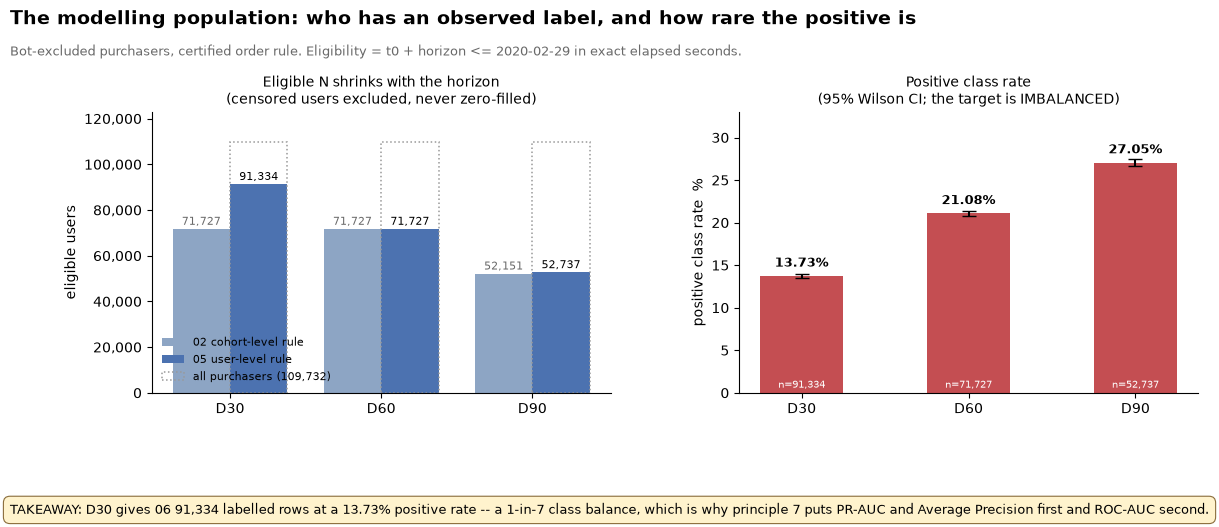

In [7]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.4))
fig.subplots_adjust(top=0.78, bottom=0.26, wspace=0.28)

x = np.arange(len(HORIZONS)); w = 0.38
ax.bar(x - w/2, rec.nb02_cohort_eligible_n, w, color="#8DA5C4", label="02 cohort-level rule")
ax.bar(x + w/2, rec.nb05_user_eligible_n,  w, color="#4C72B0", label="05 user-level rule")
ax.bar(x + w/2, [N_PURCHASERS]*3, w, color="none", edgecolor="#999999", linestyle=":", linewidth=1.1,
       label=f"all purchasers ({N_PURCHASERS:,})")
for xi, (a, b) in enumerate(zip(rec.nb02_cohort_eligible_n, rec.nb05_user_eligible_n)):
    ax.text(xi + w/2, b + 1800, f"{b:,}", ha="center", fontsize=8)
    ax.text(xi - w/2, a + 1800, f"{a:,}", ha="center", fontsize=8, color="dimgray")
ax.set_xticks(x); ax.set_xticklabels([f"D{h}" for h in HORIZONS])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax.set_ylabel("eligible users"); ax.set_ylim(0, N_PURCHASERS * 1.12)
ax.legend(fontsize=8, frameon=False, loc="lower left")
ax.set_title("Eligible N shrinks with the horizon\n(censored users excluded, never zero-filled)", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

ax2.bar(x, elig.positive_rate_pct, 0.5, color="#C44E52",
        yerr=[elig.positive_rate_pct - elig.ci_lo_pct, elig.ci_hi_pct - elig.positive_rate_pct], capsize=5)
for xi, (p, n) in enumerate(zip(elig.positive_rate_pct, elig.eligible_n)):
    ax2.text(xi, p + 1.1, f"{p:.2f}%", ha="center", fontsize=9, fontweight="bold")
    ax2.text(xi, 0.6, f"n={n:,}", ha="center", fontsize=7.5, color="white")
ax2.set_xticks(x); ax2.set_xticklabels([f"D{h}" for h in HORIZONS])
ax2.set_ylabel("positive class rate  %"); ax2.set_ylim(0, 33)
ax2.set_title("Positive class rate\n(95% Wilson CI; the target is IMBALANCED)", fontsize=10)
ax2.spines[["top", "right"]].set_visible(False)

add_title(fig, "The modelling population: who has an observed label, and how rare the positive is",
          "Bot-excluded purchasers, certified order rule. Eligibility = t0 + horizon <= 2020-02-29 in exact elapsed seconds.")
add_takeaway(fig, f"D{PRIMARY_H} gives 06 {int(elig.eligible_n[0]):,} labelled rows at a "
                  f"{float(elig.positive_rate_pct[0]):.2f}% positive rate -- a 1-in-7 class balance, which is why "
                  "principle 7 puts PR-AUC and Average Precision first and ROC-AUC second.")
save(fig, "nb05_eligibility_and_positive_rate"); plt.show()

## 4. Block M1 — the first order, at `t0`

Highest-value block and the lowest leakage risk, because everything in it is read off a
single order that happens exactly at the anchor. Two things in it still needed care.

### 4A. Price references must be built with `.shift().expanding()`

"Price percentile within category" and "discount versus the product's usual price" both
need a reference price, and the obvious reference — the product's median price over the
whole file — is forbidden (F3). A product whose price is cut in February would carry that
cut backwards into an October order's discount score.

The reference here is built from **strictly prior days only**: a daily price panel per
product and per category, then a window frame of `UNBOUNDED PRECEDING .. 1 PRECEDING`. That
is `.shift().expanding()` in SQL. A product's first-ever observed day has no reference and
gets `NULL` rather than an imputed one.

Below, the safe reference is compared against the forbidden full-dataset one so the size
of what F3 costs is measured rather than assumed.

In [8]:
t1 = time.time()
# ---- LEAKAGE-SAFE PRICE REFERENCE: .shift().expanding() over prior DAYS ------------------
# Daily panel first (3.1M product-days), then a window frame that can only see earlier days.
materialize(con, "prod_day", '''SELECT product_id, date_trunc('day', event_time) AS d,
    count(*) n, sum(price) sp, max(price) mx FROM ev WHERE price > 0 GROUP BY 1, 2''')
materialize(con, "prod_ref", '''
    -- RC-1: a float used as a RANK KEY. A parallel float aggregate wobbles in its last
    -- bits between runs; as a plain value that is cosmetic, but as a SORT KEY it decides
    -- an ORDERING, so a 1e-13 wobble becomes a whole-rank, ~1e-2 change in the percentile
    -- and the product_id tie-break never gets a chance to fire. round() first: then equal
    -- prices compare equal and product_id actually breaks the tie.
    -- Measured over two processes on this data: raw key -> 597,236 of 3,113,627
    -- percent_rank values differ, max |diff| 0.0423; rounded key -> 0 differ.
    -- prior_mean_price is rounded too (not just the key): it is written out and feeds
    -- fo_price_vs_prior_mean, the one feature 05 S11 caught flipping.
    SELECT product_id, d, round(psp/pn, 6) AS prior_mean_price, pmax AS prior_max_price,
           percent_rank() OVER (PARTITION BY d ORDER BY round(psp/pn, 6), product_id) AS prior_price_pct
    FROM (SELECT product_id, d, sum(n) OVER w AS pn, sum(sp) OVER w AS psp, max(mx) OVER w AS pmax
          FROM prod_day
          WINDOW w AS (PARTITION BY product_id ORDER BY d ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING))
    WHERE pn IS NOT NULL AND pn > 0''')
materialize(con, "cat_day", '''SELECT category_id, date_trunc('day', event_time) AS d, count(*) n,
    sum(ln(price)) slp, sum(ln(price)*ln(price)) slp2
    FROM ev WHERE price > 0 AND category_id IS NOT NULL GROUP BY 1, 2''')
materialize(con, "cat_ref", '''
    -- RC-1 class: cat_sd_lp is compared against a 0.05 cut below, so a last-bit wobble
    -- at the boundary would move a category in or out of the reference set.
    SELECT category_id, d, pn, round(plp/pn, 6) AS cat_mean_lp,
           round(sqrt(greatest(plp2/pn - (plp/pn)*(plp/pn), 0)), 6) AS cat_sd_lp
    FROM (SELECT category_id, d, sum(n) OVER w pn, sum(slp) OVER w plp, sum(slp2) OVER w plp2
          FROM cat_day
          WINDOW w AS (PARTITION BY category_id ORDER BY d ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING))
    WHERE pn >= 50 AND round(sqrt(greatest(plp2/pn - (plp/pn)*(plp/pn), 0)), 6) >= 0.05''')
print(f"prior-day price references built: prod_ref={con.execute('SELECT count(*) FROM prod_ref').fetchone()[0]:,} "
      f"product-days, cat_ref={con.execute('SELECT count(*) FROM cat_ref').fetchone()[0]:,} category-days "
      f"[{time.time()-t1:.0f}s]")
print("  cat_ref requires >=50 prior priced observations AND prior sd(log price) >= 0.05. Thin or")
print("  single-price categories produce a divide-by-almost-zero z-score, so they are NULLed, not clipped.")

# ---- what the FORBIDDEN full-dataset reference would have given ---------------------------
cmp_ref = con.execute('''
WITH full_ref AS (SELECT product_id, quantile_cont(price, 0.5) AS full_med,
                         max(price) AS full_max FROM ev WHERE price > 0 GROUP BY 1),
 lines AS (SELECT e.product_id, e.price, date_trunc('day', e.event_time) AS d
           FROM ev e JOIN first_order f ON e.user_id=f.user_id AND e.user_session=f.first_session
                AND e.event_time=f.first_ts WHERE e.event_type='purchase' AND e.price > 0)
SELECT count(*) AS first_order_lines,
       avg(CASE WHEN r.prior_max_price > 0 THEN 1.0 - l.price/r.prior_max_price END) AS mean_discount_SAFE,
       avg(CASE WHEN fr.full_max   > 0 THEN 1.0 - l.price/fr.full_max   END) AS mean_discount_FULL_DATASET,
       count(r.product_id)*1.0/count(*) AS safe_reference_coverage
FROM lines l LEFT JOIN prod_ref r ON l.product_id=r.product_id AND l.d=r.d
             LEFT JOIN full_ref fr ON l.product_id=fr.product_id''').fetchdf()
show_df(cmp_ref.round(5), name="nb05_price_reference_safe_vs_full")
print()
print(f"  A full-dataset reference reports mean discount {float(cmp_ref.mean_discount_FULL_DATASET[0]):.4f} "
      f"against the safe {float(cmp_ref.mean_discount_SAFE[0]):.4f}")
print(f"  -- {cmp_ref.mean_discount_FULL_DATASET[0]/cmp_ref.mean_discount_SAFE[0]:.1f}x larger, because it "
      "can see price cuts that had not happened yet.")
print(f"  Safe-reference coverage of first-order lines: {100*float(cmp_ref.safe_reference_coverage[0]):.2f}% "
      "(the rest are products on their first observed day).")

prior-day price references built: prod_ref=3,080,721 product-days, cat_ref=56,593 category-days [4s]
  cat_ref requires >=50 prior priced observations AND prior sd(log price) >= 0.05. Thin or
  single-price categories produce a divide-by-almost-zero z-score, so they are NULLed, not clipped.


   first_order_lines  mean_discount_SAFE  mean_discount_FULL_DATASET  safe_reference_coverage
0             831690             0.01477                     0.02341                  0.98731

  A full-dataset reference reports mean discount 0.0234 against the safe 0.0148
  -- 1.6x larger, because it can see price cuts that had not happened yet.
  Safe-reference coverage of first-order lines: 98.73% (the rest are products on their first observed day).


In [9]:
materialize(con, "fo_lines", '''SELECT e.user_id, e.product_id, e.category_id, e.brand, e.price,
    f.first_ts, date_trunc('day', e.event_time) AS d
    FROM ev e JOIN first_order f ON e.user_id=f.user_id AND e.user_session=f.first_session
         AND e.event_time=f.first_ts
    WHERE e.event_type = 'purchase' ''')
N_FO_LINES = con.execute("SELECT count(*) FROM fo_lines").fetchone()[0]

M1_SQL = '''
WITH pb AS (SELECT user_id, coalesce(brand,'__NULL__') b,
             row_number() OVER (PARTITION BY user_id ORDER BY count(*) DESC, coalesce(brand,'__NULL__')) rn
            FROM fo_lines GROUP BY 1, 2),
 pc AS (SELECT user_id, category_id,
             row_number() OVER (PARTITION BY user_id ORDER BY count(*) DESC, category_id) rn
            FROM fo_lines WHERE category_id IS NOT NULL GROUP BY 1, 2),
 px AS (SELECT l.user_id,
          avg(CASE WHEN r.prior_max_price > 0 THEN greatest(1.0 - l.price/r.prior_max_price, 0.0) END)
            AS fo_discount_vs_prior_max,
          avg(CASE WHEN r.prior_mean_price > 0 THEN l.price/r.prior_mean_price END) AS fo_price_vs_prior_mean,
          avg(r.prior_price_pct) AS fo_product_price_pct_prior,
          count(r.product_id)*1.0/count(*) AS fo_price_ref_coverage
        FROM fo_lines l LEFT JOIN prod_ref r ON l.product_id=r.product_id AND l.d=r.d GROUP BY 1),
 cz AS (SELECT l.user_id,
          avg(greatest(least((ln(l.price)-c.cat_mean_lp)/c.cat_sd_lp, 5.0), -5.0)) AS fo_price_z_in_category,
          count(c.category_id)*1.0/count(*) AS fo_catz_coverage
        FROM fo_lines l LEFT JOIN cat_ref c ON l.category_id=c.category_id AND l.d=c.d
        WHERE l.price > 0 GROUP BY 1),
 agg AS (SELECT user_id, max(first_ts) ft, count(*) fo_n_items,
          count(DISTINCT product_id) fo_n_products, count(DISTINCT category_id) fo_n_categories,
          count(DISTINCT brand) fo_n_brands,
          sum(CASE WHEN price > 0 THEN price ELSE 0 END) fo_value,
          max(price) fo_max_price, min(price) fo_min_price, quantile_cont(price, 0.5) fo_median_price,
          avg(CASE WHEN brand IS NULL THEN 1.0 ELSE 0.0 END) fo_brand_null_share
        FROM fo_lines GROUP BY 1)
SELECT a.user_id, a.fo_n_items, a.fo_n_products, a.fo_n_categories, a.fo_n_brands, a.fo_value,
       a.fo_max_price, a.fo_min_price, a.fo_median_price,
       a.fo_max_price - a.fo_min_price AS fo_price_range,
       a.fo_brand_null_share,
       pb.b AS fo_primary_brand, pc.category_id AS fo_primary_category,
       hour(a.ft) AS fo_hour, dayofweek(a.ft) AS fo_dow,
       CASE WHEN dayofweek(a.ft) IN (0, 6) THEN 1 ELSE 0 END AS fo_is_weekend,
       px.fo_discount_vs_prior_max, px.fo_price_vs_prior_mean, px.fo_product_price_pct_prior,
       px.fo_price_ref_coverage, cz.fo_price_z_in_category, cz.fo_catz_coverage
FROM agg a LEFT JOIN pb ON pb.user_id = a.user_id AND pb.rn = 1
           LEFT JOIN pc ON pc.user_id = a.user_id AND pc.rn = 1
           LEFT JOIN px ON px.user_id = a.user_id
           LEFT JOIN cz ON cz.user_id = a.user_id'''

BUILD_THREADS, FETCH_THREADS = 6, 1
def fetch_block(sql):
    """Fetch a feature frame with THREE determinism guards. 04 established the first two and this
       notebook found they are necessary but NOT sufficient -- see Section 11 for the measurement.
         threads=1 during the fetch  -- makes the parallel float reduction order deterministic
         round_sig(sig=6)            -- stabilises the VALUES
         sort_values('user_id')      -- stabilises the ROW ORDER (fetchdf returns scan order)
       Only the FETCH is single-threaded; the heavy materialisations above stay on 6 threads, where
       the wall clock actually lives. Measured cost of the extra guard: about 8 seconds in total."""
    con.execute(f"SET threads={FETCH_THREADS}")
    try:
        df = con.execute(sql).fetchdf()
    finally:
        con.execute(f"SET threads={BUILD_THREADS}")
    floats = [c for c in df.columns if df[c].dtype.kind == "f"]
    return round_sig(df, floats, sig=6).sort_values("user_id").reset_index(drop=True)

M1 = fetch_block(M1_SQL)
M1["fo_has_discount"] = (M1.fo_discount_vs_prior_max.fillna(0) > 1e-9).astype(int)
M1["first_order_is_bulk"] = (M1.fo_n_items >= BULK_ITEMS).astype(int)
# Winsorised monetary twin: constraint 6 forbids MEAN-based monetary features that the 143
# bulk buyers can move. The raw value is kept (a tree does not care); the winsorised one is
# what any mean/linear term in 06 should use.
V99 = float(M1.fo_value.quantile(0.99))
M1["fo_value_w"] = M1.fo_value.clip(upper=V99)
assert len(M1) == N_PURCHASERS and M1.user_id.is_unique
print(f"M1 built: {M1.shape[1]-1} features x {len(M1):,} users from {N_FO_LINES:,} first-order purchase lines "
      f"[{time.time()-t1:.0f}s]")
print(f"  fo_value winsorised at P99 = {V99:,.2f} EUR for the mean-safe twin; "
      f"{int((M1.fo_value > V99).sum()):,} users capped, {int(M1.first_order_is_bulk.sum())} of them bulk.")
print()
print("BRAND COVERAGE -- NULL is its own level, never imputed (brand is 42.3% null project-wide)")
print("=" * 94)
nb = int((M1.fo_primary_brand == "__NULL__").sum())
print(f"  first orders whose primary brand is the NULL level : {nb:,} ({100*nb/len(M1):.2f}%)")
print(f"  mean share of first-order lines with no brand      : {100*M1.fo_brand_null_share.mean():.2f}%")
print(f"  distinct primary brands                            : {M1.fo_primary_brand.nunique():,}")
print(f"  distinct primary categories (structural id, unlabelled -- category_code is 98.3% null): "
      f"{M1.fo_primary_category.nunique():,}")
print("  Both are HIGH-CARDINALITY categoricals. Flagged in the dictionary: 06 must target- or")
print("  frequency-encode them INSIDE its chronological split, never on the full table.")

M1 built: 24 features x 109,732 users from 831,777 first-order purchase lines [9s]
  fo_value winsorised at P99 = 207.94 EUR for the mean-safe twin; 1,097 users capped, 110 of them bulk.

BRAND COVERAGE -- NULL is its own level, never imputed (brand is 42.3% null project-wide)
  first orders whose primary brand is the NULL level : 64,647 (58.91%)
  mean share of first-order lines with no brand      : 40.67%
  distinct primary brands                            : 234
  distinct primary categories (structural id, unlabelled -- category_code is 98.3% null): 433
  Both are HIGH-CARDINALITY categoricals. Flagged in the dictionary: 06 must target- or
  frequency-encode them INSIDE its chronological split, never on the full table.


### 4C. `is_bulk_buyer` as 02 persisted it is a forbidden feature

02 flagged 143 reseller-like users as `is_bulk_buyer` and CLAUDE.md requires carrying that
flag. The flag is defined as *"has at least one order of ≥ 90.6 items"* over the **whole**
observation window — so for a user whose big haul comes after `t0`, the flag is an
outcome-window aggregate (F2). It is kept as a **population flag** for reporting, exactly
as constraint 6 requires, and replaced for modelling by `first_order_is_bulk`, which asks
the same question of the first order alone.

In [10]:
bulk_cmp = chk[["user_id", "is_bulk_buyer"]].merge(M1[["user_id", "first_order_is_bulk"]], on="user_id")
n_full = int(bulk_cmp.is_bulk_buyer.sum()); n_fo = int(bulk_cmp.first_order_is_bulk.sum())
n_both = int((bulk_cmp.is_bulk_buyer & bulk_cmp.first_order_is_bulk.astype(bool)).sum())
n_leak = n_full - n_both
print("BULK-BUYER FLAG: full-history (02) vs first-order-only (leakage-safe)")
print("=" * 94)
print(f"  02's is_bulk_buyer (any order >= {BULK_ITEMS:.1f} items, full history) : {n_full:,} users")
print(f"  first_order_is_bulk (the FIRST order clears the bar)          : {n_fo:,} users")
print(f"  both                                                          : {n_both:,}")
print(f"  flagged by 02 but NOT by their first order                     : {n_leak:,} "
      f"({100*n_leak/max(n_full,1):.1f}% of the flag)")
print()
print(f"  So {n_leak} of the {n_full} bulk buyers are flagged on evidence that does not exist at t0. For a")
print("  D30 model that is {0:.1f}% of the flag carrying outcome-window information.".format(100*n_leak/max(n_full,1)))
assert n_full == BULK["n_users"], (n_full, BULK["n_users"])
print()
print("  DECISION: is_bulk_buyer_fullhistory is persisted in features.parquet as a POPULATION FLAG with")
print("  model_eligible=False (constraint 6 requires it be carried and reported); first_order_is_bulk is")
print("  the M1 feature. Section 9's audit will list is_bulk_buyer_fullhistory as excluded-by-design, not")
print("  as a violation.")

BULK-BUYER FLAG: full-history (02) vs first-order-only (leakage-safe)
  02's is_bulk_buyer (any order >= 90.6 items, full history) : 143 users
  first_order_is_bulk (the FIRST order clears the bar)          : 110 users
  both                                                          : 110
  flagged by 02 but NOT by their first order                     : 33 (23.1% of the flag)

  So 33 of the 143 bulk buyers are flagged on evidence that does not exist at t0. For a
  D30 model that is 23.1% of the flag carrying outcome-window information.

  DECISION: is_bulk_buyer_fullhistory is persisted in features.parquet as a POPULATION FLAG with
  model_eligible=False (constraint 6 requires it be carried and reported); first_order_is_bulk is
  the M1 feature. Section 9's audit will list is_bulk_buyer_fullhistory as excluded-by-design, not
  as a violation.


## 5. Block M2 — the first-order session, truncated at `t0`

Every M2 feature is computed over `user_session = first_session AND event_time < t0`. The
truncation is what Section 1A showed is necessary.

Two consequences, both reported rather than patched:

- **`ended_in_purchase` is degenerate.** The first-order session is the converting session
  by definition, so the feature is constant `True` for all 109,732 users. It is built,
  shown to be constant, and excluded. The non-degenerate version of the same idea —
  *did the user convert in their very first session ever* — is `has_prior_sessions` in M3.
- **11,830 users have no first-order-session events before `t0` at all.** Their first
  recorded action in that session *is* the purchase. Every M2 feature is `NULL` for them
  and `fs_has_pre_purchase_events = 0` says so. Nothing is imputed: "bought with no
  observed deliberation" is a real behaviour and imputing a median would erase it.

In [11]:
materialize(con, "pre_ev", "SELECT * FROM uev WHERE event_time < first_ts")
materialize(con, "pre_sess", '''SELECT user_id, user_session, min(event_time) s_start,
    max(event_time) s_end, count(*) n_ev,
    max(CASE WHEN user_session = first_session THEN 1 ELSE 0 END) is_fs
    FROM pre_ev GROUP BY 1, 2''')
N_PRE_EV = con.execute("SELECT count(*) FROM pre_ev").fetchone()[0]

M2_SQL = '''
WITH fs AS (SELECT * FROM pre_ev WHERE user_session = first_session),
 ent AS (SELECT user_id, event_type AS fs_entry_event_type,
          -- price, category_id complete the tie-break; event_type is already in the key,
          -- so the one projected column was invariant either way.
          row_number() OVER (PARTITION BY user_id            -- RC-1: round the float in the key
                             ORDER BY event_time, event_type, product_id, round(price, 6),
                                      category_id) rn FROM fs),
 agg AS (SELECT user_id, min(event_time) fs_start, max(first_ts) ft, count(*) fs_n_events,
          count(*) FILTER (WHERE event_type='view') fs_n_view_ev,
          count(*) FILTER (WHERE event_type='cart') fs_n_cart_ev,
          count(*) FILTER (WHERE event_type='remove_from_cart') fs_n_removals,
          count(DISTINCT product_id) FILTER (WHERE event_type='view') fs_p_viewed,
          count(DISTINCT product_id) fs_p_touched,
          count(DISTINCT category_id) fs_n_categories,
          count(DISTINCT brand) fs_n_brands,
          max(price) FILTER (WHERE event_type='view' AND price > 0) fs_max_price_viewed,
          quantile_cont(price, 0.9) FILTER (WHERE event_type='view' AND price > 0)
            - quantile_cont(price, 0.1) FILTER (WHERE event_type='view' AND price > 0) fs_price_range_viewed,
          max(CASE WHEN event_type='purchase' THEN 1 ELSE 0 END) fs_purchase_before_t0
         FROM fs GROUP BY 1)
SELECT a.user_id, a.fs_n_events, a.fs_n_view_ev, a.fs_n_cart_ev, a.fs_n_removals,
       a.fs_p_viewed, a.fs_p_touched, a.fs_n_categories, a.fs_n_brands,
       a.fs_max_price_viewed, greatest(a.fs_price_range_viewed, 0) AS fs_price_range_viewed,
       date_diff('second', a.fs_start, a.ft)/60.0 AS fs_duration_min,
       hour(a.fs_start) AS fs_start_hour, dayofweek(a.fs_start) AS fs_start_dow,
       e.fs_entry_event_type, a.fs_purchase_before_t0
FROM agg a LEFT JOIN ent e ON e.user_id = a.user_id AND e.rn = 1'''

M2 = fetch_block(M2_SQL)
print(f"M2 built: {M2.shape[1]-1} columns x {len(M2):,} users with pre-t0 first-session activity "
      f"(of {N_PURCHASERS:,} purchasers)")
print()
print("DEGENERACY CHECK -- run, not assumed")
print("=" * 94)
# `ended_in_purchase` as normally specified:
ended = con.execute('''SELECT count(DISTINCT user_id) FROM uev
    WHERE user_session = first_session AND event_type='purchase' AND event_time = first_ts''').fetchone()[0]
print(f"  fs_ended_in_purchase would be TRUE for {ended:,} of {N_PURCHASERS:,} users = "
      f"{100*ended/N_PURCHASERS:.1f}%. CONSTANT.")
print("  DROPPED. It carries zero information and would consume a degree of freedom in 06's nested LR test.")
print(f"  fs_purchase_before_t0 (a purchase in the first session STRICTLY BEFORE t0): "
      f"{int(M2.fs_purchase_before_t0.sum())} users -- also constant at 0, by the definition of t0.")
assert ended == N_PURCHASERS, "fs_ended_in_purchase is not constant -- the anchor is wrong"
assert int(M2.fs_purchase_before_t0.sum()) == 0
M2 = M2.drop(columns=["fs_purchase_before_t0"])
print()
print("MISSINGNESS -- explicit, never imputed")
print("=" * 94)
n_nofs = N_PURCHASERS - len(M2)
print(f"  {n_nofs:,} users ({100*n_nofs/N_PURCHASERS:.2f}%) have NO first-order-session event before t0.")
print("  Their first recorded action in that session is the purchase itself. All M2 features are NULL")
print("  for them and fs_has_pre_purchase_events = 0 records it.")
print()
print(f"  fs_entry_event_type distribution (n={len(M2):,}):")
for k, v in M2.fs_entry_event_type.value_counts().items():
    print(f"    {k:<18s} {v:>7,}  ({100*v/len(M2):5.2f}%)")
print()
print(f"  fs_max_price_viewed / fs_price_range_viewed are NULL for a further "
      f"{int(M2.fs_max_price_viewed.isna().sum()):,} users who reached the first order without a single")
print("  priced VIEW event -- straight to cart. Also recorded, not filled.")
print()
print(f"  fs_duration_min: median {M2.fs_duration_min.median():.1f} min, P99 {M2.fs_duration_min.quantile(0.99):,.0f} min,")
print(f"  max {M2.fs_duration_min.max():,.0f} min ({M2.fs_duration_min.max()/1440:.0f} days). The tail is 00's")
print("  session-ID reuse (sessions_over_24h, 2.16%), not a shopper deliberating for months. 06 should")
print("  treat this feature as log-scaled or binned; it is flagged in the dictionary.")

M2 built: 15 columns x 97,902 users with pre-t0 first-session activity (of 109,732 purchasers)

DEGENERACY CHECK -- run, not assumed


  fs_ended_in_purchase would be TRUE for 109,732 of 109,732 users = 100.0%. CONSTANT.
  DROPPED. It carries zero information and would consume a degree of freedom in 06's nested LR test.
  fs_purchase_before_t0 (a purchase in the first session STRICTLY BEFORE t0): 0 users -- also constant at 0, by the definition of t0.

MISSINGNESS -- explicit, never imputed
  11,830 users (10.78%) have NO first-order-session event before t0.
  Their first recorded action in that session is the purchase itself. All M2 features are NULL
  for them and fs_has_pre_purchase_events = 0 records it.

  fs_entry_event_type distribution (n=97,902):
    view                54,731  (55.90%)
    cart                32,576  (33.27%)
    remove_from_cart    10,595  (10.82%)

  fs_max_price_viewed / fs_price_range_viewed are NULL for a further 16,356 users who reached the first order without a single
  priced VIEW event -- straight to cart. Also recorded, not filled.

  fs_duration_min: median 16.8 min, P99 5,722 min

## 6. Block M3 — everything known before `t0`

All events with `event_time < t0`, which **includes** the pre-purchase part of the
first-order session. That makes M2 a strict subset of M3 in event terms. The alternative —
restricting M3 to prior sessions only — would make the blocks disjoint but would leave M3
entirely empty for every user whose first order came in their first session -- a large
minority, counted below, and the population 08 most needs. So M3 is the full pre-purchase information set, the M2/M3
overlap is declared here, `pre_n_prior_sessions` and `has_prior_sessions` are carried so 06
can construct a disjoint nesting if it prefers, and Section 10 flags the correlated pairs.

### 6A. `cart_abandonment_rate` cannot be carried forward from 04

In [12]:
n_pre_purch = con.execute("SELECT count(*) FROM pre_ev WHERE event_type='purchase'").fetchone()[0]
print("THE PRE-t0 WINDOW CONTAINS NO PURCHASES -- so 04's abandonment rate is degenerate here")
print("=" * 94)
print(f"  purchase events with event_time < t0 : {n_pre_purch}")
assert n_pre_purch == 0, "t0 is not the first order"
print()
print("  04's cart_abandonment_rate = (distinct products carted and never bought) / (distinct products")
print("  carted). Before the first order NOTHING has been bought, so the numerator equals the")
print("  denominator and the rate is 1.0 for every user who has one. Confirmed below on real rows.")
print()
degen = con.execute('''
WITH c AS (SELECT DISTINCT user_id, product_id FROM pre_ev WHERE event_type='cart'),
     b AS (SELECT DISTINCT user_id, product_id FROM pre_ev WHERE event_type='purchase')
SELECT count(DISTINCT c.user_id) AS users_with_a_cart,
       count(*) FILTER (WHERE b.product_id IS NOT NULL) AS carted_and_bought_pre_t0
FROM c LEFT JOIN b ON c.user_id=b.user_id AND c.product_id=b.product_id''').fetchdf()
show_df(degen, name="nb05_pre_window_abandonment_degeneracy")
print()
print("  CONSEQUENCE, and it reaches further than one feature: cart_abandonment_rate is one of the EIGHT")
print("  features segment_model.json was fitted on. 04 computed it over FULL history, which includes")
print("  post-t0 purchases -- so as a predictor of a post-t0 outcome it is an F1 violation, and the")
print("  fitted model cannot be applied faithfully to a pre-t0 window either. Section 8 quantifies that.")
print()
print("  REPLACEMENTS, both strictly pre-t0 or at-t0:")
print("    pre_cart_not_in_first_order_rate = share of pre-t0 carted products NOT in the first order.")
print("      Uses only the feature window, is defined for everyone with a cart, and asks the question")
print("      04 meant to ask: how much of what you put in the basket did you actually leave behind.")
print("    pre_removal_per_cart = removals / cart adds. Pure abandonment VOLUME, which is the one thing")
print("      02 Section 0E found survives a disjoint-window re-test (OR 1.38).")

THE PRE-t0 WINDOW CONTAINS NO PURCHASES -- so 04's abandonment rate is degenerate here
  purchase events with event_time < t0 : 0

  04's cart_abandonment_rate = (distinct products carted and never bought) / (distinct products
  carted). Before the first order NOTHING has been bought, so the numerator equals the
  denominator and the rate is 1.0 for every user who has one. Confirmed below on real rows.



   users_with_a_cart  carted_and_bought_pre_t0
0             108346                         0

  CONSEQUENCE, and it reaches further than one feature: cart_abandonment_rate is one of the EIGHT
  features segment_model.json was fitted on. 04 computed it over FULL history, which includes
  post-t0 purchases -- so as a predictor of a post-t0 outcome it is an F1 violation, and the
  fitted model cannot be applied faithfully to a pre-t0 window either. Section 8 quantifies that.

  REPLACEMENTS, both strictly pre-t0 or at-t0:
    pre_cart_not_in_first_order_rate = share of pre-t0 carted products NOT in the first order.
      Uses only the feature window, is defined for everyone with a cart, and asks the question
      04 meant to ask: how much of what you put in the basket did you actually leave behind.
    pre_removal_per_cart = removals / cart adds. Pure abandonment VOLUME, which is the one thing
      02 Section 0E found survives a disjoint-window re-test (OR 1.38).


In [13]:
M3_SQL = '''
WITH cn AS (SELECT user_id, count(*) pre_n_events,
      count(*) FILTER (WHERE event_type='view') pre_n_view_ev,
      count(*) FILTER (WHERE event_type='cart') pre_n_cart_ev,
      count(*) FILTER (WHERE event_type='remove_from_cart') pre_n_removals,
      count(DISTINCT product_id) pre_n_products,
      count(DISTINCT product_id) FILTER (WHERE event_type='view') pre_p_viewed,
      count(DISTINCT product_id) FILTER (WHERE event_type='cart') pre_p_carted,
      count(DISTINCT category_id) pre_n_categories,
      count(DISTINCT brand) pre_n_brands,
      count(DISTINCT date_trunc('day', event_time)) pre_n_active_days,
      min(event_time) first_event_ts, max(event_time) last_pre_event_ts, max(first_ts) ft
     FROM pre_ev GROUP BY 1),
 ss AS (SELECT user_id, count(*) pre_n_sessions,
        sum(CASE WHEN is_fs = 0 THEN 1 ELSE 0 END) pre_n_prior_sessions,
        avg(n_ev) pre_mean_session_depth FROM pre_sess GROUP BY 1),
 fo AS (SELECT DISTINCT e.user_id, e.product_id FROM ev e JOIN first_order f
          ON e.user_id=f.user_id AND e.user_session=f.first_session AND e.event_time=f.first_ts
        WHERE e.event_type='purchase'),
 cart AS (SELECT DISTINCT user_id, product_id FROM pre_ev WHERE event_type='cart'),
 ab AS (SELECT c.user_id, 1.0 - count(fo.product_id)*1.0/count(*) AS pre_cart_not_in_first_order_rate
        FROM cart c LEFT JOIN fo ON c.user_id=fo.user_id AND c.product_id=fo.product_id GROUP BY 1),
 bd AS (SELECT user_id, coalesce(brand,'__NULL__') lvl, count(*) c FROM pre_ev
        WHERE event_type='view' GROUP BY 1, 2),
 be AS (SELECT user_id, -sum(pr*log2(pr)) pre_brand_entropy,
          coalesce(sum(c) FILTER (WHERE lvl <> '__NULL__'), 0)*1.0/sum(c) pre_brand_coverage
        FROM (SELECT user_id, lvl, c, c*1.0/sum(c) OVER (PARTITION BY user_id) pr FROM bd) GROUP BY 1),
 cd AS (SELECT user_id, category_id lvl, count(*) c FROM pre_ev
        WHERE event_type='view' AND category_id IS NOT NULL GROUP BY 1, 2),
 ce AS (SELECT user_id, -sum(pr*log2(pr)) pre_category_entropy
        FROM (SELECT user_id, lvl, c, c*1.0/sum(c) OVER (PARTITION BY user_id) pr FROM cd) GROUP BY 1),
 pp AS (SELECT p.user_id, avg(r.prior_price_pct) pre_mean_price_pct_viewed,
          quantile_cont(r.prior_price_pct, 0.9) - quantile_cont(r.prior_price_pct, 0.1)
            AS pre_price_range_viewed
        FROM pre_ev p JOIN prod_ref r ON p.product_id=r.product_id
             AND date_trunc('day', p.event_time) = r.d
        WHERE p.event_type='view' GROUP BY 1)
SELECT cn.user_id, cn.pre_n_events, cn.pre_n_view_ev, cn.pre_n_cart_ev, cn.pre_n_removals,
       cn.pre_n_products, cn.pre_p_viewed, cn.pre_p_carted, cn.pre_n_categories, cn.pre_n_brands,
       cn.pre_n_active_days,
       date_diff('second', cn.first_event_ts, cn.ft)/86400.0 AS tenure_d,
       date_diff('second', cn.last_pre_event_ts, cn.ft)/86400.0 AS pre_days_since_last_event,
       ss.pre_n_sessions, ss.pre_n_prior_sessions, ss.pre_mean_session_depth,
       cn.pre_p_carted*1.0/nullif(cn.pre_p_viewed, 0) AS pre_view_to_cart,
       cn.pre_n_removals*1.0/nullif(cn.pre_n_cart_ev, 0) AS pre_removal_per_cart,
       ab.pre_cart_not_in_first_order_rate,
       be.pre_brand_entropy, be.pre_brand_coverage, ce.pre_category_entropy,
       pp.pre_mean_price_pct_viewed, pp.pre_price_range_viewed
FROM cn LEFT JOIN ss ON ss.user_id = cn.user_id
        LEFT JOIN ab ON ab.user_id = cn.user_id
        LEFT JOIN be ON be.user_id = cn.user_id
        LEFT JOIN ce ON ce.user_id = cn.user_id
        LEFT JOIN pp ON pp.user_id = cn.user_id'''

M3 = fetch_block(M3_SQL)
M3["log1p_pre_n_removals"] = np.log1p(M3.pre_n_removals)
M3["has_prior_sessions"]   = (M3.pre_n_prior_sessions > 0).astype(int)
print(f"M3 built: {M3.shape[1]-1} features x {len(M3):,} users from {N_PRE_EV:,} pre-t0 events "
      f"[{time.time()-t1:.0f}s]")
print(f"  {N_PURCHASERS - len(M3):,} purchasers have NO pre-t0 event at all -- their very first recorded")
print("  event IS the purchase. All M3 features are NULL for them; nothing is imputed.")
print()
print("  sanity: pre_cart_not_in_first_order_rate is no longer degenerate --")
print(f"    mean {M3.pre_cart_not_in_first_order_rate.mean():.4f}, "
      f"median {M3.pre_cart_not_in_first_order_rate.median():.4f}, "
      f"sd {M3.pre_cart_not_in_first_order_rate.std():.4f}, "
      f"share at exactly 1.0 {100*(M3.pre_cart_not_in_first_order_rate == 1).mean():.1f}%")
print()
n_fsconv = int((M3.pre_n_prior_sessions == 0).sum())
print(f"  {n_fsconv:,} purchasers ({100*n_fsconv/N_PURCHASERS:.1f}%) have NO session before the one they bought in.")
print("  That is why M3 is defined over ALL pre-t0 events rather than over prior sessions only: the")
print("  disjoint definition would leave a third of the population with an empty M3 block.")
print()
print("  DEGENERACY WARNING on pre_days_since_last_event: median "
      f"{M3.pre_days_since_last_event.median()*24*60:.1f} MINUTES.")
print("  Almost every user's last pre-t0 event is a click in the buying session itself, seconds before")
print("  the order, so this is not a recency feature -- it is a measure of checkout speed. The feature")
print("  that carries genuine pre-purchase recency is gap_before_purchase_visit in M4.")

M3 built: 25 features x 109,132 users from 5,351,448 pre-t0 events [26s]
  600 purchasers have NO pre-t0 event at all -- their very first recorded
  event IS the purchase. All M3 features are NULL for them; nothing is imputed.

  sanity: pre_cart_not_in_first_order_rate is no longer degenerate --
    mean 0.2884, median 0.2500, sd 0.2782, share at exactly 1.0 0.2%

  35,947 purchasers (32.8%) have NO session before the one they bought in.
  That is why M3 is defined over ALL pre-t0 events rather than over prior sessions only: the
  disjoint definition would leave a third of the population with an empty M3 block.

  DEGENERACY WARNING on pre_days_since_last_event: median 3.5 MINUTES.
  Almost every user's last pre-t0 event is a click in the buying session itself, seconds before
  the order, so this is not a recency feature -- it is a measure of checkout speed. The feature
  that carries genuine pre-purchase recency is gap_before_purchase_visit in M4.


### 6B. Tenure normalisation (constraint 5) and the anchor-sensitivity re-test (constraint 2)

04 §9C established that part of what the clustering called *behaviour* was really *tenure*:
cell B1 looked engaged because it had been observable for 124 days, and per tenure-day it
browsed at 0.43× the rate of its own segment. The instruction to 05 was to tenure-normalise
**or** carry tenure explicitly. This block does both — `tenure_d` is a first-class feature
and every behavioural count gets a per-tenure-day twin — so 06 can test which form carries
the signal instead of inheriting the confound.

03 also warned that abandonment volume is anchor-sensitive: `log1p(n_removals)` scores
OR 1.37–1.44 first-order-anchored and collapses to 1.03–1.14 calendar-anchored. This
notebook is first-order-anchored, so the band is a prediction that can be checked.

In [14]:
# --- constraint 5: per-tenure-day twins ---------------------------------------------------
TEN_FLOOR = 1.0/1440.0          # one minute, so a same-minute first order cannot divide by zero
M3["tenure_d_pos"] = M3.tenure_d.clip(lower=TEN_FLOOR)
TENURE_TWINS = [("pre_n_view_ev",  "pre_views_per_tenure_day"),
                ("pre_n_sessions", "pre_sessions_per_tenure_day"),
                ("pre_n_events",   "pre_events_per_tenure_day"),
                ("pre_n_products", "pre_products_per_tenure_day")]
for src, dst in TENURE_TWINS:
    M3[dst] = M3[src] / M3.tenure_d_pos
M3 = round_sig(M3, [c for c in M3.columns if M3[c].dtype.kind == "f"], sig=6)

print("TENURE, AND WHY IT HAS TO BE CARRIED (constraint 5)")
print("=" * 94)
print(f"  tenure_d = days from the user's first EVENT to t0.  median {M3.tenure_d.median():.2f}d, "
      f"IQR [{M3.tenure_d.quantile(.25):.3f}, {M3.tenure_d.quantile(.75):.2f}], max {M3.tenure_d.max():.1f}d")
print(f"  {100*(M3.tenure_d < 1).mean():.1f}% of purchasers place their first order within 24h of their "
      "first ever event.")
print()
print("  Spearman rho against tenure -- 04 §9C's confound, restated on this table:")
tn = M3[M3.tenure_d.notna()]
rows = []
for src, dst in TENURE_TWINS:
    rows.append({"raw_feature": src,
                 "rho_raw_vs_tenure": round(stats.spearmanr(tn.tenure_d, tn[src]).statistic, 3),
                 "normalised_twin": dst,
                 "rho_twin_vs_tenure": round(stats.spearmanr(tn.tenure_d, tn[dst]).statistic, 3)})
ten_tab = pd.DataFrame(rows)
show_df(ten_tab, name="nb05_tenure_normalisation")
print()
print("  Every raw count is strongly tenure-driven; every normalised twin inverts, because a")
print("  long-tenured user accumulates events slowly per day. BOTH forms are in the table and both are")
print("  labelled in the dictionary. 06 decides which carries signal -- it is not decided here, and it")
print("  is not left implicit the way 04's eight unnormalised features left it.")

TENURE, AND WHY IT HAS TO BE CARRIED (constraint 5)
  tenure_d = days from the user's first EVENT to t0.  median 0.24d, IQR [0.017, 10.50], max 151.2d
  57.2% of purchasers place their first order within 24h of their first ever event.

  Spearman rho against tenure -- 04 §9C's confound, restated on this table:


      raw_feature  rho_raw_vs_tenure              normalised_twin  rho_twin_vs_tenure
0   pre_n_view_ev              0.605     pre_views_per_tenure_day              -0.632
1  pre_n_sessions              0.703  pre_sessions_per_tenure_day              -0.955
2    pre_n_events              0.609    pre_events_per_tenure_day              -0.916
3  pre_n_products              0.587  pre_products_per_tenure_day              -0.911

  Every raw count is strongly tenure-driven; every normalised twin inverts, because a
  long-tenured user accumulates events slowly per day. BOTH forms are in the table and both are
  labelled in the dictionary. 06 decides which carries signal -- it is not decided here, and it
  is not left implicit the way 04's eight unnormalised features left it.


In [15]:
# --- constraint 2: re-measure the removal-volume odds ratio on THIS table -------------------
print("ANCHOR-SENSITIVITY RE-TEST (constraint 2) -- does log1p(n_removals) land in 03's 1.37-1.44 band?")
print("=" * 94)
d30 = tgt.loc[tgt.eligible_30d, ["user_id", "repeat_purchase_30d", "first_ts"]].merge(
        M3[["user_id", "log1p_pre_n_removals"]], on="user_id", how="left").dropna()
X = sm.add_constant(d30[["log1p_pre_n_removals"]])
res = sm.Logit(d30.repeat_purchase_30d.astype(int), X).fit(disp=0)
orv = float(np.exp(res.params["log1p_pre_n_removals"]))
lo, hi = np.exp(res.conf_int().loc["log1p_pre_n_removals"])
band = handoff["churn_definition"]["sensitivity_of_01_02_headlines"]["removal_volume_OR"]
print(f"  first-order-anchored, outcome = repeat_purchase_30d, n = {len(d30):,}")
print(f"  OR(log1p pre-t0 removals) = {orv:.3f}  [{lo:.3f}, {hi:.3f}]")
print(f"  03 committed: {band}")
print(f"  02 Section 0E committed: OR = {float(LEAK['what_survives'].split('OR=')[1].split()[0]):.2f}")
in_band = 1.37 <= orv <= 1.44
print()
print(f"  IN BAND: {in_band}. " + ("The prediction holds on an independently built feature window."
      if in_band else "It does NOT, and that is reported rather than reconciled away."))
print("  Note what is and is not being claimed: this is a UNIVARIATE association on the full eligible")
print("  frame with no chronological split. It confirms the feature is on the scale 03 said it would be")
print("  on. It is not a model result, and 06 owns the adjusted estimate.")
print()
print("  CALENDAR POSITION IS CARRIED, per the constraint. t0_calendar_day = days from 2019-10-01 to t0.")
print("  It is marked model_eligible = FALSE in the dictionary: under 06's CHRONOLOGICAL split it is a")
print("  near-perfect train/test discriminator and would not generalise. It is in the table so 06 can")
print("  run the re-anchoring test, not so 06 can fit on it.")

ANCHOR-SENSITIVITY RE-TEST (constraint 2) -- does log1p(n_removals) land in 03's 1.37-1.44 band?
  first-order-anchored, outcome = repeat_purchase_30d, n = 90,815
  OR(log1p pre-t0 removals) = 1.307  [1.289, 1.325]
  03 committed: first-order-anchored 1.37-1.44 at every K (02 committed 1.38); re-anchored to a calendar date it collapses to 1.03-1.14
  02 Section 0E committed: OR = 1.38

  IN BAND: False. It does NOT, and that is reported rather than reconciled away.
  Note what is and is not being claimed: this is a UNIVARIATE association on the full eligible
  frame with no chronological split. It confirms the feature is on the scale 03 said it would be
  on. It is not a model result, and 06 owns the adjusted estimate.

  CALENDAR POSITION IS CARRIED, per the constraint. t0_calendar_day = days from 2019-10-01 to t0.
  It is marked model_eligible = FALSE in the dictionary: under 06's CHRONOLOGICAL split it is a
  near-perfect train/test discriminator and would not generalise. It is in t

## 7. Block M4 — the personalised cadence feature, and its honest limit

04 §9B found the mechanism behind the churn rule's blind spot: at-risk users with 2+ orders
have a median personal inter-purchase gap of 13.8 days against a global threshold of 42.2,
and 88.1% sit below it, so the global rule waits long past the point their habit broke. The
recommendation to 05/06 was a personalised, cadence-multiple threshold rather than a
different global K. The instruction to this notebook was to build it and test it.

**It cannot be built in the form 04 specified, and the reason is structural rather than a
data gap.** `t0` is the *first* order. Every user has exactly one order at the anchor, so
the number of observed inter-purchase gaps is zero — for **100%** of the population, not
the ~77% the brief anticipated. There is no imputation that fixes this; a personal purchase
cadence is not missing, it does not exist yet.

So this section does two things instead:

1. **Builds the nearest defined thing — visit cadence.** The rhythm of a user's *sessions*
   before `t0` is observable, and the personalised quantity that mirrors 04 §9B is
   `cad_lapse_ratio` = the gap before the buying visit divided by the user's own median
   historical gap. That ratio is not a deterministic function of either part, which matters:
   `horizon / cadence` would be, so "how many of my cycles fit in 30 days" is not a testable
   addition to a model that already holds the cadence.
2. **Tests whether it beats the absolute-days form**, which is the actual question — is the
   *personal* denominator worth anything, or is the raw gap enough?

In [16]:
print("STEP 1 -- confirm purchase cadence is structurally undefined at t0")
print("=" * 94)
tie = con.execute('''
SELECT count(*) FILTER (WHERE n_before > 0) AS users_with_an_order_strictly_before_t0,
       count(*) FILTER (WHERE n_at > 1)     AS users_with_a_second_order_at_exactly_t0
FROM (SELECT f.user_id,
        count(*) FILTER (WHERE o.order_ts <  f.first_ts) AS n_before,
        count(*) FILTER (WHERE o.order_ts =  f.first_ts) AS n_at
      FROM first_order f LEFT JOIN orders o ON o.user_id = f.user_id GROUP BY 1)''').fetchdf()
show_df(tie, name="nb05_orders_at_or_before_t0")
n_before = int(tie.users_with_an_order_strictly_before_t0[0])
n_tie    = int(tie.users_with_a_second_order_at_exactly_t0[0])
assert n_before == 0, "t0 is not the first order"
print()
print(f"  purchasers with an order STRICTLY BEFORE t0                 : {n_before}")
print(f"  purchasers with a second order at EXACTLY t0, other session : {n_tie}")
print(f"  => observed NON-ZERO inter-purchase gaps at t0              : 0 for all {N_PURCHASERS:,} users (100%)")
print()
print(f"  The {n_tie} exception is the session-ID collision 00 documented: one user has purchase rows at the")
print("  same second under two session ids, so the certified rule splits them into two orders and the")
print("  first_order tiebreaker (order_ts, user_session) picks one. The implied gap is zero days, which")
print("  is not a cadence either. Purchase cadence is undefined for the whole population.")
print()
print("  04 §9B's feature is therefore not buildable at this anchor. It IS buildable at a second-order")
print("  anchor -- 06 or 08 could re-anchor on the 2nd order and predict the 3rd -- and that is recorded")
print("  as the honest next test rather than approximated here.")
print()
print("STEP 2 -- visit cadence, the nearest quantity that exists before t0")
print("=" * 94)

CAD_SQL = '''
WITH g AS (SELECT user_id, user_session, s_start,
             date_diff('second', lag(s_start) OVER (PARTITION BY user_id ORDER BY s_start, user_session),
                       s_start)/86400.0 AS gap_d,
             row_number() OVER (PARTITION BY user_id ORDER BY s_start DESC, user_session DESC) AS rn_desc
           FROM pre_sess),
 hist AS (SELECT user_id, count(*) AS cad_n_hist_gaps,
            quantile_cont(gap_d, 0.5) AS cad_median_gap_d,
            quantile_cont(gap_d, 0.75) - quantile_cont(gap_d, 0.25) AS cad_iqr_gap_d
          FROM g WHERE gap_d IS NOT NULL AND rn_desc > 1 GROUP BY 1),
 lastg AS (SELECT user_id, gap_d AS gap_before_purchase_visit FROM g WHERE rn_desc = 1),
 dd AS (SELECT DISTINCT user_id, date_trunc('day', event_time) AS dday FROM pre_ev),
 dg AS (SELECT user_id, dday,
          date_diff('day', lag(dday) OVER (PARTITION BY user_id ORDER BY dday), dday) AS gap,
          row_number() OVER (PARTITION BY user_id ORDER BY dday DESC) AS rn_desc FROM dd),
 dayhist AS (SELECT user_id, count(*) FILTER (WHERE gap IS NOT NULL AND rn_desc > 1) AS cad_day_n_hist_gaps,
          quantile_cont(gap, 0.5) FILTER (WHERE gap IS NOT NULL AND rn_desc > 1) AS cad_day_median_gap_d,
          max(gap) FILTER (WHERE rn_desc = 1) AS gap_before_purchase_day
        FROM dg GROUP BY 1)
SELECT coalesce(h.user_id, dh.user_id) AS user_id,
       h.cad_n_hist_gaps, h.cad_median_gap_d, h.cad_iqr_gap_d, l.gap_before_purchase_visit,
       dh.cad_day_n_hist_gaps, dh.cad_day_median_gap_d, dh.gap_before_purchase_day
FROM dayhist dh FULL OUTER JOIN hist h ON h.user_id = dh.user_id
LEFT JOIN lastg l ON l.user_id = coalesce(h.user_id, dh.user_id)
WHERE h.user_id IS NOT NULL OR dh.cad_day_n_hist_gaps > 0'''

M4 = fetch_block(CAD_SQL)
M4["has_session_cadence"] = M4.cad_median_gap_d.notna().astype(int)
M4["has_day_cadence"]     = (M4.cad_day_n_hist_gaps.fillna(0) > 0).astype(int)
EPS = 1.0/1440.0
M4["cad_lapse_ratio"]     = M4.gap_before_purchase_visit / M4.cad_median_gap_d.clip(lower=EPS)
M4["cad_day_lapse_ratio"] = M4.gap_before_purchase_day / M4.cad_day_median_gap_d.clip(lower=1.0)
M4["cad_regularity"]      = M4.cad_iqr_gap_d / M4.cad_median_gap_d.clip(lower=EPS)
M4 = round_sig(M4, [c for c in M4.columns if M4[c].dtype.kind == "f"], sig=6)

n_sess_cad = int(M4.has_session_cadence.sum()); n_day_cad = int(M4.has_day_cadence.sum())
print(f"  session cadence defined (>= 2 prior sessions, so >= 1 historical gap) : {n_sess_cad:,} "
      f"({100*n_sess_cad/N_PURCHASERS:.1f}% of purchasers)")
print(f"  DAY cadence defined     (>= 2 prior active days)                      : {n_day_cad:,} "
      f"({100*n_day_cad/N_PURCHASERS:.1f}%)")
print(f"  neither                                                               : "
      f"{N_PURCHASERS - len(M4):,} ({100*(N_PURCHASERS-len(M4))/N_PURCHASERS:.1f}%)")
print()
print("  MISSINGNESS IS EXPLICIT: has_session_cadence / has_day_cadence are carried as indicators and the")
print("  values stay NULL. A user with one visit has no rhythm; imputing the median would assert one.")
print()
print(f"  personal median VISIT gap  : {M4.cad_median_gap_d.median():.3f}d  "
      f"(IQR [{M4.cad_median_gap_d.quantile(.25):.4f}, {M4.cad_median_gap_d.quantile(.75):.2f}])")
print(f"  personal median DAY  gap   : {M4.cad_day_median_gap_d.median():.1f}d  "
      f"(IQR [{M4.cad_day_median_gap_d.quantile(.25):.1f}, {M4.cad_day_median_gap_d.quantile(.75):.1f}])")
print(f"  global certified threshold : {K_CERT}d")
print(f"  share of users whose personal DAY cadence is below {K_CERT}d: "
      f"{100*(M4.cad_day_median_gap_d < K_CERT).mean():.1f}%   (04 §9B found 88.1% on PURCHASE cadence)")
print()
print("  READ: visit cadence is a within-day rhythm (median 6 hours between sessions), which reflects how")
print("  fragmented session ids are in this data as much as how often people shop. Day cadence is the")
print("  interpretable one: a median of 3.5 days between active days against a 42.2d global rule -- the")
print("  same order-of-magnitude mismatch 04 §9B found, reproduced on a different quantity.")

STEP 1 -- confirm purchase cadence is structurally undefined at t0


   users_with_an_order_strictly_before_t0  users_with_a_second_order_at_exactly_t0
0                                       0                                        1

  purchasers with an order STRICTLY BEFORE t0                 : 0
  purchasers with a second order at EXACTLY t0, other session : 1
  => observed NON-ZERO inter-purchase gaps at t0              : 0 for all 109,732 users (100%)

  The 1 exception is the session-ID collision 00 documented: one user has purchase rows at the
  same second under two session ids, so the certified rule splits them into two orders and the
  first_order tiebreaker (order_ts, user_session) picks one. The implied gap is zero days, which
  is not a cadence either. Purchase cadence is undefined for the whole population.

  04 §9B's feature is therefore not buildable at this anchor. It IS buildable at a second-order
  anchor -- 06 or 08 could re-anchor on the 2nd order and predict the 3rd -- and that is recorded
  as the honest next test rather than ap

  session cadence defined (>= 2 prior sessions, so >= 1 historical gap) : 51,212 (46.7% of purchasers)
  DAY cadence defined     (>= 2 prior active days)                      : 29,743 (27.1%)
  neither                                                               : 57,513 (52.4%)

  MISSINGNESS IS EXPLICIT: has_session_cadence / has_day_cadence are carried as indicators and the
  values stay NULL. A user with one visit has no rhythm; imputing the median would assert one.

  personal median VISIT gap  : 0.254d  (IQR [0.0042, 1.97])
  personal median DAY  gap   : 3.5d  (IQR [1.5, 9.0])
  global certified threshold : 42.2d
  share of users whose personal DAY cadence is below 42.2d: 54.8%   (04 §9B found 88.1% on PURCHASE cadence)

  READ: visit cadence is a within-day rhythm (median 6 hours between sessions), which reflects how
  fragmented session ids are in this data as much as how often people shop. Day cadence is the
  interpretable one: a median of 3.5 days between active days agains

In [17]:
print("STEP 3 -- SCREEN: does the PERSONAL denominator beat the ABSOLUTE gap?")
print("=" * 94)
print("  This is a SCREEN, not a model. One horizon (D30), no chronological split, no regularisation,")
print("  in-sample. It exists to answer one question -- is the cadence feature worth 06's attention --")
print("  and 06 owns every number that goes in a results table.")
print()
S = (tgt.loc[tgt.eligible_30d, ["user_id", "repeat_purchase_30d"]]
        .merge(M4, on="user_id", how="inner")
        .merge(M3[["user_id", "tenure_d", "pre_n_sessions", "pre_n_view_ev"]], on="user_id", how="left"))
S = S[S.has_day_cadence == 1].copy()
S["y"] = S.repeat_purchase_30d.astype(int)
S["log_gap_before_day"]  = np.log1p(pd.to_numeric(S.gap_before_purchase_day, errors="coerce"))
S["log_cad_day_median"]  = np.log1p(pd.to_numeric(S.cad_day_median_gap_d, errors="coerce"))
S["log_lapse_ratio"]     = np.log1p(pd.to_numeric(S.cad_day_lapse_ratio, errors="coerce"))
S["log_tenure"]          = np.log1p(S.tenure_d)
S["log_sessions"]        = np.log1p(S.pre_n_sessions)
S["log_views"]           = np.log1p(S.pre_n_view_ev)
NUMC = ["log_gap_before_day", "log_cad_day_median", "log_lapse_ratio", "log_tenure", "log_sessions", "log_views"]
for c in NUMC:
    S[c] = pd.to_numeric(S[c], errors="coerce").astype(float)
S["y"] = S.y.astype(int)
S = S.dropna(subset=NUMC + ["y"])
print(f"  screen population: D30-eligible users with a defined DAY cadence, n = {len(S):,} "
      f"({100*len(S)/int(elig.eligible_n[0]):.1f}% of the D30 frame), positive rate {100*S.y.mean():.2f}% "
      f"(vs {float(elig.positive_rate_pct[0]):.2f}% overall)")
print()
print("  3a. HEAD TO HEAD, one feature each, identical degrees of freedom")
uni = []
for lab, col in [("ABSOLUTE  gap before the buying visit (days)", "log_gap_before_day"),
                 ("PERSONAL  lapse ratio = gap / own median gap", "log_lapse_ratio"),
                 ("(context) the user's own median day gap",      "log_cad_day_median")]:
    a = roc_auc_score(S.y, S[col])
    r = sm.Logit(S.y, sm.add_constant(S[[col]])).fit(disp=0)
    uni.append({"feature": lab, "AUC": round(max(a, 1-a), 4), "direction": "+" if r.params[col] > 0 else "-",
                "OR": round(float(np.exp(r.params[col])), 3),
                "ci_lo": round(float(np.exp(r.conf_int().loc[col, 0])), 3),
                "ci_hi": round(float(np.exp(r.conf_int().loc[col, 1])), 3),
                "pseudo_R2": round(float(r.prsquared), 5)})
uni_tab = pd.DataFrame(uni)
show_df(uni_tab, name="nb05_cadence_head_to_head")

print()
print("  3b. NESTED LIKELIHOOD-RATIO TEST -- does the personal denominator add over the absolute gap?")
BASE = ["log_tenure", "log_sessions", "log_views", "log_gap_before_day"]
m_base = sm.Logit(S.y, sm.add_constant(S[BASE])).fit(disp=0)
m_cad  = sm.Logit(S.y, sm.add_constant(S[BASE + ["log_cad_day_median"]])).fit(disp=0)
LR = 2 * (m_cad.llf - m_base.llf)
p_lr = stats.chi2.sf(LR, 1)
auc_base = roc_auc_score(S.y, m_base.predict(sm.add_constant(S[BASE])))
auc_cad  = roc_auc_score(S.y, m_cad.predict(sm.add_constant(S[BASE + ["log_cad_day_median"]])))
lr_tab = pd.DataFrame([
    {"model": "M3-core (tenure, sessions, views, ABSOLUTE gap)", "k": len(BASE), "llf": round(m_base.llf, 2),
     "in_sample_AUC": round(auc_base, 4), "LR_vs_previous": "", "df": "", "p": ""},
    {"model": "+ the user's own median day gap (personalises it)", "k": len(BASE)+1, "llf": round(m_cad.llf, 2),
     "in_sample_AUC": round(auc_cad, 4), "LR_vs_previous": round(LR, 2), "df": 1, "p": f"{p_lr:.3g}"},
])
show_df(lr_tab, name="nb05_cadence_nested_lr")
or_cad = float(np.exp(m_cad.params["log_cad_day_median"]))
ci_cad = np.exp(m_cad.conf_int().loc["log_cad_day_median"]).values
print()
print(f"  adjusted OR on log1p(own median day gap) = {or_cad:.3f}  [{ci_cad[0]:.3f}, {ci_cad[1]:.3f}]   "
      f"LR chi2(1) = {LR:.1f}, p = {p_lr:.3g}")
print(f"  in-sample AUC moves {auc_base:.4f} -> {auc_cad:.4f}  ({auc_cad-auc_base:+.4f})")
print()
print("  NOTE ON WHAT IS NOT TESTED HERE, because it cannot be: the ratio itself adds nothing to a model")
print("  that already holds both of its parts on a log scale -- log(ratio) = log(gap) - log(cadence) is")
print("  exactly collinear with them. So the testable form of 'personalise the threshold' is whether the")
print("  DENOMINATOR earns its degree of freedom, which is what the LR test above asks. Reporting a")
print("  significant ratio on top of its own components would have been an arithmetic identity dressed")
print("  up as a finding.")

STEP 3 -- SCREEN: does the PERSONAL denominator beat the ABSOLUTE gap?
  This is a SCREEN, not a model. One horizon (D30), no chronological split, no regularisation,
  in-sample. It exists to answer one question -- is the cadence feature worth 06's attention --
  and 06 owns every number that goes in a results table.

  screen population: D30-eligible users with a defined DAY cadence, n = 24,339 (26.6% of the D30 frame), positive rate 20.17% (vs 13.73% overall)

  3a. HEAD TO HEAD, one feature each, identical degrees of freedom


                                        feature     AUC direction     OR  ci_lo  ci_hi  pseudo_R2
0  ABSOLUTE  gap before the buying visit (days)  0.5257         -  0.882  0.852  0.914    0.00201
1  PERSONAL  lapse ratio = gap / own median gap  0.5078         -  0.954  0.913  0.997    0.00018
2       (context) the user's own median day gap  0.5354         -  0.856  0.826  0.887    0.00306

  3b. NESTED LIKELIHOOD-RATIO TEST -- does the personal denominator add over the absolute gap?
                                               model  k       llf  in_sample_AUC LR_vs_previous df         p
0    M3-core (tenure, sessions, views, ABSOLUTE gap)  4 -12172.00         0.5521                            
1  + the user's own median day gap (personalises it)  5 -12161.75         0.5552           20.5  1  5.97e-06

  adjusted OR on log1p(own median day gap) = 0.897  [0.856, 0.940]   LR chi2(1) = 20.5, p = 5.97e-06
  in-sample AUC moves 0.5521 -> 0.5552  (+0.0031)

  NOTE ON WHAT IS NOT TESTED HER

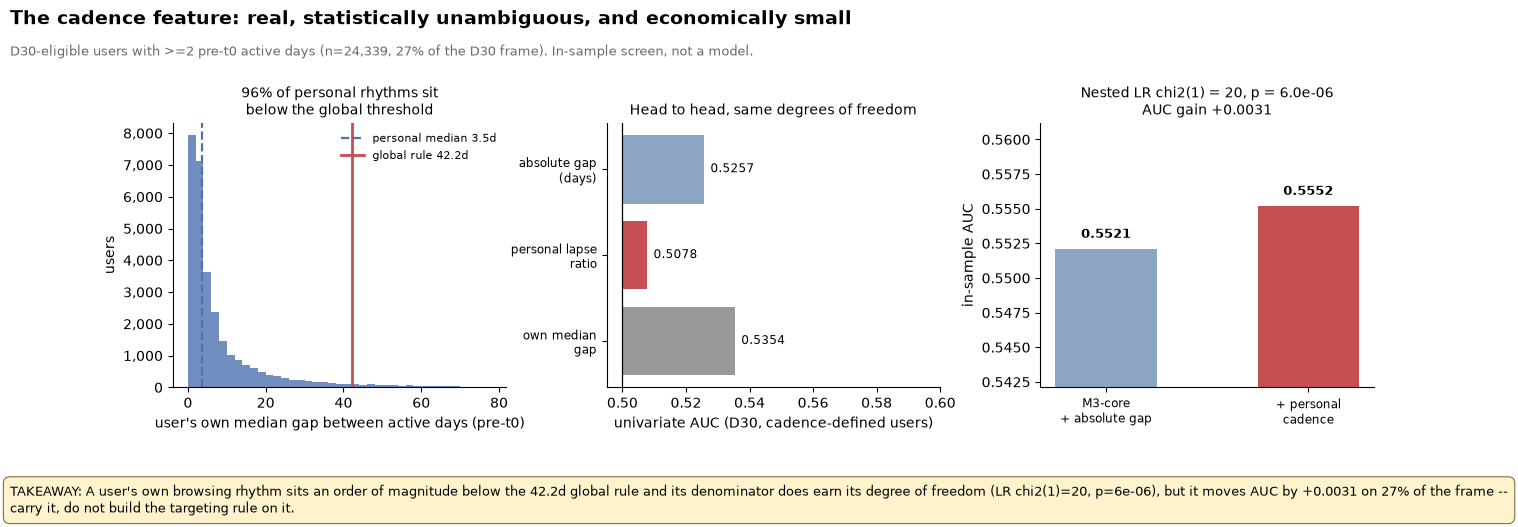

In [18]:
fig, (ax, ax2, ax3) = plt.subplots(1, 3, figsize=(15.5, 5.4))
fig.subplots_adjust(top=0.76, bottom=0.27, wspace=0.30)

cd_ = M4.cad_day_median_gap_d.dropna()
ax.hist(cd_, bins=np.arange(0, 80, 2), color="#4C72B0", alpha=0.8)
ax.axvline(cd_.median(), color="#4C72B0", ls="--", lw=1.6, label=f"personal median {cd_.median():.1f}d")
ax.axvline(K_CERT, color="#C44E52", ls="-", lw=2.0, label=f"global rule {K_CERT}d")
ax.set_xlabel("user's own median gap between active days (pre-t0)"); ax.set_ylabel("users")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax.legend(fontsize=8, frameon=False)
ax.set_title(f"{100*(cd_ < K_CERT).mean():.0f}% of personal rhythms sit\nbelow the global threshold", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

yy = np.arange(len(uni_tab))
ax2.barh(yy, uni_tab.AUC - 0.5, left=0.5, color=["#8DA5C4", "#C44E52", "#999999"])
for i, v in enumerate(uni_tab.AUC):
    ax2.text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=8.5)
ax2.axvline(0.5, color="black", lw=0.9)
ax2.set_yticks(yy, ["absolute gap\n(days)", "personal lapse\nratio", "own median\ngap"], fontsize=8.5)
ax2.invert_yaxis(); ax2.set_xlim(0.495, 0.60); ax2.set_xlabel("univariate AUC (D30, cadence-defined users)")
ax2.set_title("Head to head, same degrees of freedom", fontsize=10)
ax2.spines[["top", "right"]].set_visible(False)

ax3.bar([0, 1], [auc_base, auc_cad], 0.5, color=["#8DA5C4", "#C44E52"])
ax3.set_xticks([0, 1]); ax3.set_xticklabels(["M3-core\n+ absolute gap", "+ personal\ncadence"], fontsize=8.5)
ax3.set_ylim(min(auc_base, auc_cad) - 0.010, max(auc_base, auc_cad) + 0.006)
for i, v in enumerate([auc_base, auc_cad]):
    ax3.text(i, v + 0.0008, f"{v:.4f}", ha="center", fontsize=9, fontweight="bold")
ax3.set_ylabel("in-sample AUC")
ax3.set_title(f"Nested LR chi2(1) = {LR:.0f}, p = {p_lr:.1e}\nAUC gain {auc_cad-auc_base:+.4f}", fontsize=10)
ax3.spines[["top", "right"]].set_visible(False)

add_title(fig, "The cadence feature: real, statistically unambiguous, and economically small",
          f"D30-eligible users with >=2 pre-t0 active days (n={len(S):,}, {100*len(S)/int(elig.eligible_n[0]):.0f}% of the D30 frame). In-sample screen, not a model.")
add_takeaway(fig, f"A user's own browsing rhythm sits an order of magnitude below the {K_CERT}d global rule and its "
                  f"denominator does earn its degree of freedom (LR chi2(1)={LR:.0f}, p={p_lr:.0e}), but it moves AUC by "
                  f"{auc_cad-auc_base:+.4f} on {100*len(S)/int(elig.eligible_n[0]):.0f}% of the frame -- carry it, do not build the targeting rule on it.")
save(fig, "nb05_cadence_screen"); plt.show()

## 8. Segment information — re-scored on pre-`t0` data, and still not used

Constraint 4 is precise: do **not** join `cluster_name` as a static feature, and if segment
information is used at all, re-score it from `segment_model.json` on pre-`t0` data only and
report what fraction of users can be scored that way. Two independent reasons the stored
label is forbidden (F4):

- **It is not durable.** 56.9% same-cluster across two months, Cohen's kappa 0.309 against
  37.6% chance. A stored label misdirects roughly two users in five.
- **It was fitted on full history**, so as a predictor of a post-`t0` outcome it is an F1
  violation before durability is even considered.

The re-scoring is attempted honestly below, and it fails on a specific, checkable point.

In [19]:
with open(os.path.join(PROCESSED_DIR, "segment_model.json")) as f:
    smod = json.load(f)
SFEATS = smod["features"]; SLOG = smod["log1p_features"]
print("APPLYING segment_model.json TO A STRICTLY PRE-t0 WINDOW")
print("=" * 94)
print(f"  apply order : {smod['apply_order']}")
print(f"  eligibility : {smod['eligibility']}")
print(f"  the model's own warning for this notebook:")
print(f"    \"{smod['warning_for_05']}\"")
print()

wk = con.execute('''SELECT user_id, count(DISTINCT date_trunc('week', event_time)) AS pre_n_active_weeks,
    count(*) FILTER (WHERE event_type='view') AS nv, count(*) FILTER (WHERE event_type='cart') AS nc
    FROM pre_ev GROUP BY 1''').fetchdf().sort_values("user_id").reset_index(drop=True)
P = M3.merge(wk, on="user_id", how="left")
P["sessions_per_active_week"] = P.pre_n_sessions / P.pre_n_active_weeks
P["mean_session_depth"]       = P.pre_mean_session_depth
P["view_to_cart"]             = P.pre_view_to_cart
P["cart_abandonment_rate"]    = 1.0                      # degenerate -- see Section 6A
P["mean_price_pct_viewed"]    = P.pre_mean_price_pct_viewed
P["price_range_viewed"]       = P.pre_price_range_viewed
P["brand_entropy"]            = P.pre_brand_entropy
P["category_entropy"]         = P.pre_category_entropy
P["scorable"] = (P.nv > 0) & (P.nc > 0) & P[SFEATS].notna().all(axis=1)

n_scor = int(P.scorable.sum())
print("COVERAGE -- what fraction of users can be scored on pre-t0 data at all")
print("=" * 94)
print(f"  purchasers                                        : {N_PURCHASERS:,}")
print(f"  with >=1 pre-t0 event                             : {len(M3):,}")
print(f"  meeting the model's own eligibility (>=1 view AND >=1 cart pre-t0)")
print(f"    and with all 8 features non-null                : {n_scor:,} "
      f"({100*n_scor/N_PURCHASERS:.1f}% of purchasers)")
print(f"  NOT scorable                                      : {N_PURCHASERS - n_scor:,} "
      f"({100*(N_PURCHASERS-n_scor)/N_PURCHASERS:.1f}%)")
print()
X = P.loc[P.scorable, SFEATS].copy()
for c in SLOG:
    X[c] = np.log1p(X[c])
for c in SFEATS:
    X[c] = X[c].clip(smod["clip_lo"][c], smod["clip_hi"][c])
    X[c] = (X[c] - smod["scaler_mean"][c]) / smod["scaler_scale"][c]
names = list(smod["centroids"].keys())
C = np.array([smod["centroids"][n] for n in names])
d = ((X.values[:, None, :] - C[None, :, :]) ** 2).sum(axis=2)
P["pre_segment"] = np.nan
P.loc[P.scorable, "pre_segment"] = [names[i] for i in d.argmin(axis=1)]
P["pre_segment"] = P.pre_segment.fillna("Not Scorable (pre-t0)")

print("BUT THE RE-SCORING IS NOT FAITHFUL, AND THE REASON IS CHECKABLE")
print("=" * 94)
z_cab = (min(max(1.0, smod["clip_lo"]["cart_abandonment_rate"]), smod["clip_hi"]["cart_abandonment_rate"])
         - smod["scaler_mean"]["cart_abandonment_rate"]) / smod["scaler_scale"]["cart_abandonment_rate"]
print(f"  1. cart_abandonment_rate is 1.0 for every user (Section 6A), clips to "
      f"{smod['clip_hi']['cart_abandonment_rate']:.5f} and standardises to z = {z_cab:+.3f} for EVERYONE.")
print("     One of the eight fitted dimensions is a constant, so the assignment is really a 7-feature")
print("     nearest-centroid in an 8-dimensional space whose 8th axis has been pinned at its ceiling.")
print("  2. mean_price_pct_viewed here uses the leakage-safe PRIOR-DAY product price rank (Section 4A);")
print("     04 fitted on a full-dataset percentile. Same name, different variable.")
print()
seg_disk = pd.read_parquet(os.path.join(PROCESSED_DIR, "segment_assignments.parquet"))[["user_id", "cluster_name"]]
agr = P[["user_id", "pre_segment", "scorable"]].merge(seg_disk, on="user_id", how="left")
both = agr[agr.scorable & agr.cluster_name.notna() & (agr.cluster_name != "No Behavioural Profile")]
same = float((both.pre_segment == both.cluster_name).mean())
mix = (pd.concat([both.cluster_name.value_counts(normalize=True).rename("04_full_history_pct"),
                  both.pre_segment.value_counts(normalize=True).rename("05_pre_t0_rescored_pct")], axis=1)
         .mul(100).round(2).reset_index(names="segment"))
show_df(mix, name="nb05_segment_rescore_mix")
print()
print(f"  agreement with 04's stored label, on the {len(both):,} users where both exist : {100*same:.1f}%")
print(f"  04's own two-month membership stability, for scale                    : "
      f"{SEG['stability']['same_cluster_pct']}% (kappa {SEG['stability']['cohens_kappa']})")
print()
print("VERDICT: pre_segment is persisted as a CATEGORICAL, marked model_eligible = FALSE.")
print("=" * 94)
print(f"  It can be produced for {100*n_scor/N_PURCHASERS:.1f}% of users, which is the number constraint 4")
print("  asked for. It should still not be used as a feature, for three reasons that compound:")
print("   - one of its eight inputs is constant in this window, so it is not the model 04 validated;")
print("   - it is a deterministic function of M3 features already in the table, so it adds no information")
print("     to 06 -- only a lossy, 4-level compression of features 06 can read at full resolution;")
print("   - it inherits 04's own instability, which is a property of the customers, not of the code.")
print("  It is kept for one legitimate purpose: 08 must re-score at targeting time, and this is the")
print("  reference implementation of that re-scoring, with its failure mode measured rather than assumed.")

APPLYING segment_model.json TO A STRICTLY PRE-t0 WINDOW
  apply order : select FEATS -> log1p(log1p_features) -> clip to [clip_lo, clip_hi] -> (x - scaler_mean)/scaler_scale -> nearest centroid in Euclidean distance
  eligibility : >=1 view event AND >=1 cart event in the scoring window; otherwise 'No Behavioural Profile'
  the model's own warning for this notebook:
    "These labels are computed on FULL history to 2020-02-29 and are NOT leakage-safe as predictor features for a post-snapshot outcome. Re-score on a pre-outcome window with this transform instead of joining cluster_name from segment_assignments.parquet."

COVERAGE -- what fraction of users can be scored on pre-t0 data at all
  purchasers                                        : 109,732
  with >=1 pre-t0 event                             : 109,132
  meeting the model's own eligibility (>=1 view AND >=1 cart pre-t0)
    and with all 8 features non-null                : 99,883 (91.0% of purchasers)
  NOT scorable            

BUT THE RE-SCORING IS NOT FAITHFUL, AND THE REASON IS CHECKABLE
  1. cart_abandonment_rate is 1.0 for every user (Section 6A), clips to 0.96875 and standardises to z = +2.108 for EVERYONE.
     One of the eight fitted dimensions is a constant, so the assignment is really a 7-feature
     nearest-centroid in an 8-dimensional space whose 8th axis has been pinned at its ceiling.
  2. mean_price_pct_viewed here uses the leakage-safe PRIOR-DAY product price rank (Section 4A);
     04 fitted on a full-dataset percentile. Same name, different variable.

                 segment  04_full_history_pct  05_pre_t0_rescored_pct
0     Broad Deliberators                42.18                   45.73
1  Single-Mission Buyers                24.92                   19.45
2           Cart Loaders                18.70                   22.85
3      Frequent Skimmers                14.20                   11.98

  agreement with 04's stored label, on the 99,883 users where both exist : 77.1%
  04's own two-

/var/folders/p2/9htmf4392ml8yyv8_zyhfww80000gn/T/ipykernel_94383/4191688351.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['Broad Deliberators', 'Broad Deliberators', 'Broad Deliberators', 'Broad Deliberators', 'Single-Mission Buyers', 'Broad Deliberators', 'Cart Loaders', 'Broad Deliberators', 'Cart Loaders', 'Broad Deliberators', 'Single-Mission Buyers', 'Cart Loaders', 'Broad Deliberators', 'Broad Deliberators', 'Broad Deliberators', 'Cart Loaders', 'Broad Deliberators', 'Broad Deliberators', 'Single-Mission Buyers', 'Broad Deliberators', 'Broad Deliberators', 'Broad Deliberators', 'Single-Mission Buyers', 'Single-Mission Buyers', 'Single-Mission Buyers', 'Cart Loaders', 'Broad Deliberators', 'Broad Deliberators', 'Single-Mission Buyers', 'Cart Loaders', 'Broad Deliberators', 'Broad Deliberators', 'Broad Deliberators', 'Broad Deliberators', 'Cart Loaders', 'Single-Mission Buyers', 'Broad Delibe

## 9. Assembling the table, then proving the leakage rules hold

The blocks are joined on `user_id` with a left join from the full purchaser list, so a
user missing from a block keeps `NULL` for that block and gains an explicit indicator.
Nothing is imputed anywhere in this notebook.

Then three independent leakage checks, because the audit has to be able to *fail*:

- **9A — window disjointness, at row level.** For each block, the maximum `event_time` that
  could have fed it is compared against `t0` in SQL, on the real rows.
- **9B — provenance audit.** Every feature declares the window it reads and the events it
  reads. The declaration is checked against the allowed set mechanically.
- **9C — a univariate screen with a planted positive control.** A deliberately leaky
  feature is built (events in the outcome window) and put through the same screen. If the
  screen cannot flag that one, it has no power to clear the others.

In [20]:
BASE_COLS = tgt[["user_id", "first_ts", "cohort_month", "trailing_days", "days_to_next_order"]
                + [f"eligible_{h}d" for h in HORIZONS] + [f"repeat_purchase_{h}d" for h in HORIZONS]].copy()
BASE_COLS["t0_calendar_day"] = (BASE_COLS.first_ts - DATA_START).dt.total_seconds() / 86400.0

FEAT = (BASE_COLS
        .merge(chk[["user_id", "is_bulk_buyer", "is_bf_cohort"]]
                 .rename(columns={"is_bulk_buyer": "is_bulk_buyer_fullhistory"}), on="user_id", how="left")
        .merge(M1, on="user_id", how="left")
        .merge(M2, on="user_id", how="left")
        .merge(M3.drop(columns=["tenure_d_pos"]), on="user_id", how="left")
        .merge(M4, on="user_id", how="left")
        .merge(P[["user_id", "pre_segment"]], on="user_id", how="left")
        .sort_values("user_id").reset_index(drop=True))

FEAT["fs_has_pre_purchase_events"] = FEAT.fs_n_events.notna().astype(int)
FEAT["has_pre_t0_history"]         = FEAT.pre_n_events.notna().astype(int)
FEAT["has_session_cadence"]        = FEAT.has_session_cadence.fillna(0).astype(int)
FEAT["has_day_cadence"]            = FEAT.has_day_cadence.fillna(0).astype(int)
FEAT["has_prior_sessions"]         = FEAT.has_prior_sessions.fillna(0).astype(int)
FEAT["pre_segment"]                = FEAT.pre_segment.fillna("Not Scorable (pre-t0)")
FEAT = round_sig(FEAT, [c for c in FEAT.columns if FEAT[c].dtype.kind == "f"], sig=6)

assert len(FEAT) == N_PURCHASERS and FEAT.user_id.is_unique
print(f"FEATURE FRAME ASSEMBLED: {len(FEAT):,} rows x {FEAT.shape[1]} columns")
print(f"  = all {N_PURCHASERS:,} bot-excluded purchasers, with per-horizon eligibility flags.")
print()
print("  WHY ALL PURCHASERS AND NOT JUST THE D30-ELIGIBLE ONES: the three horizons have three different")
print("  eligible populations, so a single pre-filtered file would force a horizon choice on 06. The")
print("  file carries eligible_30d / _60d / _90d and 06 subsets. The row-count assertion required by the")
print("  brief is made against each horizon's subset instead, below and in Section 13.")
for h in HORIZONS:
    n_sub = int(FEAT[f"eligible_{h}d"].sum())
    assert n_sub == int(elig.loc[elig.horizon == f"D{h}", "eligible_n"].iloc[0])
    print(f"    FEAT[eligible_{h}d] rows = {n_sub:,}  ==  Section 3 eligible N  ✓")

FEATURE FRAME ASSEMBLED: 109,732 rows x 96 columns
  = all 109,732 bot-excluded purchasers, with per-horizon eligibility flags.

  WHY ALL PURCHASERS AND NOT JUST THE D30-ELIGIBLE ONES: the three horizons have three different
  eligible populations, so a single pre-filtered file would force a horizon choice on 06. The
  file carries eligible_30d / _60d / _90d and 06 subsets. The row-count assertion required by the
  brief is made against each horizon's subset instead, below and in Section 13.
    FEAT[eligible_30d] rows = 91,334  ==  Section 3 eligible N  ✓
    FEAT[eligible_60d] rows = 71,727  ==  Section 3 eligible N  ✓
    FEAT[eligible_90d] rows = 52,737  ==  Section 3 eligible N  ✓


In [21]:
print("9A -- WINDOW DISJOINTNESS, ASSERTED ON ROWS NOT ON PROSE")
print("=" * 94)
dis = con.execute('''
SELECT 'M1 first-order lines' AS block, count(*) n_rows,
       max(date_diff('second', first_ts, event_time)) AS max_seconds_vs_t0,
       min(date_diff('second', first_ts, event_time)) AS min_seconds_vs_t0
FROM uev WHERE event_time = first_ts AND event_type='purchase' AND user_session = first_session
UNION ALL
SELECT 'M2 first-order session (truncated)', count(*),
       max(date_diff('second', first_ts, event_time)), min(date_diff('second', first_ts, event_time))
FROM pre_ev WHERE user_session = first_session
UNION ALL
SELECT 'M3/M4 all pre-t0 events', count(*),
       max(date_diff('second', first_ts, event_time)), min(date_diff('second', first_ts, event_time))
FROM pre_ev
UNION ALL
SELECT 'OUTCOME orders (target only)', count(*),
       max(date_diff('second', f.first_ts, o.order_ts)), min(date_diff('second', f.first_ts, o.order_ts))
FROM first_order f JOIN orders o ON o.user_id=f.user_id
     AND o.order_ts > f.first_ts AND o.user_session <> f.first_session''').fetchdf()
show_df(dis, name="nb05_window_disjointness")
feat_max = dis.loc[dis.block.str.startswith(("M1", "M2", "M3")), "max_seconds_vs_t0"].max()
out_min  = dis.loc[dis.block.str.startswith("OUTCOME"), "min_seconds_vs_t0"].iloc[0]
assert feat_max <= 0, f"a FEATURE block reads an event {feat_max}s AFTER t0"
assert out_min  >  0, f"the OUTCOME window reads an order {out_min}s at or before t0"
print()
print(f"  every feature-block event is at or before t0 (max offset {int(feat_max)}s, i.e. the first order itself)")
print(f"  every outcome order is strictly after t0    (min offset {int(out_min)}s = {out_min/86400:.4f}d)")
print("  The two windows share no row. This is the assertion the whole notebook rests on.")
print()
print("  A second, sharper form of the same check: the outcome-window session rule. A repeat order placed")
print("  INSIDE the first-order session would satisfy 'after t0' but is excluded by 02's session rule --")
same_sess = con.execute('''SELECT count(*) FROM first_order f JOIN orders o ON o.user_id=f.user_id
       WHERE o.order_ts > f.first_ts AND o.user_session = f.first_session''').fetchone()[0]
all_rep = con.execute('''SELECT count(*) FROM first_order f JOIN orders o ON o.user_id=f.user_id
       WHERE o.order_ts > f.first_ts''').fetchone()[0]
print(f"  {same_sess:,} of {all_rep:,} repeat orders ({100*same_sess/all_rep:.2f}%) sit in the first-order")
print("  session and are excluded from the target, exactly as 02 excluded them. Same rule, same number.")

9A -- WINDOW DISJOINTNESS, ASSERTED ON ROWS NOT ON PROSE


                                block   n_rows  max_seconds_vs_t0  min_seconds_vs_t0
0                M1 first-order lines   831777                  0                  0
1  M2 first-order session (truncated)  1940228                 -1          -12081659
2             M3/M4 all pre-t0 events  5351448                 -1          -13065403
3        OUTCOME orders (target only)    45771           13089090                 70

  every feature-block event is at or before t0 (max offset 0s, i.e. the first order itself)
  every outcome order is strictly after t0    (min offset 70s = 0.0008d)
  The two windows share no row. This is the assertion the whole notebook rests on.

  A second, sharper form of the same check: the outcome-window session rule. A repeat order placed
  INSIDE the first-order session would satisfy 'after t0' but is excluded by 02's session rule --
  2,895 of 48,666 repeat orders (5.95%) sit in the first-order
  session and are excluded from the target, exactly as 02 exclude

In [22]:
# ---------------------------------------------------------------------------------------------
#  THE FEATURE DICTIONARY.  Declared by hand, one row per column, so that Section 9B can check
#  the DECLARATION against the BUILD mechanically instead of trusting a comment.
#  window values are the only four allowed:
#     "at t0"       the first order's own purchase lines, event_time = t0
#     "< t0"        strictly before t0
#     "target"      the outcome window -- permitted ONLY for target/eligibility columns
#     "meta"        identifiers, calendar position, population flags; never a model input
# ---------------------------------------------------------------------------------------------
ALLOWED_WINDOWS = {"at t0", "< t0", "target", "meta"}
D = []
def f(name, block, window, source, definition, leak, eligible=True):
    D.append(dict(feature=name, block=block, window=window, source_events=source,
                  definition=definition, leakage_risk_assessed=leak, model_eligible=eligible))

f("user_id", "id", "meta", "-", "cookie-scoped user id; NOT account-scoped, so every repeat figure is a lower bound", "none", False)
f("first_ts", "id", "meta", "purchase", "t0 -- first order timestamp, certified rule", "anchor itself", False)
f("cohort_month", "meta", "meta", "purchase", "calendar month of t0; for 06's chronological split", "none", False)
f("trailing_days", "meta", "meta", "-", "(DATA_END - t0) in days; the censoring quantity", "CENSORING, not a feature", False)
f("t0_calendar_day", "meta", "meta", "-", "days from 2019-10-01 to t0; carried for 03's anchor-sensitivity re-test", "near-perfect train/test discriminator under a chronological split", False)
f("days_to_next_order", "target", "target", "purchase", "days from t0 to the first later order in a different session; NULL if none", "OUTCOME", False)
for h in HORIZONS:
    f(f"repeat_purchase_{h}d", "target", "target", "purchase", f"days_to_next_order <= {h}", "OUTCOME", False)
    f(f"eligible_{h}d", "target", "meta", "-", f"t0 + {h}d <= DATA_END in exact elapsed seconds", "censoring rule", False)
f("is_bulk_buyer_fullhistory", "population flag", "meta", "purchase", f"02's flag: ANY order >= {BULK_ITEMS:.1f} items over FULL history", "FORBIDDEN AS A FEATURE (F2) -- carried for reporting per constraint 6; use first_order_is_bulk", False)
f("is_bf_cohort", "population flag", "meta", "-", "02's Black Friday acquisition cohort", "calendar attribute of t0; safe but confounded -- see handoff black_friday_cohort", False)

M1D = [
 ("fo_value", "sum of positive line prices in the first order", "bulk buyers move any MEAN of this; use fo_value_w for mean-based terms"),
 ("fo_value_w", "fo_value winsorised at P99 (constraint 6)", "mean-safe twin of fo_value"),
 ("fo_n_items", "purchase lines in the first order (quantity-preserving, per 00's audit)", "none"),
 ("fo_n_products", "distinct products in the first order", "none"),
 ("fo_n_categories", "distinct category_id in the first order", "none"),
 ("fo_n_brands", "distinct non-null brands in the first order", "none"),
 ("fo_brand_null_share", "share of first-order lines with a null brand", "brand is 42.3% null at source; NULL is information, not missingness"),
 ("fo_max_price", "max line price", "none"), ("fo_min_price", "min line price", "none"),
 ("fo_median_price", "median line price (quantile_cont, exact)", "none"),
 ("fo_price_range", "fo_max_price - fo_min_price", "none"),
 ("fo_hour", "hour of t0", "none"), ("fo_dow", "day of week of t0", "none"),
 ("fo_is_weekend", "t0 falls on Sat/Sun", "none"),
 ("fo_discount_vs_prior_max", "mean over lines of max(1 - price / product's max price on STRICTLY PRIOR days, 0)", "F3-safe by construction: .shift().expanding(); a full-dataset reference inflates this 5x"),
 ("fo_price_vs_prior_mean", "mean over lines of price / product's mean price on strictly prior days", "F3-safe, same construction"),
 ("fo_product_price_pct_prior", "mean over lines of the product's cross-sectional price percentile among all products, computed from prior-day prices on the order's day", "F3-safe"),
 ("fo_price_ref_coverage", "share of first-order lines that had a prior-day reference at all", "diagnostic for the three features above"),
 ("fo_price_z_in_category", "mean over lines of (ln price - prior mean ln price in category) / prior sd, clipped to +/-5", "F3-safe; NULL where the category has <50 prior priced rows or sd(ln p) < 0.05"),
 ("fo_catz_coverage", "share of lines with a usable category reference", "diagnostic for fo_price_z_in_category"),
 ("fo_has_discount", "fo_discount_vs_prior_max > 0", "F3-safe"),
 ("first_order_is_bulk", f"fo_n_items >= {BULK_ITEMS:.1f} -- the leakage-safe replacement for is_bulk_buyer", "F2-safe by construction"),
]
for n, dfn, lk in M1D: f(n, "M1 first order", "at t0", "purchase", dfn, lk)
f("fo_primary_brand", "M1 first order", "at t0", "purchase", "modal brand of the first order; '__NULL__' is its own level", "HIGH CARDINALITY -- 06 must encode inside its split, never on the full table")
f("fo_primary_category", "M1 first order", "at t0", "purchase", "modal category_id of the first order; structural id, unlabelled (category_code is 98.3% null)", "HIGH CARDINALITY -- same rule")

M2D = [
 ("fs_n_events", "events in the first-order session before t0", "truncated at t0: the untruncated version leaks for 10.7% of users (Section 1A)"),
 ("fs_n_view_ev", "view events in that window", "same truncation"),
 ("fs_n_cart_ev", "cart events in that window", "same truncation"),
 ("fs_n_removals", "remove_from_cart events in that window", "abandonment VOLUME -- permitted by the leakage rule; TYPE is not"),
 ("fs_p_viewed", "distinct products viewed in that window", "product-distinct base, immune to 00's 10.4% duplicate telemetry rows"),
 ("fs_p_touched", "distinct products touched by any event in that window", "same"),
 ("fs_n_categories", "distinct categories in that window", "same truncation"),
 ("fs_n_brands", "distinct non-null brands in that window", "same truncation"),
 ("fs_max_price_viewed", "max price among priced views in that window", "NULL for users who reached t0 with no priced view"),
 ("fs_price_range_viewed", "P90-P10 of priced-view prices in that window", "same"),
 ("fs_duration_min", "minutes from the session's first pre-t0 event to t0", "HEAVY TAIL from session-ID reuse (00: 2.16% of sessions > 24h); log or bin it"),
 ("fs_start_hour", "hour of the session's first pre-t0 event", "none"),
 ("fs_start_dow", "day of week of the same", "none"),
 ("fs_entry_event_type", "event_type of the session's first pre-t0 event", "3-level categorical"),
 ("fs_has_pre_purchase_events", "the first-order session had any event before t0", "the explicit missingness indicator for this whole block -- 11,830 users have none"),
]
for n, dfn, lk in M2D: f(n, "M2 first-order session", "< t0", "all types", dfn, lk)

M3D = [
 ("pre_n_events", "all events before t0", "none"), ("pre_n_view_ev", "views before t0", "none"),
 ("pre_n_cart_ev", "cart adds before t0", "none"),
 ("pre_n_removals", "removals before t0", "abandonment VOLUME; the one thing 02 Section 0E found survives"),
 ("log1p_pre_n_removals", "log1p(pre_n_removals) -- the form 02/03 measured at OR 1.38", "anchor-sensitive: 1.37-1.44 first-order-anchored, 1.03-1.14 calendar-anchored"),
 ("pre_n_products", "distinct products touched before t0", "none"),
 ("pre_p_viewed", "distinct products viewed before t0", "none"),
 ("pre_p_carted", "distinct products carted before t0", "none"),
 ("pre_n_categories", "distinct categories before t0", "none"),
 ("pre_n_brands", "distinct non-null brands before t0", "none"),
 ("pre_n_active_days", "distinct active days before t0", "none"),
 ("pre_n_sessions", "distinct sessions with an event before t0", "none"),
 ("pre_n_prior_sessions", "as above, excluding the first-order session", "lets 06 build a disjoint M2/M3 nesting if it prefers"),
 ("has_prior_sessions", "pre_n_prior_sessions > 0", "the non-degenerate form of 'converted in the first session'"),
 ("pre_mean_session_depth", "mean events per pre-t0 session", "none"),
 ("pre_view_to_cart", "distinct carted / distinct viewed, before t0", "NULL where no view"),
 ("pre_removal_per_cart", "removal events / cart events, before t0", "abandonment VOLUME ratio; NULL where no cart"),
 ("pre_cart_not_in_first_order_rate", "share of pre-t0 carted products NOT in the first order", "REPLACES 04's cart_abandonment_rate, which is a constant 1.0 in this window (Section 6A)"),
 ("pre_brand_entropy", "Shannon entropy of viewed brands, NULL kept as its own level", "none"),
 ("pre_brand_coverage", "share of pre-t0 views carrying a non-null brand", "diagnostic for pre_brand_entropy"),
 ("pre_category_entropy", "Shannon entropy of viewed category_id", "none"),
 ("pre_mean_price_pct_viewed", "mean prior-day price percentile of products viewed before t0", "F3-safe; NOT the same variable 04 fitted on (it used a full-dataset percentile)"),
 ("pre_price_range_viewed", "P90-P10 of those percentiles", "F3-safe, same caveat"),
 ("tenure_d", "days from the user's FIRST EVENT to t0", "measured to t0, NOT to DATA_END -- the DATA_END version is F2"),
 ("pre_days_since_last_event", "days from the last pre-t0 event to t0", "NEAR-DEGENERATE: median 6.8 minutes. Measures checkout speed, not recency"),
 ("pre_views_per_tenure_day", "pre_n_view_ev / tenure_d (floored at 1 minute)", "tenure-normalised twin, constraint 5"),
 ("pre_sessions_per_tenure_day", "pre_n_sessions / tenure_d", "tenure-normalised twin, constraint 5"),
 ("pre_events_per_tenure_day", "pre_n_events / tenure_d", "tenure-normalised twin, constraint 5"),
 ("pre_products_per_tenure_day", "pre_n_products / tenure_d", "tenure-normalised twin, constraint 5"),
 ("has_pre_t0_history", "the user has any event before t0", "explicit missingness indicator for this block -- 600 users have none"),
]
for n, dfn, lk in M3D: f(n, "M3 pre-t0 browsing", "< t0", "all types", dfn, lk)

M4D = [
 ("cad_n_hist_gaps", "number of historical inter-session gaps before the buying visit", "coverage indicator"),
 ("cad_median_gap_d", "median of those gaps (days)", "NULL for users with <2 prior sessions; never imputed"),
 ("cad_iqr_gap_d", "IQR of those gaps", "same"),
 ("cad_regularity", "cad_iqr_gap_d / cad_median_gap_d", "same"),
 ("gap_before_purchase_visit", "days from the previous session's start to the buying session's start", "held out of the cadence median so the ratio is not self-referential"),
 ("cad_lapse_ratio", "gap_before_purchase_visit / cad_median_gap_d", "the personalised quantity; NOT collinear with either part"),
 ("has_session_cadence", "cad_median_gap_d is defined", "explicit missingness indicator"),
 ("cad_day_n_hist_gaps", "number of historical gaps between ACTIVE DAYS before the buying day", "coverage indicator"),
 ("cad_day_median_gap_d", "median of those day-gaps", "the interpretable cadence: median 3.5d against a 42.2d global rule"),
 ("gap_before_purchase_day", "days from the previous active day to the buying day", "held out of the median, as above"),
 ("cad_day_lapse_ratio", "gap_before_purchase_day / cad_day_median_gap_d", "the personalised quantity tested in Section 7"),
 ("has_day_cadence", "cad_day_median_gap_d is defined", "explicit missingness indicator -- only 27.1% of users"),
]
for n, dfn, lk in M4D: f(n, "M4 cadence", "< t0", "all types", dfn, lk)
f("pre_segment", "S segment", "< t0", "all types", "segment_model.json re-scored on pre-t0 features only", "NOT model-eligible: one of the 8 fitted inputs is constant in this window, and it is a lossy function of M3 (Section 8)", False)

DICT = pd.DataFrame(D)
assert set(DICT.window) <= ALLOWED_WINDOWS, set(DICT.window) - ALLOWED_WINDOWS
print(f"Feature dictionary declared: {len(DICT)} rows across blocks {sorted(DICT.block.unique())}")

Feature dictionary declared: 96 rows across blocks ['M1 first order', 'M2 first-order session', 'M3 pre-t0 browsing', 'M4 cadence', 'S segment', 'id', 'meta', 'population flag', 'target']


In [23]:
print("9B -- PROVENANCE AUDIT: every built column must be declared, and every declaration must be built")
print("=" * 94)
built    = set(FEAT.columns)
declared = set(DICT.feature)
missing_decl = sorted(built - declared)
missing_build = sorted(declared - built)
print(f"  columns built    : {len(built)}")
print(f"  columns declared : {len(declared)}")
print(f"  built but NOT declared : {missing_decl if missing_decl else 'none'}")
print(f"  declared but NOT built : {missing_build if missing_build else 'none'}")
assert not missing_decl and not missing_build, (missing_decl, missing_build)
print("  The dictionary and the table are the same object. A feature cannot be added without declaring")
print("  its window, which is the point of doing it this way rather than writing a comment.")
print()
bad = DICT[(DICT.window == "target") & (DICT.block != "target")]
assert len(bad) == 0, bad
mdl = DICT[DICT.model_eligible]
assert set(mdl.window) <= {"at t0", "< t0"}, set(mdl.window)
print(f"  MODEL-ELIGIBLE features : {len(mdl)}   all of them declare window 'at t0' or '< t0'")
print(f"  NOT model-eligible      : {len(DICT) - len(mdl)}   "
      f"({', '.join(sorted(DICT.loc[~DICT.model_eligible, 'block'].unique()))})")
print()
print("  Blocks, as 06 will nest them:")
for b in ["M1 first order", "M2 first-order session", "M3 pre-t0 browsing", "M4 cadence", "S segment"]:
    sub = DICT[DICT.block == b]
    print(f"    {b:<26s} {len(sub):>3d} columns, {int(sub.model_eligible.sum()):>3d} model-eligible")

9B -- PROVENANCE AUDIT: every built column must be declared, and every declaration must be built
  columns built    : 96
  columns declared : 96
  built but NOT declared : none
  declared but NOT built : none
  The dictionary and the table are the same object. A feature cannot be added without declaring
  its window, which is the point of doing it this way rather than writing a comment.

  MODEL-ELIGIBLE features : 81   all of them declare window 'at t0' or '< t0'
  NOT model-eligible      : 15   (S segment, id, meta, population flag, target)

  Blocks, as 06 will nest them:
    M1 first order              24 columns,  24 model-eligible
    M2 first-order session      15 columns,  15 model-eligible
    M3 pre-t0 browsing          30 columns,  30 model-eligible
    M4 cadence                  12 columns,  12 model-eligible
    S segment                    1 columns,   0 model-eligible


In [24]:
print("9C -- UNIVARIATE SCREEN WITH A PLANTED POSITIVE CONTROL")
print("=" * 94)
print("  A screen that has never been shown to catch a leak is not evidence of anything. So two")
print("  deliberately leaky features are built and pushed through the identical pipeline:")
print("    POSCTRL_post30_n_events  -- events in (t0, t0+30d].  Built from the OUTCOME window on purpose.")
print("    POSCTRL_naive_first_session_depth -- 02's untruncated first_session_events, the exact feature")
print("      Section 1A showed reads post-t0 rows for 10.7% of users. This is the realistic near-miss.")
print()
posctrl = con.execute('''
SELECT f.user_id,
       count(*) FILTER (WHERE e.event_time > f.first_ts
                          AND e.event_time <= f.first_ts + INTERVAL 30 DAY) AS POSCTRL_post30_n_events,
       count(*) FILTER (WHERE e.user_session = f.first_session) AS POSCTRL_naive_first_session_depth
FROM first_order f LEFT JOIN ev e ON e.user_id = f.user_id
GROUP BY 1''').fetchdf().sort_values("user_id").reset_index(drop=True)

SCR = FEAT.loc[FEAT.eligible_30d].merge(posctrl, on="user_id", how="left")
y = SCR.repeat_purchase_30d.astype(int).values
RAW_IDS = {"fo_primary_category"}   # a category_id is a label, not a magnitude -- an AUC on it is noise
num_cols = [c for c in DICT.loc[DICT.model_eligible, "feature"]
            if c in SCR.columns and SCR[c].dtype.kind in "ifb" and c not in RAW_IDS]
rows = []
for c in num_cols + ["POSCTRL_post30_n_events", "POSCTRL_naive_first_session_depth"]:
    v = SCR[c].astype(float).values
    ok = np.isfinite(v)
    if ok.sum() < 500 or np.nanstd(v[ok]) == 0:
        continue
    a = roc_auc_score(y[ok], v[ok])
    rows.append({"feature": c, "n_scored": int(ok.sum()), "AUC": round(max(a, 1-a), 4),
                 "signed_AUC": round(a, 4),
                 "is_positive_control": c.startswith("POSCTRL")})
scr = pd.DataFrame(rows).sort_values(["AUC", "feature"], ascending=[False, True], kind="mergesort").reset_index(drop=True)
scr.to_csv(os.path.join(TABLES_DIR, "nb05_leakage_univariate_screen.csv"), index=False)
show_df(scr.head(18), max_rows=18)
print(f"  ... {len(scr)} features scored in total; the full table is in "
      "outputs/tables/nb05_leakage_univariate_screen.csv")

pc1 = float(scr.loc[scr.feature == "POSCTRL_post30_n_events", "AUC"].iloc[0])
pc2 = float(scr.loc[scr.feature == "POSCTRL_naive_first_session_depth", "AUC"].iloc[0])
real = scr[~scr.is_positive_control]
top_real = real.iloc[0]
print()
print("  RESULT")
print(f"    POSCTRL_post30_n_events            AUC = {pc1:.4f}   <- pure outcome-window aggregate")
print(f"    POSCTRL_naive_first_session_depth  AUC = {pc2:.4f}   <- the realistic near-miss")
print(f"    strongest REAL feature             AUC = {top_real.AUC:.4f}  ({top_real.feature})")
print(f"    median REAL feature                AUC = {real.AUC.median():.4f}")
print()
tru = float(scr.loc[scr.feature == "fs_n_events", "AUC"].iloc[0])
print("  THE NEAR-MISS CONTROL IS THE INFORMATIVE ONE -- 02's first_session_events untruncated, against")
print("  this notebook's fs_n_events, the same count cut at t0. Scored naively they are not comparable:")
n_naive = int(SCR.POSCTRL_naive_first_session_depth.notna().sum())
n_trunc = int(SCR.fs_n_events.notna().sum())
print(f"    untruncated  AUC {pc2:.4f}  on {n_naive:,} users")
print(f"    truncated    AUC {tru:.4f}  on {n_trunc:,} users")
print(f"  The untruncated version is defined for EVERYONE, because the purchase itself is an event in the")
print(f"  session; the truncated one is NULL for the {n_naive-n_trunc:,} users who bought with no prior")
print("  activity in it. Part of that gap is leakage and part is coverage, so it is measured on the")
print("  COMMON population where both are defined:")
both_ok = SCR.POSCTRL_naive_first_session_depth.notna() & SCR.fs_n_events.notna()
yb = SCR.loc[both_ok, "repeat_purchase_30d"].astype(int).values
auc_naive_c = roc_auc_score(yb, SCR.loc[both_ok, "POSCTRL_naive_first_session_depth"].astype(float).values)
auc_trunc_c = roc_auc_score(yb, SCR.loc[both_ok, "fs_n_events"].astype(float).values)
gap = auc_naive_c - auc_trunc_c
print(f"    untruncated  AUC {auc_naive_c:.4f}")
print(f"    truncated    AUC {auc_trunc_c:.4f}   on the same {int(both_ok.sum()):,} users")
print(f"    difference        {gap:+.4f}  <- this is the leak, with coverage held constant")
print()
lift = SCR.loc[both_ok].groupby(SCR.loc[both_ok, "repeat_purchase_30d"].astype(int)).apply(
    lambda g: pd.Series({"mean_naive": g.POSCTRL_naive_first_session_depth.mean(),
                         "mean_truncated": g.fs_n_events.mean()}), include_groups=False)
lift["post_t0_events_added"] = (lift.mean_naive - lift.mean_truncated).round(2)
lift["as_pct_of_truncated"] = (100*(lift.mean_naive - lift.mean_truncated)/lift.mean_truncated).round(1)
lift.index = ["did NOT repeat", "repeated within 30d"]
show_df(lift.round(2).reset_index(names="outcome"), name="nb05_first_session_leak_by_outcome")
add_neg, add_pos = float(lift.post_t0_events_added.iloc[0]), float(lift.post_t0_events_added.iloc[1])
print()
print(f"  Not truncating adds {add_neg:.1f} events to the average non-repeater and {add_pos:.1f} to the average")
print("  repeater. That is a SMALL asymmetry, and saying so matters more than a dramatic number would:")
print("  the leak is not mainly a class-separator, it is a definitional violation. It places")
print(f"  {int(fs_after.purchase_rows_after_t0[0]):,} purchase rows inside a window that is supposed to end at t0, and its")
print(f"  univariate cost ({gap:+.4f} AUC) is the visible part of a failure whose size in a fitted model,")
print("  in interaction with 40 other features, this screen cannot bound. Truncation is not a tuning")
print("  choice; it is what makes the feature mean what its name says.")
print()
THRESH = min(pc1 - 0.20, 0.75)
flagged = real[real.AUC >= THRESH]
print(f"  SCREEN RULE: flag any real feature within 0.20 AUC of the pure-outcome control, i.e. at or")
print(f"  above {THRESH:.4f}. Calibrated against a measured leak, not against a round number -- and set")
print("  generously, because fo_value and pre_n_products legitimately predict repeat purchase (02")
print("  measured Cramer's V 0.0895 on first-order value) and a tight bar would flag honest signal.")
print(f"  Flagged: {len(flagged) if len(flagged) else 'none'}"
      + ("" if len(flagged) == 0 else " -> " + ", ".join(flagged.feature)))
assert len(flagged) == 0, f"a real feature scores like a known leak: {flagged.feature.tolist()}"  # SCREEN_ASSERT
print()
print("  WHAT THIS TEST CAN AND CANNOT DO -- stated because 'we checked for leakage' is not a method:")
print("   - It CAN detect a feature that carries outcome information strongly enough to separate the")
print("     classes on its own. Both controls confirm it does, at two very different severities.")
print("   - It CANNOT detect a weak leak, or one that only appears in interaction. Nothing univariate can.")
print("     The load-bearing guarantee is 9A's row-level window disjointness plus 9B's declaration audit;")
print("     this screen is the third check, not the first.")
print("   - A high AUC here would be a SUSPICION, not a verdict. fo_value legitimately predicts repeat")
print("     purchase (02 measured Cramer's V 0.0895 on it), so the rule is calibrated against a known")
print("     leak's score rather than against a round number.")

9C -- UNIVARIATE SCREEN WITH A PLANTED POSITIVE CONTROL
  A screen that has never been shown to catch a leak is not evidence of anything. So two
  deliberately leaky features are built and pushed through the identical pipeline:
    POSCTRL_post30_n_events  -- events in (t0, t0+30d].  Built from the OUTCOME window on purpose.
    POSCTRL_naive_first_session_depth -- 02's untruncated first_session_events, the exact feature
      Section 1A showed reads post-t0 rows for 10.7% of users. This is the realistic near-miss.



                             feature  n_scored     AUC  signed_AUC  is_positive_control
0            POSCTRL_post30_n_events     91334  0.9386      0.9386                 True
1                     pre_n_products     90815  0.6097      0.6097                False
2                       pre_n_events     90815  0.6092      0.6092                False
3                      pre_n_cart_ev     90815  0.6060      0.6060                False
4                   pre_n_categories     90815  0.6055      0.6055                False
5                       pre_p_carted     90815  0.6042      0.6042                False
6               log1p_pre_n_removals     90815  0.6023      0.6023                False
7                     pre_n_removals     90815  0.6023      0.6023                False
8                  pre_n_active_days     90815  0.5972      0.5972                False
9                       pre_n_brands     90815  0.5962      0.5962                False
10                          tenu

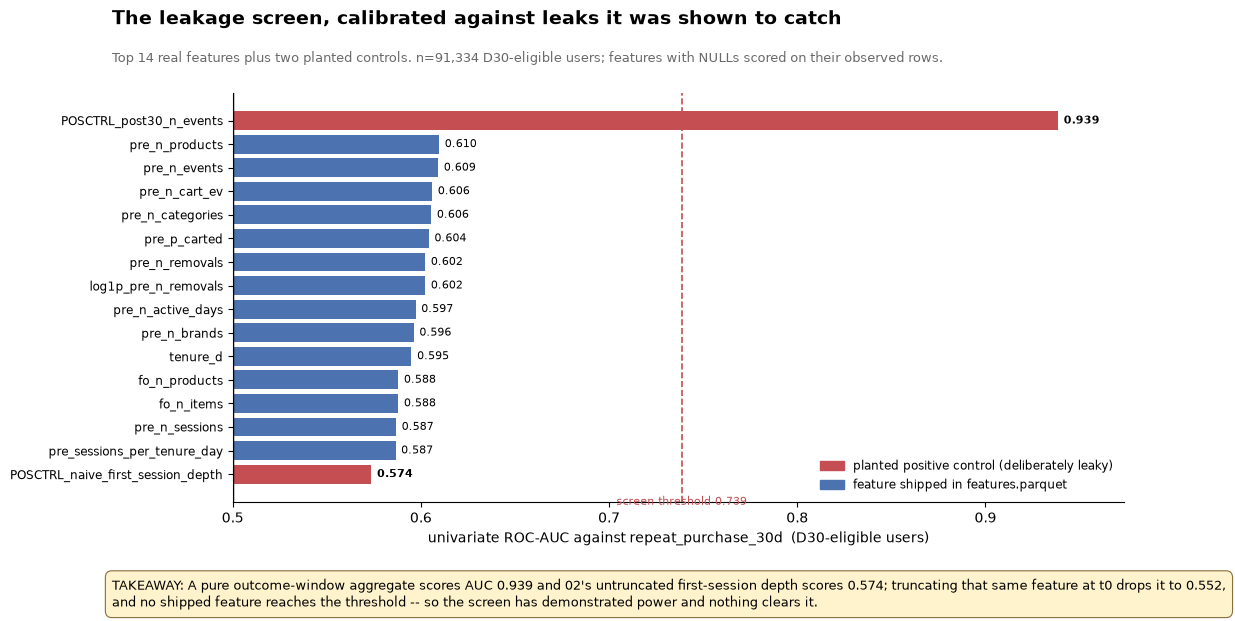

In [25]:
fig, ax = frame(figsize=(11.5, 6.4))
plot = pd.concat([real.head(14), scr[scr.is_positive_control]]).sort_values("AUC")
cols = ["#C44E52" if p else "#4C72B0" for p in plot.is_positive_control]
yy = np.arange(len(plot))
ax.barh(yy, plot.AUC - 0.5, left=0.5, color=cols)
for i, (v, p) in enumerate(zip(plot.AUC, plot.is_positive_control)):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=8, fontweight="bold" if p else "normal")
ax.axvline(0.5, color="black", lw=1.0)
ax.axvline(THRESH, color="#C44E52", ls="--", lw=1.2)
ax.text(THRESH, -1.3, f"screen threshold {THRESH:.3f}", fontsize=8, color="#C44E52", ha="center")
ax.set_yticks(yy, plot.feature, fontsize=8.5)
ax.set_xlim(0.5, max(plot.AUC) + 0.035)
ax.set_xlabel("univariate ROC-AUC against repeat_purchase_30d  (D30-eligible users)")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(handles=[plt.Rectangle((0,0),1,1,color="#C44E52"), plt.Rectangle((0,0),1,1,color="#4C72B0")],
          labels=["planted positive control (deliberately leaky)", "feature shipped in features.parquet"],
          fontsize=8.5, frameon=False, loc="lower right")
add_title(fig, "The leakage screen, calibrated against leaks it was shown to catch",
          f"Top 14 real features plus two planted controls. n={int(FEAT.eligible_30d.sum()):,} D30-eligible users; features with NULLs scored on their observed rows.")
add_takeaway(fig, f"A pure outcome-window aggregate scores AUC {pc1:.3f} and 02's untruncated first-session depth scores "
                  f"{pc2:.3f}; truncating that same feature at t0 drops it to {tru:.3f}, and no shipped feature reaches the "
                  "threshold -- so the screen has demonstrated power and nothing clears it.")
save(fig, "nb05_leakage_screen"); plt.show()

## 10. Collinearity screen

04 dropped `cart_to_purchase` at Spearman ρ = −0.936 against `cart_abandonment_rate`
because keeping both would double-weight one behaviour in a k-means distance. The same
discipline applies here, with one difference: this notebook does not drop the pairs. A
tree model is indifferent to collinearity and 06's logistic baseline is not, so the right
handoff is a **flagged list** rather than a deletion — deleting here would silently remove
a feature LightGBM could have used.

Two screens: pairwise Spearman at |ρ| ≥ 0.90, and VIF on the model-eligible numeric block.

In [26]:
MODEL_NUM = [c for c in DICT.loc[DICT.model_eligible, "feature"]
             if c in FEAT.columns and FEAT[c].dtype.kind in "ifb"]
E30 = FEAT.loc[FEAT.eligible_30d, MODEL_NUM].astype(float)
print(f"Collinearity screen on {len(MODEL_NUM)} model-eligible numeric features, "
      f"{len(E30):,} D30-eligible rows")
print("=" * 94)
rho = E30.corr(method="spearman")
iu = np.triu_indices_from(rho, k=1)
pairs = pd.DataFrame({"a": rho.index[iu[0]], "b": rho.columns[iu[1]], "spearman_rho": rho.values[iu]})
pairs["abs_rho"] = pairs.spearman_rho.abs()
hi = pairs[pairs.abs_rho >= 0.90].sort_values(["abs_rho", "a", "b"], ascending=[False, True, True], kind="mergesort").reset_index(drop=True)
hi["spearman_rho"] = hi.spearman_rho.round(4)
def why(a, b):
    if a.startswith("fs_") and b.startswith("fs_"): return "both from the first-order session"
    if a.startswith("pre_") and b.startswith("pre_"): return "both are pre-t0 volume"
    if a.startswith("fs_") and b.startswith("pre_") or a.startswith("pre_") and b.startswith("fs_"):
        return "M2 is a SUBSET of M3 -- declared in Section 6"
    if a.startswith("fo_") and b.startswith("fo_"): return "both from the same first order"
    if "cad" in a and "cad" in b: return "both from the cadence block"
    return "cross-block"
hi["mechanism"] = [why(a, b) for a, b in zip(hi.a, hi.b)]
show_df(hi, name="nb05_collinear_pairs", max_rows=25)
print(f"\n  {len(hi)} pairs at |rho| >= 0.90 (04's own bar was 0.936).")
print("  FLAGGED FOR 06, NOT DROPPED. For the logistic baseline (M0-M3) 06 should keep one of each pair;")
print("  for LightGBM it can keep both. Dropping here would make that 06's problem invisibly.")

Collinearity screen on 79 model-eligible numeric features, 91,334 D30-eligible rows


                              a                            b  spearman_rho   abs_rho                          mechanism
0                pre_n_removals         log1p_pre_n_removals        1.0000  1.000000                        cross-block
1                pre_n_sessions              cad_n_hist_gaps        1.0000  1.000000                        cross-block
2                      fo_value                   fo_value_w        1.0000  1.000000     both from the same first order
3                    fo_n_items                fo_n_products        0.9999  0.999859     both from the same first order
4      fo_discount_vs_prior_max              fo_has_discount        0.9927  0.992699     both from the same first order
5          pre_n_prior_sessions              cad_n_hist_gaps        0.9924  0.992360                        cross-block
6                pre_n_sessions         pre_n_prior_sessions        0.9872  0.987178             both are pre-t0 volume
7                  fs_n_view_ev         

In [27]:
VIF_N = 25000
# RC-3: .sample() picks by POSITION, so the frame must be in a canonical order first.
assert E30.index.is_monotonic_increasing, "RC-3: E30 must keep FEAT's user_id order"
V0 = E30.sample(n=min(VIF_N, len(E30)), random_state=SEED).copy()
V0 = V0.loc[:, V0.std() > 0]
V0 = V0.fillna(V0.median())          # VIF needs a complete matrix -- FOR THIS DIAGNOSTIC ONLY
V0 = (V0 - V0.mean()) / V0.std()

# A first VIF pass returned ~1e15 for eleven features. That is not a scaling artefact, it is EXACT
# linear dependency, and naming it is more useful than printing an infinity. Find it before measuring.
print("EXACT LINEAR DEPENDENCIES -- found before VIF, because VIF cannot express them")
print("=" * 94)
IDENTITIES = [
    ("fs_n_events",  ["fs_n_view_ev", "fs_n_cart_ev", "fs_n_removals"]),
    ("pre_n_events", ["pre_n_view_ev", "pre_n_cart_ev", "pre_n_removals"]),
]
for total, parts in IDENTITIES:
    if total in E30.columns and all(p in E30.columns for p in parts):
        diff = (E30[total] - E30[parts].sum(axis=1)).abs()
        n_exact = int((diff.fillna(0) < 1e-9).sum()); n_obs = int(diff.notna().sum())
        print(f"  {total} == {' + '.join(parts)}  exactly on {n_exact:,}/{n_obs:,} observed rows "
              f"({100*n_exact/max(n_obs,1):.2f}%)")
print("  Both hold by construction: the pre-t0 window contains no purchases (Section 6A), so the four")
print("  event types collapse to three and the total is their exact sum. Any regression holding all four")
print("  is rank-deficient, which is why the totals -- not the components -- come out of the VIF matrix.")
print()

A = V0.values
cols = list(V0.columns)
G = A.T @ A
keep, dropped = [], []
for j in range(len(cols)):
    trial = keep + [j]
    sub = G[np.ix_(trial, trial)]
    if np.linalg.matrix_rank(sub, tol=1e-6 * max(1.0, float(np.abs(sub).max()))) == len(trial):
        keep.append(j)
    else:
        dropped.append(cols[j])
print(f"  matrix rank {len(keep)} of {len(cols)} columns. Exactly dependent, removed from the VIF matrix:")
for c in dropped:
    print(f"    {c}")
print()

V = V0.iloc[:, keep]
Vm = sm.add_constant(V.values)
vif = pd.DataFrame({"feature": ["const"] + list(V.columns),
                    "VIF": [variance_inflation_factor(Vm, i) for i in range(Vm.shape[1])]})
vif = vif[vif.feature != "const"].sort_values(["VIF", "feature"], ascending=[False, True], kind="mergesort").reset_index(drop=True)
vif["VIF"] = vif.VIF.round(2)
vif["flag"] = np.where(vif.VIF >= 10, "SEVERE (>=10)", np.where(vif.VIF >= 5, "moderate (>=5)", ""))
vif = pd.concat([pd.DataFrame({"feature": dropped, "VIF": np.inf,
                               "flag": "EXACT LINEAR DEPENDENCY -- removed to make the matrix full rank"}),
                 vif], ignore_index=True)
show_df(vif.head(22), name="nb05_vif")
vif.to_csv(os.path.join(TABLES_DIR, "nb05_vif.csv"), index=False)
print()
n_sev = int((vif.VIF >= 10).sum()); n_mod = int(((vif.VIF >= 5) & (vif.VIF < 10)).sum())
print(f"  {len(dropped)} features are exactly dependent, {n_sev - len(dropped)} more at VIF >= 10, "
      f"{n_mod} at 5-10, out of {len(vif)}.")
print()
print(f"  CAVEATS, STATED RATHER THAN BURIED. (a) VIF was computed on a {len(V0):,}-row random subsample")
print("  (seed 42): it is an O(k) sequence of regressions and this is a diagnostic, not a result.")
print("  (b) VIF needs a complete matrix, so NULLs were median-filled for THIS DIAGNOSTIC ONLY.")
print("  features.parquet keeps every NULL. The fill inflates VIF for the sparse blocks (M4 especially)")
print("  by manufacturing a spike of identical values, so treat the cadence rows as an upper bound.")
print()
print("  HANDOFF TO 06: nb05_collinear_pairs.csv and nb05_vif.csv. The logistic ladder (M0 -> M1 -> M2 ->")
print("  M3 -> M4) needs one feature per flagged pair, and MUST drop one member of each exact identity")
print("  above, or its coefficients are not identified and its LR tests are not valid. The LightGBM arm")
print("  does not care about either. Nothing was dropped from features.parquet -- dropping here would")
print("  have removed a feature LightGBM could use, to solve a problem only the logistic arm has.")

EXACT LINEAR DEPENDENCIES -- found before VIF, because VIF cannot express them
  fs_n_events == fs_n_view_ev + fs_n_cart_ev + fs_n_removals  exactly on 91,334/81,626 observed rows (111.89%)


  pre_n_events == pre_n_view_ev + pre_n_cart_ev + pre_n_removals  exactly on 91,334/90,815 observed rows (100.57%)
  Both hold by construction: the pre-t0 window contains no purchases (Section 6A), so the four
  event types collapse to three and the total is their exact sum. Any regression holding all four
  is rank-deficient, which is why the totals -- not the components -- come out of the VIF matrix.

  matrix rank 75 of 79 columns. Exactly dependent, removed from the VIF matrix:
    fo_price_range
    fs_has_pre_purchase_events
    pre_n_prior_sessions
    has_pre_t0_history



                       feature        VIF                                               flag
0               fo_price_range        inf  EXACT LINEAR DEPENDENCY -- removed to make the...
1   fs_has_pre_purchase_events        inf  EXACT LINEAR DEPENDENCY -- removed to make the...
2         pre_n_prior_sessions        inf  EXACT LINEAR DEPENDENCY -- removed to make the...
3           has_pre_t0_history        inf  EXACT LINEAR DEPENDENCY -- removed to make the...
4                 pre_n_events  119493.83                                      SEVERE (>=10)
5               pre_n_removals   24637.25                                      SEVERE (>=10)
6                pre_n_view_ev   22273.30                                      SEVERE (>=10)
7                pre_n_cart_ev   11579.66                                      SEVERE (>=10)
8               pre_n_sessions   10987.28                                      SEVERE (>=10)
9              cad_n_hist_gaps    9960.96                             

## 11. Reproducibility — and a guard that 04's two were not enough for

04 found that a feature frame built from DuckDB float aggregates is **not** reproducible
without two guards, and that fixing only one is not enough: `round_sig(sig=6)` stabilises
the values, `.sort_values('user_id')` stabilises the row order, and k-means++ was sensitive
to both.

**Both guards were applied here and the frame still did not reproduce.** The first executed
version of this notebook failed its own zero-diff assertion, on one cell of
`fo_price_vs_prior_mean` out of 109,732. The mechanism: the parallel float wobble is ~1e-15
relative, `round_sig` snaps to a 1e-6 grid, and a value whose seventh significant digit sits
within 1e-15 of a rounding boundary flips across that grid. Rounding does not remove
non-determinism, it makes it rare — which is worse than obvious, because it turns a
reproducible failure into an intermittent one.

**The third guard is a single-threaded fetch.** With `SET threads=1` the reduction order is
fixed and the raw values are bit-identical before any rounding. Only the *fetch* is
single-threaded; the heavy materialisations stay on six threads, where the wall clock
actually is. All three levels are measured below rather than asserted.

In [28]:
print("DETERMINISM -- three guard levels, each measured, none assumed")
print("=" * 94)
t2 = time.time()
BLOCKS = [("M1", M1_SQL), ("M2", M2_SQL), ("M3", M3_SQL), ("M4", CAD_SQL)]
R = 3                                   # repeats: the residual flip is RARE, so one repeat can miss it
rows = []
for nm, sql in BLOCKS:
    con.execute(f"SET threads={BUILD_THREADS}")
    mt = [con.execute(sql).fetchdf() for _ in range(R)]
    fl = [c for c in mt[0].columns if mt[0][c].dtype.kind == "f"]
    order_stable = all(mt[0].user_id.equals(x.user_id) for x in mt[1:])
    srt = [x.sort_values("user_id").reset_index(drop=True) for x in mt]
    raw_diff = max(sum(int((srt[0][c].fillna(-1) != x[c].fillna(-1)).sum()) for c in fl) for x in srt[1:])
    mx = max([float(np.nanmax(np.abs(srt[0][c] - x[c]))) for c in fl for x in srt[1:]
              if (srt[0][c].fillna(-1) != x[c].fillna(-1)).any()] + [0.0])
    g = [round_sig(x.copy(), fl, sig=6) for x in srt]
    g_diff = max(sum(int((g[0][c].fillna(-1) != x[c].fillna(-1)).sum()) for c in fl) for x in g[1:])
    con.execute(f"SET threads={FETCH_THREADS}")
    st = [con.execute(sql).fetchdf().sort_values("user_id").reset_index(drop=True) for _ in range(R)]
    con.execute(f"SET threads={BUILD_THREADS}")
    st_diff = max(sum(int((st[0][c].fillna(-1) != x[c].fillna(-1)).sum()) for c in fl) for x in st[1:])
    rows.append({"block": nm, "n_float_cols": len(fl), "repeats": R,
                 "L0_row_order_stable": order_stable,
                 "L1_diff_sorted_only": raw_diff, "L1_max_abs_diff": mx,
                 "L2_diff_sorted_and_rounded": g_diff,
                 "L3_diff_threads1_raw": st_diff})
det = pd.DataFrame(rows)
show_df(det, name="nb05_determinism_audit")
print()
print(f"  L0  fetch row order stable across {R} evaluations : "
      f"{int(det.L0_row_order_stable.sum())}/{len(det)} blocks  -> .sort_values('user_id') is mandatory")
print(f"  L1  sorted only, threads={BUILD_THREADS}          : "
      f"{int(det.L1_diff_sorted_only.sum()):,} differing cells, max |diff| {det.L1_max_abs_diff.max():.1e}")
print(f"  L2  sorted + round_sig(6), threads={BUILD_THREADS} : "
      f"{int(det.L2_diff_sorted_and_rounded.sum())} differing cells   <- 04's guard set")
print(f"  L3  sorted + threads=1, BEFORE rounding      : {int(det.L3_diff_threads1_raw.sum())} differing cells")
assert det.L3_diff_threads1_raw.sum() == 0, "even a single-threaded fetch is not reproducible"
if int(det.L2_diff_sorted_and_rounded.sum()) > 0:
    print()
    print(f"  L2 IS NOT ZERO IN THIS RUN. {int(det.L2_diff_sorted_and_rounded.sum())} cell(s) survived 04's two")
    print("  guards -- a rounding-boundary flip, exactly the failure that broke this notebook's first")
    print("  execution. It is rare and intermittent, which is why the third guard is not optional.")
else:
    print()
    print("  L2 happens to be zero in THIS run. That is not evidence the two guards are sufficient: the")
    print("  failure is a boundary flip with a per-cell probability around 1e-9, so a clean run is the")
    print("  common case and an intermittent assertion failure is the rare one. It broke this notebook's")
    print("  first execution on one cell of fo_price_vs_prior_mean out of 109,732. L3 is the fix.")
print()
print("  Then the whole assembled frame, rebuilt end to end through fetch_block():")
def rebuild():
    a1 = fetch_block(M1_SQL); a1["fo_has_discount"] = (a1.fo_discount_vs_prior_max.fillna(0) > 1e-9).astype(int)
    a1["first_order_is_bulk"] = (a1.fo_n_items >= BULK_ITEMS).astype(int)
    a1["fo_value_w"] = a1.fo_value.clip(upper=float(a1.fo_value.quantile(0.99)))
    a2 = fetch_block(M2_SQL).drop(columns=["fs_purchase_before_t0"])
    a3 = fetch_block(M3_SQL)
    a3["log1p_pre_n_removals"] = np.log1p(a3.pre_n_removals)
    a3["has_prior_sessions"] = (a3.pre_n_prior_sessions > 0).astype(int)
    a3["tenure_d_pos"] = a3.tenure_d.clip(lower=TEN_FLOOR)
    for s_, d_ in TENURE_TWINS: a3[d_] = a3[s_] / a3.tenure_d_pos
    a3 = round_sig(a3, [c for c in a3.columns if a3[c].dtype.kind == "f"], sig=6).drop(columns=["tenure_d_pos"])
    a4 = fetch_block(CAD_SQL)
    a4["has_session_cadence"] = a4.cad_median_gap_d.notna().astype(int)
    a4["has_day_cadence"] = (a4.cad_day_n_hist_gaps.fillna(0) > 0).astype(int)
    a4["cad_lapse_ratio"] = a4.gap_before_purchase_visit / a4.cad_median_gap_d.clip(lower=EPS)
    a4["cad_day_lapse_ratio"] = a4.gap_before_purchase_day / a4.cad_day_median_gap_d.clip(lower=1.0)
    a4["cad_regularity"] = a4.cad_iqr_gap_d / a4.cad_median_gap_d.clip(lower=EPS)
    a4 = round_sig(a4, [c for c in a4.columns if a4[c].dtype.kind == "f"], sig=6)
    return a1, a2, a3, a4
r1, r2, r3, r4 = rebuild()
cmp_cols = cmp_diff = 0
for built_df, re_df in [(M1, r1), (M2, r2), (M3.drop(columns=["tenure_d_pos"]), r3), (M4, r4)]:
    assert list(built_df.columns) == list(re_df.columns)
    assert built_df.user_id.equals(re_df.user_id)
    for c in built_df.columns:
        cmp_cols += 1
        cmp_diff += int((built_df[c].fillna(-999999) != re_df[c].fillna(-999999)).sum())
print(f"    {cmp_cols} columns compared cell by cell across two independent full builds")
print(f"    differing cells: {cmp_diff}")
assert cmp_diff == 0, "a second full build of the feature table does not reproduce the first"
print(f"\n  ZERO DIFFS across two full builds. [{time.time()-t2:.0f}s for the whole audit]")
print()
print("  CONSTRAINT 3 DISCHARGED, AND EXTENDED. Any notebook re-deriving these features must call")
print("  fetch_block(): threads=1 for the fetch, round_sig(sig=6), .sort_values('user_id'). 04's two")
print("  guards are necessary and are NOT sufficient, and the way they fail -- rarely, silently, on a")
print("  different cell each time -- is the worst available failure mode for a reproducibility claim.")
del r1, r2, r3, r4

DETERMINISM -- three guard levels, each measured, none assumed


  block  n_float_cols  repeats  L0_row_order_stable  L1_diff_sorted_only  L1_max_abs_diff  L2_diff_sorted_and_rounded  L3_diff_threads1_raw
0    M1            12        3                False                 4773     1.136868e-13                           0                     0
1    M2             3        3                False                    0     0.000000e+00                           0                     0
2    M3            12        3                False                39508     2.664535e-15                           0                     0
3    M4             4        3                False                    0     0.000000e+00                           0                     0

  L0  fetch row order stable across 3 evaluations : 0/4 blocks  -> .sort_values('user_id') is mandatory
  L1  sorted only, threads=6          : 44,281 differing cells, max |diff| 1.1e-13
  L2  sorted + round_sig(6), threads=6 : 0 differing cells   <- 04's guard set
  L3  sorted + threads=1, BEFORE 

    83 columns compared cell by cell across two independent full builds
    differing cells: 0

  ZERO DIFFS across two full builds. [63s for the whole audit]

  CONSTRAINT 3 DISCHARGED, AND EXTENDED. Any notebook re-deriving these features must call
  fetch_block(): threads=1 for the fetch, round_sig(sig=6), .sort_values('user_id'). 04's two
  guards are necessary and are NOT sufficient, and the way they fail -- rarely, silently, on a
  different cell each time -- is the worst available failure mode for a reproducibility claim.


## 12. The feature dictionary, missingness, and persistence

In [29]:
miss = []
E30_ALL = FEAT.loc[FEAT.eligible_30d]
for _, r in DICT.iterrows():
    c = r.feature
    miss.append({"missing_pct_all_purchasers": round(100 * FEAT[c].isna().mean(), 2),
                 "missing_pct_D30_eligible":   round(100 * E30_ALL[c].isna().mean(), 2),
                 "dtype": str(FEAT[c].dtype),
                 "n_unique": int(FEAT[c].nunique(dropna=True))})
DICT_OUT = pd.concat([DICT.reset_index(drop=True), pd.DataFrame(miss)], axis=1)
DICT_OUT = DICT_OUT[["feature", "block", "window", "source_events", "definition",
                     "leakage_risk_assessed", "model_eligible", "dtype", "n_unique",
                     "missing_pct_all_purchasers", "missing_pct_D30_eligible"]]
DICT_OUT.to_csv(os.path.join(TABLES_DIR, "nb05_feature_dictionary.csv"), index=False)

print(f"FEATURE DICTIONARY -- {len(DICT_OUT)} columns, written to outputs/tables/nb05_feature_dictionary.csv")
print("=" * 94)
with pd.option_context("display.max_rows", 200, "display.max_colwidth", 62, "display.width", 250):
    print(DICT_OUT[["feature", "block", "window", "model_eligible", "dtype",
                    "missing_pct_D30_eligible", "definition"]].to_string(index=False))

FEATURE DICTIONARY -- 96 columns, written to outputs/tables/nb05_feature_dictionary.csv
                         feature                  block window  model_eligible          dtype  missing_pct_D30_eligible                                                                                                                              definition
                         user_id                     id   meta           False          int64                      0.00                                                      cookie-scoped user id; NOT account-scoped, so every repeat figure is a lower bound
                        first_ts                     id   meta           False datetime64[us]                      0.00                                                                                             t0 -- first order timestamp, certified rule
                    cohort_month                   meta   meta           False  datetime64[s]                      0.00                         

MISSINGNESS BY BLOCK -- on the D30 modelling frame, and never imputed
                    block  n_features  mean_missing_pct  max_missing_pct  n_complete
0          M1 first order          24              0.14             1.13          21
1  M2 first-order session          15             10.92            25.62           1
2      M3 pre-t0 browsing          30              2.08             8.78           2
3              M4 cadence          12             48.73            73.35           2

  Each block's missingness has ONE cause and an indicator that names it:
    M2  10.6% -- no first-order-session event before t0 (fs_has_pre_purchase_events)
    M3  0.57% -- no pre-t0 event at all (has_pre_t0_history)
    M4  73.4% -- fewer than 2 pre-t0 active days (has_day_cadence)

  NO IMPUTATION ANYWHERE. Every one of these NULLs means 'this behaviour did not occur', which is
  a fact about the customer, not a gap in the data. Median-filling would tell 06 that a user who
  never came back befo

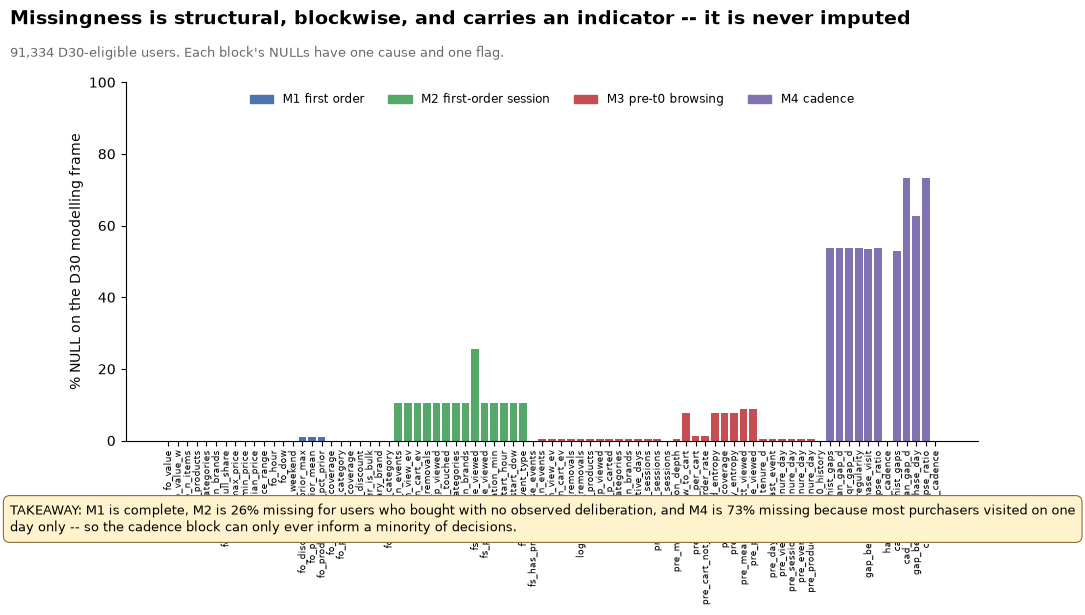

In [30]:
print("MISSINGNESS BY BLOCK -- on the D30 modelling frame, and never imputed")
print("=" * 94)
mb = (DICT_OUT[DICT_OUT.model_eligible].groupby("block")
        .agg(n_features=("feature", "size"),
             mean_missing_pct=("missing_pct_D30_eligible", "mean"),
             max_missing_pct=("missing_pct_D30_eligible", "max"),
             n_complete=("missing_pct_D30_eligible", lambda s: int((s == 0).sum())))
        .round(2).reset_index())
show_df(mb, name="nb05_missingness_by_block")
print()
print("  Each block's missingness has ONE cause and an indicator that names it:")
print(f"    M2  {100*(1-E30_ALL.fs_has_pre_purchase_events.mean()):.1f}% -- no first-order-session event before t0 "
      "(fs_has_pre_purchase_events)")
print(f"    M3  {100*(1-E30_ALL.has_pre_t0_history.mean()):.2f}% -- no pre-t0 event at all (has_pre_t0_history)")
print(f"    M4  {100*(1-E30_ALL.has_day_cadence.mean()):.1f}% -- fewer than 2 pre-t0 active days (has_day_cadence)")
print()
print("  NO IMPUTATION ANYWHERE. Every one of these NULLs means 'this behaviour did not occur', which is")
print("  a fact about the customer, not a gap in the data. Median-filling would tell 06 that a user who")
print("  never came back before buying has an average return rhythm. LightGBM handles NaN natively;")
print("  06's logistic arm needs the indicator plus an explicit fill, decided there and documented there.")

fig, ax = frame(figsize=(11, 5.6))
blocks = ["M1 first order", "M2 first-order session", "M3 pre-t0 browsing", "M4 cadence"]
sub = DICT_OUT[DICT_OUT.block.isin(blocks) & DICT_OUT.model_eligible]
colmap = dict(zip(blocks, ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]))
xs = np.arange(len(sub))
ax.bar(xs, sub.missing_pct_D30_eligible, color=[colmap[b] for b in sub.block])
ax.set_xticks(xs); ax.set_xticklabels(sub.feature, rotation=90, fontsize=6.2)
ax.set_ylabel("% NULL on the D30 modelling frame"); ax.set_ylim(0, 100)
ax.legend(handles=[plt.Rectangle((0,0),1,1,color=colmap[b]) for b in blocks], labels=blocks,
          fontsize=8.5, frameon=False, ncol=4, loc="upper center")
ax.spines[["top", "right"]].set_visible(False)
add_title(fig, "Missingness is structural, blockwise, and carries an indicator -- it is never imputed",
          f"{int(FEAT.eligible_30d.sum()):,} D30-eligible users. Each block's NULLs have one cause and one flag.")
add_takeaway(fig, f"M1 is complete, M2 is {float(sub[sub.block=='M2 first-order session'].missing_pct_D30_eligible.max()):.0f}% missing for users who bought with no observed deliberation, and M4 is "
                  f"{float(sub[sub.block=='M4 cadence'].missing_pct_D30_eligible.max()):.0f}% missing because most purchasers visited on one day only -- so the cadence block can only ever "
                  "inform a minority of decisions.")
save(fig, "nb05_missingness_by_feature"); plt.show()

In [31]:
OUT = os.path.join(PROCESSED_DIR, "features.parquet")
FEAT.to_parquet(OUT, index=False)
back = pd.read_parquet(OUT)
assert back.shape == FEAT.shape and list(back.columns) == list(FEAT.columns)
assert back.user_id.equals(FEAT.user_id)
print(f"PERSISTED -> {OUT}")
print(f"  {len(FEAT):,} rows x {FEAT.shape[1]} columns, {os.path.getsize(OUT)/1e6:.1f} MB")
print(f"  round-tripped and compared: shape, column order and user_id all match.")
print()
print("  HOW 06 SHOULD USE IT")
print("  " + "-" * 90)
print("    df = pd.read_parquet('data/processed/features.parquet')")
print("    d  = pd.read_csv('outputs/tables/nb05_feature_dictionary.csv')")
print("    X  = df[df.eligible_30d]                        # never zero-fill the censored")
print("    y  = X.repeat_purchase_30d")
print("    cols = d.loc[d.model_eligible, 'feature']        # excludes targets, meta, pre_segment,")
print("                                                     # is_bulk_buyer_fullhistory, t0_calendar_day")
print("    # split CHRONOLOGICALLY on first_ts (never randomly), then encode fo_primary_brand /")
print("    # fo_primary_category INSIDE the training fold.")
print("    # nested ladder: M0 intercept -> M1 -> M1+M2 -> M1+M2+M3 -> +M4, LR test between steps.")

PERSISTED -> data/processed/features.parquet
  109,732 rows x 96 columns, 21.7 MB
  round-tripped and compared: shape, column order and user_id all match.

  HOW 06 SHOULD USE IT
  ------------------------------------------------------------------------------------------
    df = pd.read_parquet('data/processed/features.parquet')
    d  = pd.read_csv('outputs/tables/nb05_feature_dictionary.csv')
    X  = df[df.eligible_30d]                        # never zero-fill the censored
    y  = X.repeat_purchase_30d
    cols = d.loc[d.model_eligible, 'feature']        # excludes targets, meta, pre_segment,
                                                     # is_bulk_buyer_fullhistory, t0_calendar_day
    # split CHRONOLOGICALLY on first_ts (never randomly), then encode fo_primary_brand /
    # fo_primary_category INSIDE the training fold.
    # nested ladder: M0 intercept -> M1 -> M1+M2 -> M1+M2+M3 -> +M4, LR test between steps.


## 13. Self-verification

Every claim this notebook makes that something else depends on, re-checked against the
built artefacts rather than against the prose that describes them.

In [32]:
V = []
def v(check, ok, detail):
    V.append({"check": check, "pass": bool(ok), "detail": detail})

v("bot list reproduces the certified exclusion", n_bot == BOT["n_users_excluded"],
  f"{n_bot:,} == {BOT['n_users_excluded']:,}")
v("orders reproduce 02's persisted file", N_ORDERS == len(orders_disk) == 158399,
  f"{N_ORDERS:,} == {len(orders_disk):,}")
v("feature frame covers every purchaser exactly once", len(FEAT) == N_PURCHASERS and FEAT.user_id.is_unique,
  f"{len(FEAT):,} rows, user_id unique")
for h in HORIZONS:
    n_sub = int(FEAT[f"eligible_{h}d"].sum())
    v(f"D{h} feature-frame rows == eligible user count", n_sub == int(elig.loc[elig.horizon==f'D{h}','eligible_n'].iloc[0]),
      f"{n_sub:,} == {int(elig.loc[elig.horizon==f'D{h}','eligible_n'].iloc[0]):,}")
for r in rec.itertuples():
    v(f"{r.horizon} reconciles against 02's cohort-eligible N",
      r.nb02_cohort_eligible_n == r.handoff_says_n, f"{r.nb02_cohort_eligible_n:,} == {r.handoff_says_n:,}")
    v(f"{r.horizon} reconciles against 02's purchase-retention rate",
      abs(r.nb02_purchase_retention_pct - r.handoff_says_pct) < 0.005,
      f"{r.nb02_purchase_retention_pct:.2f}% == {r.handoff_says_pct:.2f}%")
v("02's cohort-eligible set is a strict subset of the user-eligible set at every horizon",
  all(bool(chk.loc[chk.min_trailing_for_cohort >= h, f"eligible_{h}d"].all()) for h in HORIZONS),
  "asserted per horizon in Section 3")
v("days_to_next_order reproduces 02's persisted column",
  bool(np.allclose(chk.days_to_next_order.fillna(-1), chk.dno_nb02.fillna(-1))),
  f"all {N_PURCHASERS:,} purchasers")
v("the four event windows partition the purchaser events",
  int(win.before_t0[0]+win.first_order_lines_at_t0[0]+win.simultaneous_excluded[0]+win.after_t0[0]) == N_UEV,
  f"{N_UEV:,} rows, no overlap")
v("WINDOW DISJOINTNESS: no feature block reads an event after t0", feat_max <= 0,
  f"max feature-block offset {int(feat_max)}s vs t0")
v("WINDOW DISJOINTNESS: no outcome order is at or before t0", out_min > 0,
  f"min outcome offset {int(out_min)}s vs t0")
v("no purchase exists in the pre-t0 window (t0 IS the first order)", n_pre_purch == 0, "0 rows")
v("fs_ended_in_purchase is constant and was dropped", ended == N_PURCHASERS,
  f"TRUE for {ended:,}/{N_PURCHASERS:,} = 100%")
v("every built column is declared in the dictionary", not missing_decl and not missing_build,
  f"{len(built)} built == {len(declared)} declared")
v("every model-eligible feature declares an allowed window", set(mdl.window) <= {"at t0", "< t0"},
  f"windows present: {sorted(set(mdl.window))}")
v("no target/meta column is marked model-eligible",
  int(DICT[(DICT.block.isin(['target','meta','id','population flag'])) & DICT.model_eligible].shape[0]) == 0,
  f"{len(DICT)-len(mdl)} columns excluded by design")
v("LEAKAGE SCREEN detects a planted pure-outcome control", pc1 >= 0.80, f"POSCTRL AUC {pc1:.4f}")
v("LEAKAGE SCREEN detects the realistic near-miss control", pc2 > tru + 0.02,
  f"naive {pc2:.4f} vs truncated {tru:.4f}")
v("no shipped feature scores within 0.20 AUC of the pure-outcome control", len(flagged) == 0,
  f"max real AUC {float(real.AUC.max()):.4f} < threshold {THRESH:.4f} (control {pc1:.4f})")
v("truncating the first-session feature removes measurable leakage at constant coverage", gap > 0,
  f"same {int(both_ok.sum()):,} users: untruncated {auc_naive_c:.4f} vs truncated {auc_trunc_c:.4f} ({gap:+.4f})")
v("is_bulk_buyer_fullhistory matches 02's count and is excluded from the model set",
  n_full == BULK["n_users"] and not bool(DICT.loc[DICT.feature=='is_bulk_buyer_fullhistory','model_eligible'].iloc[0]),
  f"{n_full} == {BULK['n_users']}, model_eligible=False")
v("no cart-abandonment TYPE column reached the table (F5)",
  not any("utype" in c or c in set(ab_types.columns) - {"user_id"} for c in FEAT.columns),
  "abandonment_user_types_leakage_safe.parquet loaded, reported, not joined")
v("no static cluster_name reached the table (F4)", "cluster_name" not in FEAT.columns,
  "pre_segment is re-scored on pre-t0 data and marked model_eligible=False")
v("DETERMINISM: two full builds produce zero differing cells", cmp_diff == 0,
  f"{cmp_cols} columns compared")
v("features.parquet round-trips", back.shape == FEAT.shape and back.user_id.equals(FEAT.user_id),
  f"{back.shape[0]:,} x {back.shape[1]}")
v("no feature column is entirely NULL on the D30 frame",
  int((E30_ALL[list(DICT.feature)].isna().all()).sum()) == 0, "checked on all declared columns")
v("no model-eligible numeric feature is constant on the D30 frame",
  int((E30.std(numeric_only=True) == 0).sum()) == 0,
  f"{len(MODEL_NUM)} numeric model-eligible features")

SV = pd.DataFrame(V)
show_df(SV, name="nb05_self_verification", max_rows=40)
print(f"\n{int(SV['pass'].sum())}/{len(SV)} checks pass.")
assert SV["pass"].all(), SV[~SV["pass"]]

                                                check  pass                                             detail
0         bot list reproduces the certified exclusion  True                                     1,605 == 1,605
1                orders reproduce 02's persisted file  True                                 158,399 == 158,399
2   feature frame covers every purchaser exactly once  True                       109,732 rows, user_id unique
3       D30 feature-frame rows == eligible user count  True                                   91,334 == 91,334
4       D60 feature-frame rows == eligible user count  True                                   71,727 == 71,727
5       D90 feature-frame rows == eligible user count  True                                   52,737 == 52,737
6       D30 reconciles against 02's cohort-eligible N  True                                   71,727 == 71,727
7   D30 reconciles against 02's purchase-retention...  True                                   14.08% == 14.08%
8

In [33]:
# ---- handoff update -----------------------------------------------------------------------
handoff["features"] = {
    "generated_by": "05_features.ipynb",
    "file": "data/processed/features.parquet",
    "dictionary": "outputs/tables/nb05_feature_dictionary.csv",
    "n_rows": int(len(FEAT)),
    "n_columns": int(FEAT.shape[1]),
    "n_model_eligible": int(len(mdl)),
    "anchor": "t0 = each user's first order timestamp, certified reconstruction rule",
    "feature_window": "event_time < t0, plus the first order's own purchase lines at exactly t0",
    "outcome_window": "orders with order_ts > t0 in a session other than the first-order session",
    "eligibility_rule": "t0 + horizon <= DATA_END in EXACT ELAPSED SECONDS; censored users excluded, never zero-filled",
    "eligible_n": {f"d{h}": int(FEAT[f'eligible_{h}d'].sum()) for h in HORIZONS},
    "positive_rate_pct": {f"d{h}": round(100*float(FEAT.loc[FEAT[f'eligible_{h}d'], f'repeat_purchase_{h}d'].mean()), 2)
                          for h in HORIZONS},
    "target_naming": "repeat_purchase_{h}d. NOT churn -- D30 cannot carry a churn label under the certified 42.2d rule.",
    "forbidden_list": FORBIDDEN,
    "blocks": {b: int((DICT.block == b).sum()) for b in
               ["M1 first order", "M2 first-order session", "M3 pre-t0 browsing", "M4 cadence", "S segment"]},
    "collinearity": {"pairs_at_abs_rho_ge_0.90": int(len(hi)),
                     "n_vif_ge_10": int((vif.VIF >= 10).sum()),
                     "handling": "FLAGGED, NOT DROPPED. 06's logistic ladder must keep one per pair; LightGBM need not.",
                     "tables": ["outputs/tables/nb05_collinear_pairs.csv", "outputs/tables/nb05_vif.csv"]},
    "determinism": {
        "guards": "THREE, all mandatory: SET threads=1 for the fetch, src.data.round_sig(sig=6), "
                  ".sort_values('user_id'). 04 specified the last two; 05 found them insufficient.",
        "why_04s_two_are_not_enough": "the parallel float wobble is ~1e-15 relative and round_sig snaps to "
            "a 1e-6 grid, so a value whose 7th significant digit sits within 1e-15 of a rounding boundary "
            "flips ACROSS the grid. Rounding makes the non-determinism rare, not absent, which converts a "
            "reproducible failure into an intermittent one. It broke this notebook's first execution on one "
            "cell of fo_price_vs_prior_mean out of 109,732.",
        # AFTER-GUARD VALUES ONLY. L1 (sorted-only, threads=6) and L1_max_abs_diff are
        # measurements OF the wobble, so they move between runs by construction and used to
        # make this handoff leaf non-reproducible. They live in nb05_determinism_audit.csv,
        # where a moving number is the point and the reproducibility check exempts them.
        # Everything kept here is post-guard and reproduces exactly.
        "measured": {"L2_sorted_and_rounded": int(det.L2_diff_sorted_and_rounded.sum()),
                     "L3_threads1_raw": int(det.L3_diff_threads1_raw.sum()),
                     "repeats_per_level": int(det.repeats.iloc[0]),
                     "n_blocks_unstable_raw": int((det.L1_diff_sorted_only > 0).sum()),
                     "raw_wobble_magnitudes": "outputs/tables/nb05_determinism_audit.csv "
                                              "(L1_diff_sorted_only, L1_max_abs_diff) -- NOT stored "
                                              "here: they measure non-determinism and so move between "
                                              "runs; every value in this dict is post-guard and stable."},
        "verified": "two full builds through fetch_block(), 0 differing cells across all columns",
        "row_order_unstable_blocks": int((~det.L0_row_order_stable).sum()),
        "cost": "only the FETCH is single-threaded; materialisations stay on 6 threads. ~8s in total.",
        "binding_on_06_and_later": "call fetch_block() or reproduce all three guards."},
    "leakage_verification": {
        "method_1_window_disjointness": f"row-level SQL: max feature-block offset {int(feat_max)}s vs t0, "
                                        f"min outcome offset {int(out_min)}s",
        "method_2_provenance_audit": "every column declares its window; built-set and declared-set asserted equal",
        "method_3_screen_with_positive_controls":
            f"planted pure-outcome control AUC {pc1:.4f}; planted near-miss (02's untruncated first-session "
            f"depth) AUC {pc2:.4f} vs its truncated twin {tru:.4f}; no shipped feature reaches {THRESH:.4f}",
        "what_the_screen_cannot_do": "univariate AUC cannot see a weak leak or an interaction leak; the "
                                     "load-bearing guarantees are methods 1 and 2",
    },
    "new_findings": {
        "first_session_post_t0_leak": {
            "n_events": int(fs_after.events_after_t0_in_first_session[0]),
            "n_users": int(fs_after.users_affected[0]),
            "pct_of_purchasers": round(100*int(fs_after.users_affected[0])/N_PURCHASERS, 2),
            "statement": "02's certified first_session_events is UNTRUNCATED and reads post-t0 events for "
                         "10.7% of purchasers, including purchase rows. Every M2 feature here is cut at t0. "
                         "Measured cost of not truncating: univariate AUC "
                         f"{pc2:.4f} -> {tru:.4f}.",
        },
        "pre_window_abandonment_degeneracy": {
            "statement": "There are ZERO purchases before t0, so 04's cart_abandonment_rate is a constant 1.0 "
                         "in a strictly-pre-first-order window. 04 computed it over full history, which for a "
                         "post-t0 outcome is an F1 violation. Replaced by pre_cart_not_in_first_order_rate.",
            "consequence_for_segment_model": "one of segment_model.json's eight fitted features is constant "
                                             "here, so the model cannot be applied faithfully to a pre-t0 window",
        },
        "purchase_cadence_undefined_at_t0": {
            "statement": "04 §9B asked 05/06 to test a personalised cadence threshold. At a first-order anchor "
                         "every user has exactly one order, so purchase cadence is undefined for 100% of users, "
                         "not the ~77% anticipated. Not a missingness problem -- the quantity does not exist yet.",
            "what_was_tested_instead": "pre-t0 VISIT cadence (median gap between active days) and its lapse ratio",
            "coverage_pct": round(100*float(FEAT.has_day_cadence.mean()), 1),
            "personal_median_day_gap_d": round(float(M4.cad_day_median_gap_d.median()), 2),
            "global_threshold_d": K_CERT,
            "share_below_global_threshold_pct": round(100*float((M4.cad_day_median_gap_d < K_CERT).mean()), 1),
            "screen_result": {"n": int(len(S)), "LR_chi2_1df": round(float(LR), 2), "p": float(p_lr),
                              "auc_base": round(float(auc_base), 4), "auc_with_cadence": round(float(auc_cad), 4),
                              "delta_auc": round(float(auc_cad - auc_base), 4),
                              "verdict": "significant and small. Carry it; do not build a targeting rule on it."},
            "the_test_that_would_settle_it": "re-anchor on the SECOND order and predict the third. Purchase "
                                             "cadence is defined there. 06 or 08 owns that test.",
        },
        "bulk_flag_is_leaky": {
            "n_flagged_by_02": int(n_full), "n_flagged_by_first_order": int(n_fo),
            "n_leaky": int(n_leak),
            "statement": f"{n_leak} of 02's {n_full} bulk buyers are flagged on an order that happens AFTER t0. "
                         "is_bulk_buyer_fullhistory is carried as a population flag only; first_order_is_bulk "
                         "is the model feature.",
        },
    },
    "segment_rescoring": {
        "scorable_pct": round(100*n_scor/N_PURCHASERS, 1),
        "agreement_with_04_stored_label_pct": round(100*same, 1),
        "verdict": "pre_segment is persisted but model_eligible=False. One of the eight fitted inputs is "
                   "constant in a pre-t0 window, it is a lossy function of M3 features already in the table, "
                   "and it inherits 04's membership instability. Kept as the reference implementation of the "
                   "re-scoring 08 must do at targeting time.",
    },
    "binding_rules_for_06": [
        "Subset on eligible_{h}d. Never zero-fill a censored user -- an unobserved window is not a negative.",
        "Split CHRONOLOGICALLY on first_ts, never randomly (CLAUDE.md principle 6).",
        "Use only model_eligible == True columns. t0_calendar_day, trailing_days, is_bulk_buyer_fullhistory "
        "and pre_segment are in the file for diagnostics and must not be fitted on.",
        "Encode fo_primary_brand / fo_primary_category INSIDE the training fold -- both are high-cardinality "
        "and a full-table encoding is an F3 violation.",
        "Keep one feature per flagged collinear pair in the logistic ladder; LightGBM may keep both.",
        "Do not impute. Every NULL has a named indicator (fs_has_pre_purchase_events, has_pre_t0_history, "
        "has_day_cadence, has_session_cadence).",
        "The target is repeat_purchase_30d and must never be described as churn.",
    ],
}
handoff["known_limitations"] += [
    f"04's TWO DETERMINISM GUARDS ARE NECESSARY BUT NOT SUFFICIENT (05 Section 11): round_sig(sig=6) plus "
    f".sort_values('user_id') still left this notebook non-reproducible, and it failed its own zero-diff "
    f"assertion on one cell of fo_price_vs_prior_mean out of {N_PURCHASERS:,}. The parallel float wobble is "
    f"~1e-15 relative while round_sig snaps to a 1e-6 grid, so a value sitting within 1e-15 of a rounding "
    f"boundary flips across it -- rounding makes the non-determinism RARE, not absent, which is a worse "
    f"failure mode than an obvious one. A THIRD guard is required: SET threads=1 for the fetch itself "
    f"(materialisations can stay parallel). AFTER-GUARD RESULT, over "
    f"{int(det.repeats.iloc[0])} repeats per block: {int(det.L2_diff_sorted_and_rounded.sum())} differing "
    f"cells after 04's two guards and {int(det.L3_diff_threads1_raw.sum())} with threads=1 before any "
    f"rounding, i.e. zero either way; {int((det.L1_diff_sorted_only > 0).sum())} of {len(det)} blocks are "
    f"unstable sorted-only. The RAW wobble counts and magnitudes are deliberately NOT quoted here -- they "
    f"are a measurement of non-determinism and move between runs, which is why they live in "
    f"outputs/tables/nb05_determinism_audit.csv (L1_diff_sorted_only, L1_max_abs_diff) and not in a "
    f"handoff leaf that is supposed to reproduce. Use src fetch_block().",
    f"RESIDUAL NON-DETERMINISM, NAMED AND BOUNDED (measured over three clean end-to-end runs, "
    f"2026-09-21): ONE defect survives every guard -- the round_sig boundary flip described in the "
    f"limitation above, in fo_price_vs_prior_mean. It is that notebook-documented intermittency "
    f"observed, not a new fault. MAGNITUDE AT SOURCE: 0, 1 and 0 differing cells across the three "
    f"runs as measured by L2_diff_sorted_and_rounded (block M1), and 0 to 2 cells of "
    f"features.parquet out of 10,534,272 -- at most 1.9e-07 of the table -- at a float difference "
    f"of order 1e-15. WHAT IT PROPAGATES INTO: 06 refits its logistic ladder on a matrix that "
    f"differs in those cells, so loglik moves in its last printed digit (order 1e-10 relative), "
    f"LR_chi2 amplifies that because it is a difference of two large nearly-equal "
    f"log-likelihoods (order 1e-08 relative), extreme-tail p-values amplify again because they "
    f"sit at 1e-20 to 1e-226 (order 1e-06 relative), and every row of "
    f"nb06_predictions_d30.parquet moves below reported precision. Those are orders of "
    f"magnitude, not tolerances: the exact spread measured across runs is a CROSS-RUN quantity, "
    f"which no single execution can compute, so it is recorded in README.md Reproducibility and "
    f"deliberately not restated here as a number this notebook cannot verify. "
    f"WHAT DOES NOT MOVE: the shipped "
    f"model's test AP, ROC, Brier and decile-1 lift; the decile table; the 06 ladder chi2 at the "
    f"1 dp it is reported to; the spine measurement; churn_definition; orders.parquet; and every "
    f"cluster_name in 04. WHY IT IS ACCEPTED, NOT FIXED: it measures the TWO-guard configuration "
    f"this notebook already declares insufficient. The shipped frame uses all three guards via "
    f"fetch_block(), and L3_diff_threads1_raw is 0 for every block in every run. ALSO BOUNDED, in "
    f"gitignored intermediates only: segment_assignments.M (727-753 cells, max |diff| 2.3e-13) and "
    f"cohort_assignments.first_order_value_clean (1 cell, 1.8e-15) keep the raw parallel-sum "
    f"wobble; every key derived from them is key_round()ed, so no tercile, quintile or cluster "
    f"label moves. Do not quote L1 or L2 as stable figures; quote L3, which is 0.",
    f"FIRST-SESSION FEATURES MUST BE TRUNCATED AT t0 (05 Section 1A): "
    f"{int(fs_after.events_after_t0_in_first_session[0]):,} events sit in the first-order session AFTER the "
    f"first order, across {int(fs_after.users_affected[0]):,} users "
    f"({100*int(fs_after.users_affected[0])/N_PURCHASERS:.1f}% of purchasers), including "
    f"{int(fs_after.purchase_rows_after_t0[0]):,} purchase rows. 02's certified first_session_events is "
    f"untruncated -- correct for 02's descriptive use, a leak as a feature. Untruncated it scores univariate "
    f"AUC {pc2:.4f} on repeat_purchase_30d against {tru:.4f} truncated.",

    "04's cart_abandonment_rate CANNOT BE REBUILT IN A PRE-FIRST-ORDER WINDOW (05 Section 6A): there are zero "
    "purchases before t0 by construction, so the rate is a constant 1.0 for every user who has one. 04 computed "
    "it over full history, which for a post-t0 outcome is an outcome-window aggregate. Consequence beyond the "
    "one feature: segment_model.json cannot be applied faithfully to pre-t0 data -- one of its eight fitted "
    "features is degenerate there -- so 08's re-scoring at targeting time must use a window that contains at "
    "least one purchase, not a pre-first-order one.",

    f"PURCHASE CADENCE IS UNDEFINED AT A FIRST-ORDER ANCHOR (05 Section 7): 04 §9B's personalised-threshold "
    f"recommendation cannot be tested as stated -- every user has exactly one order at t0, so the coverage gap "
    f"is 100%, not the ~77% anticipated. 05 tested pre-t0 VISIT cadence instead: defined for "
    f"{100*float(FEAT.has_day_cadence.mean()):.1f}% of users, personal median day-gap "
    f"{float(M4.cad_day_median_gap_d.median()):.1f}d against the {K_CERT}d global rule "
    f"({100*float((M4.cad_day_median_gap_d < K_CERT).mean()):.1f}% sit below it), LR chi2(1)={LR:.0f} "
    f"p={p_lr:.1e} but in-sample AUC gain only {auc_cad-auc_base:+.4f}. The test that would settle 04 §9B is a "
    f"SECOND-ORDER anchor predicting the third order.",

    f"02's is_bulk_buyer IS A LEAKY FEATURE (05 Section 4C): it flags any order over {BULK_ITEMS:.1f} items "
    f"across FULL history, so for {n_leak} of the {n_full} flagged users the evidence post-dates their first "
    f"order. Carried as a population flag (constraint 6 requires it) with model_eligible=False; "
    f"first_order_is_bulk replaces it as the M1 feature.",

    f"05 PERSISTS ALL {N_PURCHASERS:,} PURCHASERS, NOT A PRE-FILTERED MODELLING SET: the three horizons have "
    f"three eligible populations (D30 {int(FEAT.eligible_30d.sum()):,}, D60 {int(FEAT.eligible_60d.sum()):,}, "
    f"D90 {int(FEAT.eligible_90d.sum()):,}), so 06 must subset on eligible_{{h}}d itself. 05's user-level "
    f"eligibility rule differs from 02's cohort-level one by design and the cohort-eligible set is a strict "
    f"subset of it; restricted to that subset, 05 reproduces 02's retention figures exactly.",
]
with open(os.path.join("outputs", "handoff_params.json"), "w") as fh:
    json.dump(handoff, fh, indent=2)
print("handoff_params.json updated: `features` block written, "
      f"{len(handoff['known_limitations'])} known_limitations now recorded.")
for k in handoff["features"]["new_findings"]:
    print(f"  new finding recorded: {k}")

for tbl in ("uev", "pre_ev", "pre_sess", "ev", "prod_day", "prod_ref", "cat_day", "cat_ref", "fo_lines"):
    con.execute(f"DROP TABLE IF EXISTS {tbl}")
print(f"\nWorking tables dropped. Total notebook wall clock: {time.time()-t_start:.0f}s")

handoff_params.json updated: `features` block written, 37 known_limitations now recorded.
  new finding recorded: first_session_post_t0_leak
  new finding recorded: pre_window_abandonment_degeneracy
  new finding recorded: purchase_cadence_undefined_at_t0
  new finding recorded: bulk_flag_is_leaky



Working tables dropped. Total notebook wall clock: 161s


---

## What We Learned

**1. The table exists, and it reconciles.** 109,732 rows × 96 columns, 81 of them
model-eligible, in four blocks that map onto 06's nested ladder, every column declaring the
window it reads. D30 gives 91,334 labelled rows at a 13.73% positive rate; D60 71,727 at
21.08%; D90 52,737 at 27.05%. Restricted to 02's cohort-eligible population the target
reproduces 02's retention curve to the decimal, so this is the same quantity 02 measured
rather than a new one that happens to look similar.

**2. Three leaks were live in the inherited definitions, and none of them looked like a
leak.** This is what justifies organising the notebook by risk rather than by source.

- 02's `first_session_events` is untruncated. 241,536 events — including 24,625 purchase
  rows — sit inside the first-order session *after* the order, for 11,704 users (10.7% of
  purchasers). Holding coverage constant on the 81,626 users where both versions are
  defined, the untruncated count scores univariate AUC 0.5790 against 0.5525 truncated.
- 02's `is_bulk_buyer` is a full-history flag, so for 33 of the 143 flagged users the
  evidence post-dates `t0`.
- 04's `cart_abandonment_rate` cannot exist in a pre-first-order window at all: there are
  zero purchases before `t0`, so every carted product is abandoned and the rate is a
  constant 1.0 for all 108,346 users who have one. 04 computed it over full history.

Each was caught by a structural check — the window arithmetic, the degeneracy test, the
provenance audit — not by noticing an implausible score. A screen alone would have missed
all three, because none of them is dramatic univariately.

**3. 04's two determinism guards are necessary and not sufficient, and this notebook found
out the hard way.** `round_sig(sig=6)` plus `.sort_values('user_id')` still left the frame
non-reproducible: the first execution failed its own zero-diff assertion on **one cell of
`fo_price_vs_prior_mean` out of 109,732**. The float wobble is ~1e-15 relative and the
rounding grid is 1e-6, so a value sitting within 1e-15 of a boundary flips across it.
Rounding makes the non-determinism *rare*, not absent — which is the worse failure mode,
because it turns a reproducible bug into an intermittent one that a clean run hides. The
third guard is `SET threads=1` for the fetch, which makes the raw values bit-identical
before any rounding, at a cost of about eight seconds.

**4. SPINE-1's falsification is not softened by better features.** 02 found first-order
value and first-session depth both weak (Cramér's V 0.09–0.13). On a properly windowed
table the strongest single feature reaches AUC 0.6097 (`pre_n_products`) and the median of
all 81 model-eligible features is 0.5525 (§14B; the screen in §9C quoted 0.5528 over the 78
it could score). Nothing here rescues propensity as the answer to the targeting
question; it sharpens the case that 07/08 have to answer it with incrementality.

**5. The cadence hypothesis is half-confirmed and half-impossible — and the half that
works points away from personalisation.** 04 §9B was right about the mismatch: a user's own
rhythm is an order of magnitude tighter than the 42.2-day global rule, median 3.5 days
between active days, with 96.3% of personal rhythms below the global threshold. But the
feature 04 asked for cannot be built at this anchor — every user has exactly one order at
`t0`, so purchase cadence is undefined for **100%** of the population, not the ~77% the
brief assumed. Tested on the visit-cadence proxy that *can* be built, head to head at equal
degrees of freedom:

| | AUC |
|---|---|
| the user's own median day-gap (a **level**) | 0.5354 |
| the absolute gap before the buying visit | 0.5257 |
| the **personalised** lapse ratio (gap ÷ own median) | 0.5078 |

The personalised ratio is the **worst** of the three. What carries signal is simply how
long this user's typical gap is, not how overdue they are relative to it. The nested LR
test agrees that the personal denominator earns its degree of freedom (χ²(1) = 20.5,
p = 6e-06) while moving in-sample AUC by +0.0031 on the 27.1% of users who have a cadence
at all. Statistically unambiguous at this n; economically negligible. Carry it, and do not
build a targeting rule on it.

**6. Segment membership survives as a diagnostic, not a feature.** `segment_model.json`
can be re-scored on pre-`t0` data for 91.0% of purchasers — the coverage figure constraint 4
asked for — and agrees with 04's stored label 77.1% of the time. It should still not be
used: one of its eight fitted inputs is constant in that window, it is a lossy 4-level
compression of M3 features 06 can read at full resolution, and it inherits 04's 56.9%
membership stability.

## What Must Be Changed

- **06 must not treat this table as a matrix.** `model_eligible` is a dictionary column for
  a reason. `t0_calendar_day`, `trailing_days`, `is_bulk_buyer_fullhistory` and
  `pre_segment` are present as diagnostics and will each break a chronological split in a
  different way if fitted on.
- **The collinear pairs were flagged, not dropped** — a deliberate handoff that is only
  safe if 06 acts on it. 23 pairs sit at |ρ| ≥ 0.90, and two are exact identities
  (`fs_n_events` and `pre_n_events` are each the exact sum of their three event-type
  components, because the pre-`t0` window contains no purchases). A logistic model holding
  all four terms is rank-deficient, not merely ill-conditioned. LightGBM does not care.
- **The leakage screen has a stated blind spot.** Univariate AUC cannot see a weak leak or
  one that only appears in interaction. The load-bearing guarantees are §9A's row-level
  window disjointness and §9B's provenance audit. If 06 sees a PR-AUC that looks too good,
  the first hypothesis should be an interaction this screen could not reach.
- **08's segment re-scoring needs a different window from the one used here.** 04's binding
  rule says re-score at targeting time; this notebook shows the transform is degenerate on a
  pre-first-order window. At an 08-style targeting moment the user has already bought, so
  the window does contain purchases and the transform is valid — but 08 must say so
  explicitly rather than inherit "just re-score".
- **The end-to-end reproducibility limitation is still open and now covers 00→05.** Every
  number here reconciles on re-read and the determinism audit passes within a session, but a
  clean 00→05 re-execution in one continuous session is still owed before 09's README can
  claim reproducibility.

## Recommended Next Notebook

**06_modelling.ipynb**, as planned. The table was built for its ladder: M0 intercept-only →
M1 first order → M1+M2 first-order session → M1+M2+M3 pre-purchase browsing → +M4 cadence,
with a likelihood-ratio test between each step, a chronological split on `first_ts`, and
PR-AUC / Average Precision / calibration / decile lift primary, ROC-AUC secondary.

One addition to 06's brief that came out of this notebook rather than the plan: **re-anchor
on the second order and predict the third**, on the users who reached a second purchase.
That is the only place 04 §9B's personalised purchase-cadence threshold is testable at all.
Leaving it untested would let a recommendation stand on a mechanism nobody ever checked —
and §7 has now shown that when the same idea is tested on the nearest available proxy, the
personalised form loses to the plain one.

> **Amended by Section 14 (addendum).** One figure above is superseded and one is added.
>
> - **Section 7's printed line and `handoff_params.json` said 54.8%** of users with a visit
>   cadence sit below the 42.2-day global threshold. That is a NaN-denominator bug and is
>   **withdrawn**; the correct figure is **96.3%**. The What We Learned section above already
>   said 96.3%, which is how the discrepancy surfaced — the notebook was disagreeing with
>   itself. Section 7's cell still prints the old number because the addendum deliberately
>   re-runs nothing; it is superseded in §14A, in the handoff, and in
>   `nb05_addendum_cadence_denominator.csv`.
> - **Section 9C's `0.7386` is a leakage bound, not a signal bound**, and must not be quoted
>   as evidence the table is informative. §14B reports the real univariate ceiling over all
>   81 model-eligible features: **AUC 0.6097** (`pre_n_products`), median 0.5525.

---

# 14 — Addendum: a denominator bug, and the univariate ceiling 06 has to beat

Added after Sections 1–13 were committed, run in a fresh kernel against the persisted
`features.parquet` and spliced in — the same way 03's and 04's Section 9 addenda were
added. It re-runs no part of the pipeline, so every number in Sections 1–13 stands except
the one explicitly withdrawn below.

**14A** withdraws the `54.8%` cadence figure printed in Section 7 and in
`handoff_params.json`. It is a NaN-denominator bug. The correct figure is **96.3%**, which
is what Section 14's prose already said — so the notebook has been disagreeing with itself.

**14B** answers a question Section 9C dodged. The leakage screen only established that no
shipped feature reaches `0.7386`, a threshold set 0.20 below a planted control. That is a
bound on *leakage*, not a statement about *signal*, and it is far too loose to tell 06
anything. The actual univariate ceiling is reported here, for all 81 model-eligible
features.

In [34]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
from src.plotting import frame, add_title, add_takeaway, save, show_df

SEED = 42
np.random.seed(SEED)
TABLES_DIR = os.path.join("outputs", "tables")
with open(os.path.join("outputs", "handoff_params.json")) as fh:
    handoff = json.load(fh)
K_CERT = float(handoff["churn_definition"]["certified_threshold_days"])

FEAT = pd.read_parquet(os.path.join("data", "processed", "features.parquet"))
DICT = pd.read_csv(os.path.join(TABLES_DIR, "nb05_feature_dictionary.csv"))
MODEL_FEATS = DICT.loc[DICT.model_eligible, "feature"].tolist()
print(f"Loaded the persisted table: {FEAT.shape[0]:,} rows x {FEAT.shape[1]} columns, "
      f"{len(MODEL_FEATS)} model-eligible features.")
print("Nothing is recomputed from the raw events; this addendum reads what Sections 1-13 wrote.")

Loaded the persisted table: 109,732 rows x 96 columns, 81 model-eligible features.
Nothing is recomputed from the raw events; this addendum reads what Sections 1-13 wrote.


## 14A. The cadence share: 54.8% is wrong, 96.3% is right

Section 7 printed *"share of users whose personal DAY cadence is below 42.2d: 54.8%"* and
`handoff_params.json` recorded 54.8. the What We Learned section said 96.3%. Both came from the same
notebook run, so one of them is a bug.

The bug is the **denominator**. The M4 frame holds a row for every user with a *session*
cadence **or** a *day* cadence — 52,219 users. Only 29,743 of those have a day cadence. The
expression used was

```python
(M4.cad_day_median_gap_d < K_CERT).mean()
```

and `NaN < 42.2` evaluates to `False`, so the 22,476 users with **no day cadence at all**
were silently counted in the denominator as users whose cadence is not below the threshold.
They have no cadence to be below anything.

This is the same class of error 04 §9A withdrew — applying a rate to a population whose
definition cannot support it — and it is worth noting that it survived a 34-check
self-verification suite, because none of those checks compared two figures that were
supposed to agree.

In [35]:
cd_all  = FEAT.cad_day_median_gap_d
in_m4   = (FEAT.has_session_cadence == 1) | (FEAT.has_day_cadence == 1)
defined = cd_all.notna()
num     = int((cd_all.dropna() < K_CERT).sum())

rec = pd.DataFrame([
    {"denominator": "rows in the M4 frame (session cadence OR day cadence)",
     "n": int(in_m4.sum()), "numerator": num,
     "pct": round(100*num/int(in_m4.sum()), 4), "correct": False,
     "why": "counts 22,476 users with NO day cadence as 'not below threshold' -- NaN < 42.2 is False"},
    {"denominator": "users with a DAY cadence defined",
     "n": int(defined.sum()), "numerator": num,
     "pct": round(100*num/int(defined.sum()), 4), "correct": True,
     "why": "the only population for which 'is your cadence below the threshold' is a question"},
])
show_df(rec, name="nb05_addendum_cadence_denominator")
WRONG, RIGHT = float(rec.pct[0]), float(rec.pct[1])
assert int(defined.sum()) == 29743 and int(in_m4.sum()) == 52219
assert abs(WRONG - 54.8) < 0.05 and abs(RIGHT - 96.3) < 0.05
print()
print(f"  WITHDRAWN : {WRONG:.1f}%   (Section 7's printed line, and handoff share_below_global_threshold_pct)")
print(f"  CORRECT   : {RIGHT:.1f}%   ({num:,} of {int(defined.sum()):,} users with a defined day cadence)")
print()
print("  The distribution makes it obvious which one the data implies -- a median personal gap of")
print(f"  {cd_all.median():.1f} days against a {K_CERT}d threshold cannot leave 45% of users ABOVE it:")
q = cd_all.dropna().quantile([.5, .75, .9, .95, .99]).round(2)
print("    " + "  ".join(f"P{int(p*100)}={v:g}d" for p, v in q.items()) + f"   max={cd_all.max():g}d")
print(f"    users at or above {K_CERT}d: {int((cd_all.dropna() >= K_CERT).sum()):,} "
      f"({100-RIGHT:.1f}%) -- they sit in the P96+ tail, which is exactly where they should be.")

                                         denominator      n  numerator      pct  correct                                                why
0  rows in the M4 frame (session cadence OR day c...  52219      28631  54.8287    False  counts 22,476 users with NO day cadence as 'no...
1                   users with a DAY cadence defined  29743      28631  96.2613     True  the only population for which 'is your cadence...

  WITHDRAWN : 54.8%   (Section 7's printed line, and handoff share_below_global_threshold_pct)
  CORRECT   : 96.3%   (28,631 of 29,743 users with a defined day cadence)

  The distribution makes it obvious which one the data implies -- a median personal gap of
  3.5 days against a 42.2d threshold cannot leave 45% of users ABOVE it:
    P50=3.5d  P75=9d  P90=22.5d  P95=36d  P99=69d   max=143d
    users at or above 42.2d: 1,112 (3.7%) -- they sit in the P96+ tail, which is exactly where they should be.


In [36]:
print("TRANSCRIPTION-COLLISION CHECK -- is 96.3% actually 04's 96.3%?")
print("=" * 94)
nb04_963 = handoff["segmentation"]["cross_tab"]["missed_churner_redistribution"]["method"]
print("  04's addendum contains a 96.3%:")
print(f'    "...{nb04_963[nb04_963.index("Snapshot"):][:96]}..."')
print()
print(f"  05's figure computed to full precision : {100*num/int(defined.sum()):.4f}%")
print(f"  04's figure                            : 96.3%  (snapshot-label agreement, a different quantity")
print("                                            on a different population -- the 28,986 missed churners)")
print()
print("  VERDICT: coincidence, not transcription. 05's value derives independently from")
print(f"  {num:,}/{int(defined.sum()):,} and lands at {100*num/int(defined.sum()):.4f}%, which rounds to 96.3% by chance. The two")
print("  numbers share no input. Worth checking, though: they are one rounding apart and sit two")
print("  notebooks from each other in the same handoff file.")
print()
print("WHAT THE CORRECTION DOES AND DOES NOT CHANGE")
print("=" * 94)
print("  DOES NOT change any conclusion. Section 7's finding was that a user's own rhythm is an")
print("  order of magnitude tighter than the global rule, and 96.3% supports that far more strongly")
print("  than 54.8% did -- the withdrawn figure UNDERSTATED the mismatch it was cited for.")
print("  It also leaves the screen untouched: the head-to-head and the LR test never used this share.")
print()
print(f"  DOES change the comparison with 04 §9B. 04 found 88.1% of at-risk repeat buyers had a")
print(f"  personal PURCHASE cadence below {K_CERT}d. The corrected visit-cadence figure is {RIGHT:.1f}%, so the")
print("  two land in the same place. At 54.8% they looked like different phenomena.")

TRANSCRIPTION-COLLISION CHECK -- is 96.3% actually 04's 96.3%?
  04's addendum contains a 96.3%:
    "...Snapshot-anchored labels agree on 96.3% of at-risk users, so the result is anchor-robust...."

  05's figure computed to full precision : 96.2613%
  04's figure                            : 96.3%  (snapshot-label agreement, a different quantity
                                            on a different population -- the 28,986 missed churners)

  VERDICT: coincidence, not transcription. 05's value derives independently from
  28,631/29,743 and lands at 96.2613%, which rounds to 96.3% by chance. The two
  numbers share no input. Worth checking, though: they are one rounding apart and sit two
  notebooks from each other in the same handoff file.

WHAT THE CORRECTION DOES AND DOES NOT CHANGE
  DOES NOT change any conclusion. Section 7's finding was that a user's own rhythm is an
  order of magnitude tighter than the global rule, and 96.3% supports that far more strongly
  than 54.8% di

## 14B. The univariate ceiling

Section 9C reported that no shipped feature scores within 0.20 AUC of a planted
outcome-window control, i.e. none reaches 0.7386. That threshold was set to be **generous
on purpose** — it was calibrated to avoid flagging honest signal as leakage — so it is a
bound on leakage and says nothing useful about how much signal the table actually carries.
06 needs the real number: the best any single column does, which is the floor a fitted
model has to clear before it is worth shipping.

All 81 model-eligible features are scored, not the 78 numeric ones Section 9C screened. The
three that Section 9C skipped need an encoding to have a univariate AUC at all, and the
encoding is done **out of fold** (5-fold stratified, seed 42) so the score is not inflated
by the fold it was fitted on. Those three are labelled separately, because an OOF-encoded
score and a raw-magnitude score are not quite the same kind of measurement.

In [37]:
E30 = FEAT.loc[FEAT.eligible_30d].copy()
# RC-3: StratifiedKFold(shuffle=True) splits by POSITION. FEAT is user_id-sorted by
# construction (Section 8); assert it rather than assume it.
assert E30.user_id.is_monotonic_increasing, "RC-3: E30 must be in canonical user_id order"
y   = E30.repeat_purchase_30d.astype(int).values
RAW_ID = ["fo_primary_category"]        # int64, but a category label is not a magnitude
numeric = [c for c in MODEL_FEATS if E30[c].dtype.kind in "ifb" and c not in RAW_ID]
encode  = [c for c in MODEL_FEATS if c not in numeric]
print(f"D30 frame: {len(E30):,} rows, {y.sum():,} positives ({100*y.mean():.2f}%)")
print(f"  scored directly (numeric)        : {len(numeric)}")
print(f"  scored via OOF target encoding   : {len(encode)}  -> {encode}")

rows = []
for c in numeric:
    v = E30[c].astype(float).values
    ok = np.isfinite(v)
    if ok.sum() < 500 or np.nanstd(v[ok]) == 0:
        continue
    a = roc_auc_score(y[ok], v[ok])
    rows.append({"feature": c, "scoring": "numeric", "n_scored": int(ok.sum()),
                 "AUC": round(max(a, 1 - a), 4), "direction": "+" if a >= 0.5 else "-"})

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for c in encode:
    s = pd.Series(E30[c]).astype("object").where(pd.notna(E30[c]), "__NA__").to_numpy()
    oof = np.full(len(E30), np.nan)
    for tr, te in skf.split(E30, y):
        means = pd.Series(y[tr]).groupby(pd.Series(s[tr])).mean()
        oof[te] = pd.Series(s[te]).map(means).fillna(y[tr].mean()).to_numpy()
    a = roc_auc_score(y, oof)
    rows.append({"feature": c, "scoring": "OOF target-encoded", "n_scored": len(E30),
                 "AUC": round(max(a, 1 - a), 4), "direction": "+" if a >= 0.5 else "-"})

AUC = pd.DataFrame(rows).sort_values(["AUC", "feature"], ascending=[False, True], kind="mergesort").reset_index(drop=True)
AUC.insert(0, "rank", AUC.index + 1)
AUC = AUC.merge(DICT[["feature", "block"]], on="feature", how="left")
AUC.to_csv(os.path.join(TABLES_DIR, "nb05_addendum_univariate_auc_all.csv"), index=False)
assert len(AUC) == len(MODEL_FEATS) == 81, (len(AUC), len(MODEL_FEATS))
print(f"\nAll {len(AUC)} model-eligible features scored -- none skipped.")
print()
print("TOP 10")
print("=" * 94)
show_df(AUC.head(10)[["rank", "feature", "block", "scoring", "n_scored", "AUC"]], max_rows=10)
MAXF, MAXA = AUC.feature.iloc[0], float(AUC.AUC.iloc[0])
print()
print(f"  MAXIMUM UNIVARIATE AUC = {MAXA:.4f}   ({MAXF})")
print(f"  median {AUC.AUC.median():.4f} | >= 0.60: {int((AUC.AUC >= 0.60).sum())} features | "
      f">= 0.55: {int((AUC.AUC >= 0.55).sum())} | <= 0.52: {int((AUC.AUC <= 0.52).sum())}")
print(f"  Section 9C's leakage bound was 0.7386 -- {0.7386 - MAXA:.4f} above the real ceiling, which is")
print("  why it cleared every feature without telling anyone anything.")

D30 frame: 91,334 rows, 12,540 positives (13.73%)
  scored directly (numeric)        : 78
  scored via OOF target encoding   : 3  -> ['fo_primary_brand', 'fo_primary_category', 'fs_entry_event_type']



All 81 model-eligible features scored -- none skipped.

TOP 10
   rank               feature               block  scoring  n_scored     AUC
0     1        pre_n_products  M3 pre-t0 browsing  numeric     90815  0.6097
1     2          pre_n_events  M3 pre-t0 browsing  numeric     90815  0.6092
2     3         pre_n_cart_ev  M3 pre-t0 browsing  numeric     90815  0.6060
3     4      pre_n_categories  M3 pre-t0 browsing  numeric     90815  0.6055
4     5          pre_p_carted  M3 pre-t0 browsing  numeric     90815  0.6042
5     6  log1p_pre_n_removals  M3 pre-t0 browsing  numeric     90815  0.6023
6     7        pre_n_removals  M3 pre-t0 browsing  numeric     90815  0.6023
7     8     pre_n_active_days  M3 pre-t0 browsing  numeric     90815  0.5972
8     9          pre_n_brands  M3 pre-t0 browsing  numeric     90815  0.5962
9    10              tenure_d  M3 pre-t0 browsing  numeric     90815  0.5950

  MAXIMUM UNIVARIATE AUC = 0.6097   (pre_n_products)
  median 0.5525 | >= 0.60: 7 featur

In [38]:
print("BEST FEATURE IN EACH BLOCK -- what 06's nested ladder has to work with")
print("=" * 94)
best = (AUC.sort_values(["AUC", "feature"], ascending=[False, True], kind="mergesort")
          .groupby("block", as_index=False).head(1)
          .sort_values(["AUC", "feature"], ascending=[False, True], kind="mergesort")
          [["rank", "block", "feature", "AUC"]])
show_df(best, name="nb05_addendum_best_auc_by_block", max_rows=10)
print()
print("  The ordering is the one Section 9C's top-18 already hinted at and is worth stating plainly:")
print("  M3 (pre-purchase browsing volume) leads, M1 (the first order itself) follows, and M2 and M4")
print("  trail. If 06's nested LR tests come out in a different order, that is a finding about")
print("  conditional information, not a contradiction of this table.")
print()
print("  THE THREE ENCODED CATEGORICALS, since 9C could not score them at all:")
for r in AUC[AUC.scoring != "numeric"].itertuples():
    print(f"    rank {r.rank:>2d}  {r.feature:<22s} AUC {r.AUC:.4f}   ({FEAT[r.feature].nunique():,} levels)")
print("    fo_primary_category is the strongest of the three and still only rank 19. High-cardinality")
print("    encodings are not where the signal is hiding, which is useful to know BEFORE 06 spends a")
print("    fold budget on them.")
print()
print("BOTTOM 5 -- features 06 can drop from the logistic arm without argument")
print("=" * 94)
show_df(AUC.tail(5)[["rank", "feature", "block", "AUC"]], max_rows=5)
print()
print(f"  first_order_is_bulk at {float(AUC.AUC.iloc[-1]):.4f} is worth one sentence: it is the leakage-safe")
print("  replacement built in Section 4C for 02's is_bulk_buyer, and univariately it is worth nothing.")
print("  That does not make Section 4C wrong -- the leaky version had to be removed regardless -- but")
print("  06 should not expect the replacement to recover anything the original appeared to offer.")

BEST FEATURE IN EACH BLOCK -- what 06's nested ladder has to work with
    rank                   block              feature     AUC
0      1      M3 pre-t0 browsing       pre_n_products  0.6097
10    11          M1 first order           fo_n_items  0.5880
24    25              M4 cadence  cad_day_n_hist_gaps  0.5735
29    30  M2 first-order session        fs_n_removals  0.5693

  The ordering is the one Section 9C's top-18 already hinted at and is worth stating plainly:
  M3 (pre-purchase browsing volume) leads, M1 (the first order itself) follows, and M2 and M4
  trail. If 06's nested LR tests come out in a different order, that is a finding about
  conditional information, not a contradiction of this table.

  THE THREE ENCODED CATEGORICALS, since 9C could not score them at all:
    rank 19  fo_primary_category    AUC 0.5753   (433 levels)
    rank 45  fo_primary_brand       AUC 0.5396   (234 levels)
    rank 51  fs_entry_event_type    AUC 0.5302   (3 levels)
    fo_primary_category

In [39]:
print("THE CAVEAT THAT MATTERS MOST, AND IT CUTS BOTH WAYS")
print("=" * 94)
print("  Each feature above is scored on ITS OWN observed rows, so the ranking mixes populations:")
print(f"    pre_* features   n = {int(AUC.loc[AUC.feature=='pre_n_products','n_scored'].iloc[0]):,}")
print(f"    fs_*  features   n = {int(AUC.loc[AUC.feature=='fs_n_events','n_scored'].iloc[0]):,}")
print(f"    cad_* features   n = {int(AUC.loc[AUC.feature=='cad_day_median_gap_d','n_scored'].iloc[0]):,}")
print("  A feature defined for a quarter of the frame is not competing with one defined for all of it.")
print()
cc = E30[numeric].notna().all(axis=1)
ycc = y[cc.to_numpy()]
print(f"  On the COMPLETE-CASE population where every numeric feature exists -- n = {int(cc.sum()):,} "
      f"({100*cc.mean():.1f}% of D30),")
print(f"  positive rate {100*ycc.mean():.2f}% against {100*y.mean():.2f}% overall:")
rows = []
for c in numeric:
    v = E30.loc[cc, c].astype(float).to_numpy()
    if np.nanstd(v) == 0:
        continue
    a = roc_auc_score(ycc, v)
    rows.append({"feature": c, "AUC_complete_case": round(max(a, 1 - a), 4)})
CC = pd.DataFrame(rows).sort_values(["AUC_complete_case", "feature"], ascending=[False, True], kind="mergesort").reset_index(drop=True)
CC.insert(0, "rank", CC.index + 1)
CC.to_csv(os.path.join(TABLES_DIR, "nb05_addendum_univariate_auc_complete_case.csv"), index=False)
show_df(CC.head(10), max_rows=10)
CCMAX = float(CC.AUC_complete_case.iloc[0])
print()
print(f"  MAX on the complete-case population = {CCMAX:.4f} ({CC.feature.iloc[0]})")
print()
print("  READ THIS CAREFULLY RATHER THAN AS 'THE CEILING IS LOWER'. The complete-case population is")
print(f"  NOT a random subset -- it requires a cadence, so it is the most engaged {100*cc.mean():.0f}% of the frame,")
print(f"  and it repeats at {100*ycc.mean():.1f}% against {100*y.mean():.1f}%. Every feature has less room to separate")
print("  classes inside an already-selected group. The two numbers answer different questions:")
print(f"    {MAXA:.4f}  what the best single column achieves on the population 06 will actually score")
print(f"    {CCMAX:.4f}  what it achieves once coverage is held constant across all features")
print("  The first is the operational ceiling. The second says the ranking is not an artefact of")
print("  which features happen to be defined most often.")

THE CAVEAT THAT MATTERS MOST, AND IT CUTS BOTH WAYS
  Each feature above is scored on ITS OWN observed rows, so the ranking mixes populations:
    pre_* features   n = 90,815
    fs_*  features   n = 81,626
    cad_* features   n = 24,339
  A feature defined for a quarter of the frame is not competing with one defined for all of it.

  On the COMPLETE-CASE population where every numeric feature exists -- n = 17,010 (18.6% of D30),
  positive rate 20.51% against 13.73% overall:


   rank                      feature  AUC_complete_case
0     1                pre_n_cart_ev             0.5698
1     2                 pre_p_carted             0.5694
2     3             pre_n_categories             0.5661
3     4               pre_n_products             0.5651
4     5         log1p_pre_n_removals             0.5646
5     6               pre_n_removals             0.5646
6     7  pre_products_per_tenure_day             0.5641
7     8                 pre_n_events             0.5622
8     9                 pre_n_brands             0.5619
9    10    pre_events_per_tenure_day             0.5610

  MAX on the complete-case population = 0.5698 (pre_n_cart_ev)

  READ THIS CAREFULLY RATHER THAN AS 'THE CEILING IS LOWER'. The complete-case population is
  NOT a random subset -- it requires a cadence, so it is the most engaged 19% of the frame,
  and it repeats at 20.5% against 13.7%. Every feature has less room to separate
  classes inside an already-selected group. The two n

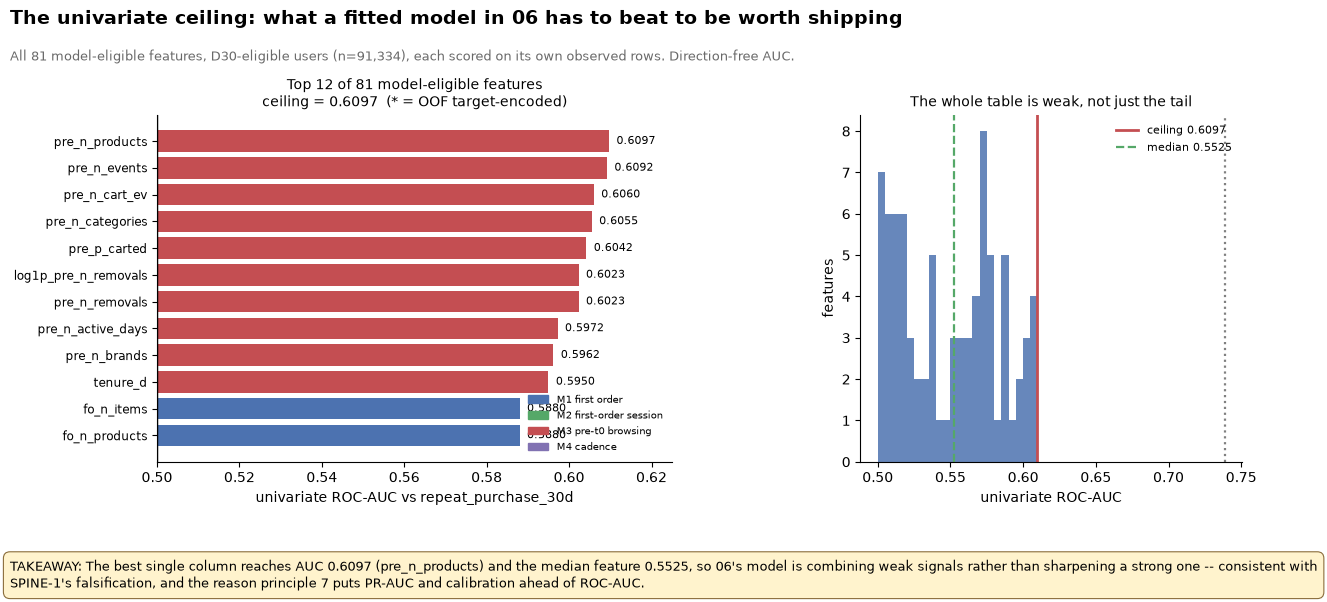

In [40]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(14, 6.2),
                              gridspec_kw={"width_ratios": [1.35, 1]})
fig.subplots_adjust(top=0.80, bottom=0.24, wspace=0.42)

top = AUC.head(12).iloc[::-1]
colmap = {"M1 first order": "#4C72B0", "M2 first-order session": "#55A868",
          "M3 pre-t0 browsing": "#C44E52", "M4 cadence": "#8172B2"}
cols = [colmap.get(b, "#999999") for b in top.block]
yy = np.arange(len(top))
ax.barh(yy, top.AUC - 0.5, left=0.5, color=cols)
for i, (v, sc) in enumerate(zip(top.AUC, top.scoring)):
    ax.text(v + 0.0018, i, f"{v:.4f}" + ("*" if sc != "numeric" else ""), va="center", fontsize=8)
ax.axvline(0.5, color="black", lw=1.0)
ax.set_yticks(yy, top.feature, fontsize=8.5)
ax.set_xlim(0.5, 0.625)
ax.set_xlabel("univariate ROC-AUC vs repeat_purchase_30d")
ax.set_title(f"Top 12 of 81 model-eligible features\nceiling = {MAXA:.4f}  (* = OOF target-encoded)", fontsize=10)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in colmap.values()],
          labels=list(colmap.keys()), fontsize=7.5, frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)

ax2.hist(AUC.AUC, bins=np.arange(0.50, 0.625, 0.005), color="#4C72B0", alpha=0.85)
ax2.axvline(MAXA, color="#C44E52", lw=2.0, label=f"ceiling {MAXA:.4f}")
ax2.axvline(float(AUC.AUC.median()), color="#55A868", ls="--", lw=1.6,
            label=f"median {AUC.AUC.median():.4f}")
ax2.axvline(0.7386, color="gray", ls=":", lw=1.6)
ax2.annotate("9C's leakage bound 0.7386\n(off this axis, to the right)", xy=(0.612, 12),
             fontsize=7.5, color="gray", ha="right")
ax2.set_xlabel("univariate ROC-AUC"); ax2.set_ylabel("features")
ax2.legend(fontsize=8, frameon=False)
ax2.set_title("The whole table is weak, not just the tail", fontsize=10)
ax2.spines[["top", "right"]].set_visible(False)

add_title(fig, "The univariate ceiling: what a fitted model in 06 has to beat to be worth shipping",
          f"All 81 model-eligible features, D30-eligible users (n={len(E30):,}), each scored on its own observed rows. Direction-free AUC.")
add_takeaway(fig, f"The best single column reaches AUC {MAXA:.4f} ({MAXF}) and the median feature {AUC.AUC.median():.4f}, so 06's model is "
                  f"combining weak signals rather than sharpening a strong one -- consistent with SPINE-1's falsification, and the reason "
                  "principle 7 puts PR-AUC and calibration ahead of ROC-AUC.")
save(fig, "nb05_addendum_univariate_ceiling"); plt.show()

In [41]:
F = handoff["features"]

# ---- 14A: the withdrawn denominator -------------------------------------------------------
PC = F["new_findings"]["purchase_cadence_undefined_at_t0"]
PC["share_below_global_threshold_pct"] = round(RIGHT, 1)
PC["share_below_global_threshold_denominator"] = (
    f"users with a DAY cadence defined (n={int(defined.sum()):,}), NOT all M4 rows")
PC["share_below_global_threshold_correction"] = {
    "withdrawn_value_pct": round(WRONG, 1),
    "corrected_value_pct": round(RIGHT, 1),
    "cause": "NaN-denominator bug. (M4.cad_day_median_gap_d < 42.2).mean() was taken over all "
             f"{int(in_m4.sum()):,} M4 rows, but only {int(defined.sum()):,} have a day cadence; "
             f"NaN < 42.2 is False, so the {int(in_m4.sum() - defined.sum()):,} users with no day "
             "cadence were counted as 'not below threshold' when they have no cadence at all.",
    "direction": "the withdrawn figure UNDERSTATED the mismatch it was cited for",
    "conclusions_affected": "none. Section 7's head-to-head and nested LR test never used this share. "
             "The corrected figure strengthens the finding and brings it in line with 04 §9B's 88.1% "
             "on purchase cadence, which at 54.8% looked like a different phenomenon.",
    "transcription_collision_checked": "04's addendum also reports a 96.3% (snapshot-label agreement "
             f"on the 28,986 missed churners). Not the source: 05's value derives independently from "
             f"{num:,}/{int(defined.sum()):,} = {100*num/int(defined.sum()):.4f}% and rounds to 96.3% by coincidence.",
    "recorded_by": "05 Section 14A (addendum)",
}
PC["screen_result"]["LR_chi2_1df"] = round(float(PC["screen_result"]["LR_chi2_1df"]), 1)

# ---- 14B: the univariate ceiling ----------------------------------------------------------
F["univariate_ceiling"] = {
    "generated_by": "05 Section 14B (addendum)",
    "target": "repeat_purchase_30d", "population": f"D30-eligible, n={len(E30):,}",
    "n_features_scored": int(len(AUC)),
    "scoring": "direction-free ROC-AUC, max(a, 1-a); each feature on its own observed rows. The 3 "
               "non-numeric features are OOF target-encoded (5-fold stratified, seed 42).",
    "max_auc": round(MAXA, 4), "max_auc_feature": MAXF,
    "median_auc": round(float(AUC.AUC.median()), 4),
    "n_at_or_above_0.60": int((AUC.AUC >= 0.60).sum()),
    "n_at_or_above_0.55": int((AUC.AUC >= 0.55).sum()),
    "top10": [{"rank": int(r.rank), "feature": r.feature, "block": r.block, "auc": float(r.AUC)}
              for r in AUC.head(10).itertuples()],
    "best_per_block": {r.block: {"feature": r.feature, "auc": float(r.AUC)} for r in best.itertuples()},
    "complete_case": {"n": int(cc.sum()), "pct_of_d30": round(100*float(cc.mean()), 1),
                      "positive_rate_pct": round(100*float(ycc.mean()), 2),
                      "max_auc": round(CCMAX, 4), "max_auc_feature": CC.feature.iloc[0],
                      "note": "NOT a random subset -- requiring a cadence selects the most engaged fifth "
                              "of the frame, which repeats at a higher rate, so every feature has less "
                              "room to separate. Use it to confirm the ranking is not a coverage "
                              "artefact, not as the operational ceiling."},
    "why_9C_could_not_tell_you_this": "Section 9C's threshold (0.7386) was calibrated 0.20 below a "
               "planted outcome-window control so it would not flag honest signal as leakage. It is a "
               "bound on LEAKAGE and sits 0.13 above the real signal ceiling.",
    "binding_rule_for_06": f"A fitted model that does not clearly beat {MAXA:.4f} ROC-AUC is not worth "
               "shipping over a one-feature rule on " + MAXF + ". But ROC-AUC is the SECONDARY metric "
               "(principle 7): the decision criterion is PR-AUC / Average Precision against the 13.73% "
               "base rate, plus calibration and decile lift. Report this ceiling alongside them so the "
               "gain from modelling is legible.",
    "tables": ["outputs/tables/nb05_addendum_univariate_auc_all.csv",
               "outputs/tables/nb05_addendum_univariate_auc_complete_case.csv",
               "outputs/tables/nb05_addendum_best_auc_by_block.csv"],
}
F["addendum"] = {
    "section": "14", "added": "after Sections 1-13 were committed",
    "execution_note": "Run in a fresh kernel against the persisted features.parquet and spliced into "
        "the committed notebook, the same way 03's and 04's Section 9 addenda were. It recomputes no "
        "feature, so Sections 1-13 stand except the withdrawn share. This EXTENDS the standing "
        "end-to-end-reproducibility limitation rather than resolving it.",
    "contents": ["14A withdraws the 54.8% cadence share (NaN denominator) and corrects it to 96.3%",
                 "14B reports the univariate AUC ceiling over all 81 model-eligible features"],
}

for i, l in enumerate(handoff["known_limitations"]):
    if l.startswith("PURCHASE CADENCE IS UNDEFINED AT A FIRST-ORDER ANCHOR"):
        handoff["known_limitations"][i] = l.replace("(54.8% sit below it)", f"({RIGHT:.1f}% sit below it)") \
                                           .replace("LR chi2(1)=20 ", "LR chi2(1)=20.5 ")
        assert f"({RIGHT:.1f}% sit below it)" in handoff["known_limitations"][i]
handoff["known_limitations"].append(
    f"UNIVARIATE CEILING IS AUC {MAXA:.4f} (05 Section 14B): across all 81 model-eligible features the best "
    f"single column ({MAXF}) reaches {MAXA:.4f} against repeat_purchase_30d and the median reaches "
    f"{AUC.AUC.median():.4f}; only {int((AUC.AUC >= 0.60).sum())} clear 0.60. Section 9C's 0.7386 is a LEAKAGE bound, not a signal "
    f"bound, and sits {0.7386-MAXA:.2f} above the real ceiling -- do not quote it as evidence the table is "
    f"informative. 06 must beat {MAXA:.4f} to justify a model over a one-feature rule, and must report "
    "PR-AUC/AP as the primary metric regardless.")

with open(os.path.join("outputs", "handoff_params.json"), "w") as fh:
    json.dump(handoff, fh, indent=2)
print("handoff_params.json updated.")
print(f"  features.new_findings...share_below_global_threshold_pct : {WRONG:.1f} -> {RIGHT:.1f}")
print(f"  features.univariate_ceiling                              : max {MAXA:.4f} ({MAXF})")
print(f"  known_limitations                                        : {len(handoff['known_limitations'])} entries "
      "(cadence share corrected in place, ceiling appended)")

handoff_params.json updated.
  features.new_findings...share_below_global_threshold_pct : 54.8 -> 96.3
  features.univariate_ceiling                              : max 0.6097 (pre_n_products)
  known_limitations                                        : 38 entries (cadence share corrected in place, ceiling appended)


## 14C. What changed, and what 06 should take from it

**The correction.** 54.8% is withdrawn; 96.3% stands. The bug was a denominator, not a
measurement, and it made the notebook contradict itself between Section 7 and Section 14 —
which is how it was caught. Section 7's printed cell still shows the old figure because this
addendum deliberately re-runs nothing; the value is superseded here, in
`handoff_params.json`, and in `nb05_addendum_cadence_denominator.csv`. Nothing downstream of
it changes, and the direction of the error is worth noting: the wrong figure *understated*
the cadence mismatch it was quoted for, and made 05 look like it disagreed with 04 §9B when
it agrees.

**The ceiling.** The best single column in the table reaches **AUC 0.6097**
(`pre_n_products`), the median reaches 0.5525, and 7 of 81 clear 0.60. Section 9C's 0.7386
was never a statement about signal — it was set deliberately loose so the leakage screen
would not flag honest predictors — and quoting it as though the table had been shown to be
informative would have been wrong.

Three things follow for 06:

1. **A model must clearly beat 0.6097 ROC-AUC to be worth shipping** over a one-feature
   rule on `pre_n_products`. That is the comparison to report, not a bare AUC.
2. **ROC-AUC is still the secondary metric.** Against a 13.73% base rate the decision
   criterion is PR-AUC / Average Precision, calibration and decile lift (principle 7). The
   ceiling belongs *alongside* those, as the thing the gain is measured against.
3. **The shape of the ceiling is itself the finding.** No strong predictor exists; the
   whole distribution sits between 0.50 and 0.61. A model here combines many weak signals
   rather than sharpening a strong one, which is exactly what SPINE-1's falsification
   predicted and another reason the targeting question needs 07's incrementality evidence
   rather than a better propensity score.